
## Improving Day-Ahead Electricity Price Forecasting in Hungary with High-Frequency Weather Features


1. Load and regularize 15-minute ENTSO-E + ERA5 dataset.
2. Rich EDA and business-context plots (regime shift, intraday patterns, regimes).
 3. Feature engineering:
    - Hourly feature set (`df_1H`) with weather.
    - Hourly + 15-minute–derived high-frequency weather set (`df_15Tf`).
    - 24-hour ahead target (`target_24h`).
 4. Models (same data and splits throughout):
    - Baselines: Naive last-24h, Linear Regression (no weather / 1H / 15T), XGBoost (no weather / 1H / 15T).
    - Classical time series: StatsForecast AutoARIMA & SeasonalNaive.
    - Deep learning: NeuralForecast NBEATSx & TiDE (1H and 15T) on a 7-day horizon.
5. Ablation: impact of weather and high-frequency weather on forecast accuracy.
6. Consolidated comparison table and a rich set of diagnostics plots.



### 0. Notebook structure and objectives

 This notebook implements the full modelling pipeline for **Hungarian day-ahead electricity prices**.
 The structure is:

 1. **Imports and configuration** – libraries, paths, constants, and time windows; plus helper functions.
 2. **Data loading & data health** – 15-minute master panel, basic distributions, global correlations.
 3. **Core EDA** – price regimes, intraday patterns, hourly correlations, ACF/PACF, seasonal decomposition.
 4. **Feature engineering** – hourly and 15-minute feature sets, lagged prices, weather, calendar, and PV proxies.
    - `df_no_wx`   – non-weather features only (for ablation).
    - `df_1H`      – non-weather + hourly weather.
    - `df_15Tf`    – non-weather + hourly + 15T-derived weather.
 5. **Baseline ML models** – Naive, Linear regression, XGBoost on all three feature sets.
 6. **Classical time series baselines** – AutoARIMA and SeasonalNaive via StatsForecast.
 7. **Neural models** – NBEATSx and TiDE on hourly and 15T-enhanced features (7-day horizon).
 8. **Model comparison** – consolidated leaderboard table.
 9. **Visual diagnostics & error slices** – full-year plots, 7-day zoom, daily panels, slice-wise metrics, interactive view.
 10. **Reproducibility** – environment snapshot and exported metrics.



### 1. Imports, configuration, and helper functions

 In this section we:
 - Import all required libraries.
 - Define paths, constants, and modelling windows.
 - Implement helper utilities for metrics, splits, feature prep, plotting, and simple tuning.

In [ ]:
# Cell 0 – install dependencies and download raw data from Google Drive

!pip install -q \
    numpy pandas matplotlib seaborn missingno \
    xgboost statsforecast neuralforecast \
    plotly lightgbm tensorflow gdown

import os
os.makedirs("data", exist_ok=True)

# Download the merged dataset from your shared Drive link into /content/data
!gdown --id "19TX2IswYnQvoXR6rgM6WjrMgns23T_SL" -O data/final_merged_energy_dataset_2015_2024.csv

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=19TX2IswYnQvoXR6rgM6WjrMgns23T_SL
From (redirected): https://drive.google.com/uc?id=19TX2IswYnQvoXR6rgM6WjrMgns23T_SL&confirm=t&uuid=d694d5d0-07d1-42a8-a0d3-f1f7ad6852e1
To: /teamspace/studios/this_studio/Notbook_v4/data/final_merged_energy_dataset_2015_2024.csv
100%|████████████████████████████████████████| 366M/366M [00:05<00:00, 67.1MB/s]


In [ ]:

# Cell 1 – imports

from pathlib import Path
from datetime import timedelta
import warnings
import platform
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import plotly.express as px

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL, seasonal_decompose

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor

# Classical time-series models
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, SeasonalNaive

# Deep learning models
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATSx, TiDE

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_context("talk")

In [ ]:
# Cell 2 – configuration (paths, constants, time windows)

# -------------------------
# Global experiment config
# -------------------------
EXPERIMENT_NAME = "HU_DA_24h_price_v4"
RANDOM_SEED = 42

# Forecast settings
HORIZON_HOURS = 24            # 24h ahead target
EVAL_HORIZON_DAYS = 7         # main comparison horizon (7 days)
NF_HORIZON_7D = 24 * EVAL_HORIZON_DAYS
SF_HORIZON_FOR_COMPARISON = NF_HORIZON_7D

# Try Lightning root first (Mistral environment), otherwise use current directory (Colab)
DEFAULT_ROOT = Path(".").resolve()
LIGHTNING_ROOT = Path("/teamspace/studios/this_studio/Notebook_v2")
PROJECT_ROOT = LIGHTNING_ROOT if LIGHTNING_ROOT.exists() else DEFAULT_ROOT

# In Colab, this will be /content/data (created in Cell 0)
DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)

# IMPORTANT: In Colab we download the merged CSV into DATA_DIR via gdown
RAW_MERGED_PATH = DATA_DIR / "final_merged_energy_dataset_2015_2024.csv"

# 15-minute master panel path
MASTER_15T_PATH = DATA_DIR / "master_15T_2015_2024.csv"

# Modelling dataset exports (for re-use / ablation)
MODEL_NO_WX_PATH = DATA_DIR / "model_data_no_weather_v4.parquet"
MODEL_1H_PATH    = DATA_DIR / "model_data_hourly_weather_v4.parquet"
MODEL_15T_PATH   = DATA_DIR / "model_data_15T_features_v4.parquet"

# Core column names
DATETIME_COL = "datetime_local"
PRICE_COL    = "Price_DA_EUR_MWh"
TARGET_COL   = "target_24h"

# Weather vars from ERA5 in the merged file
WEATHER_BASE_VARS = [
    "t2m", "d2m", "u10", "v10", "u100", "v100",
    "tcwv", "tp", "ssr", "str", "ssrd", "strd",
    "e", "ro", "cp", "fg10", "hcc", "lcc", "mcc", "tcc",
]

# Modelling horizon (post-2022 high-volatility regime)
MODEL_START_DATE = "2022-01-01"
MODEL_END_DATE   = "2024-12-31"

# Train / validation / test splits (consistent across all models)
TRAIN_END_DATE  = "2023-06-30 00:00:00"
VAL_END_DATE    = "2023-12-31 23:00:00"
TEST_START_DATE = "2024-01-01 00:00:00"

# Runtime flags (can be toggled to speed up work)
RUN_EDA                 = True
RUN_FEATURE_ENGINEERING = True
RUN_BASE_MODELS         = True
RUN_STATSFORECAST       = True
RUN_NEURALFORECAST      = True

np.random.seed(RANDOM_SEED)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_MERGED_PATH:", RAW_MERGED_PATH)
print("MASTER_15T_PATH:", MASTER_15T_PATH)


PROJECT_ROOT: /teamspace/studios/this_studio/Notebook_v2
RAW_MERGED_PATH: /teamspace/studios/this_studio/Notebook_v2/data/final_merged_energy_dataset_2015_2024.csv
MASTER_15T_PATH: /teamspace/studios/this_studio/Notebook_v2/data/master_15T_2015_2024.csv


In [ ]:
# Cell 3 – helper functions (metrics, splitting, ML prep, plotting)

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom[denom == 0] = 1e-8
    return float(100 * np.mean(2 * np.abs(y_pred - y_true) / denom))


def evaluate_forecast(y_true, y_pred):
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "smape": smape(y_true, y_pred),
        "n": int(len(y_true)),
    }


def time_split(df, target_col):
    """Time-based train/val/test split on modelling window (post-2022).

    - Train: up to TRAIN_END_DATE (inclusive)
    - Val:   from TRAIN_END_DATE + 1h to VAL_END_DATE
    - Test:  from TEST_START_DATE onwards
    """
    df = df.sort_index()

    train_end = pd.to_datetime(TRAIN_END_DATE)
    val_end   = pd.to_datetime(VAL_END_DATE)
    test_start = pd.to_datetime(TEST_START_DATE)

    df_train = df.loc[:train_end]
    df_val   = df.loc[train_end + pd.Timedelta(hours=1):val_end]
    df_test  = df.loc[test_start:]

    X_train = df_train.drop(columns=[target_col])
    y_train = df_train[target_col]

    X_val   = df_val.drop(columns=[target_col])
    y_val   = df_val[target_col]

    X_test  = df_test.drop(columns=[target_col])
    y_test  = df_test[target_col]

    print("Train window:", X_train.index.min(), "→", X_train.index.max(), "n:", len(X_train))
    print("Val   window:", X_val.index.min(),   "→", X_val.index.max(),   "n:", len(X_val))
    print("Test  window:", X_test.index.min(),  "→", X_test.index.max(),  "n:", len(X_test))

    return X_train, y_train, X_val, y_val, X_test, y_test

In [ ]:
# --- Domain-aware imputation helpers --------------------------------------------------------

def is_weather_col(col: str) -> bool:
    """Return True if a column is a weather-related variable (base or derived)."""
    # Direct ERA5 base variables
    if col in WEATHER_BASE_VARS:
        return True

    # Common derived weather feature prefixes
    weather_prefixes = [
        "wind_speed_",
        "solar_irradiance",
        "temp_C",
        "dewpoint_C",
        "temp_dewpoint_spread",
    ]
    if any(col.startswith(p) for p in weather_prefixes):
        return True

    # 1H aggregates of 15T ERA5 variables
    if "_1h_" in col:
        if any(w in col for w in WEATHER_BASE_VARS):
            return True

    return False


def is_flow_col(col: str) -> bool:
    """Return True if a column is a cross-border flow or flow-based feature."""
    if col.startswith("Flow_"):
        return True
    # Optionally treat derived flow features as flows as well
    if col in ["Flow_net_sum", "Flow_net_per_load"]:
        return True
    return False


def impute_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Time-series-oriented imputation with domain logic:

    - Weather columns: forward/backward fill (time-wise), no zero-filling.
    - Flow / cross-border columns: missing values -> 0.0 (assume no trade).
    - Other numeric features: forward/backward fill, remaining NaNs -> 0.0 fallback.
    """
    df = df.copy()
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if not numeric_cols:
        return df

    weather_cols = [c for c in numeric_cols if is_weather_col(c)]
    flow_cols    = [c for c in numeric_cols if is_flow_col(c)]
    other_cols   = [c for c in numeric_cols if c not in weather_cols + flow_cols]

    # 1) Weather: only time-wise forward/backward fill
    if weather_cols:
        df[weather_cols] = df[weather_cols].ffill().bfill()

    # 2) Flows: direct zero-fill (no trade when missing)
    if flow_cols:
        df[flow_cols] = df[flow_cols].fillna(0.0)

    # 3) Other numeric features: ffill/bfill + zero fallback
    if other_cols:
        df[other_cols] = df[other_cols].ffill().bfill()
        df[other_cols] = df[other_cols].fillna(0.0)

    return df


def make_ml_matrices(X_train, y_train, X_val, y_val, X_test, y_test):
    """Prepare aligned numpy matrices for ML models with domain-aware imputation."""
    feature_cols = X_train.columns.tolist()

    X_train_imp = impute_features(X_train[feature_cols]).astype("float32")
    X_val_imp   = impute_features(X_val[feature_cols]).astype("float32")
    X_test_imp  = impute_features(X_test[feature_cols]).astype("float32")

    X_train_m = X_train_imp.values
    X_val_m   = X_val_imp.values
    X_test_m  = X_test_imp.values

    y_train_m = y_train.astype("float32").values
    y_val_m   = y_val.astype("float32").values
    y_test_m  = y_test.astype("float32").values

    return feature_cols, X_train_m, y_train_m, X_val_m, y_val_m, X_test_m, y_test_m


def plot_actual_vs_pred(sample_series, pred_series_dict, title, figsize=(18, 8)):
    plt.figure(figsize=figsize)
    sample_series.plot(label="Actual", linewidth=2)
    for name, s in pred_series_dict.items():
        if s is not None:
            s.plot(label=name, alpha=0.9)
    plt.title(title)
    plt.xlabel("Datetime")
    plt.ylabel("Price [EUR/MWh] (24h ahead)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_actual_vs_forecast(y_true, y_pred_dict, title, start=None, end=None, figsize=(18, 8)):
    """Plot actual vs multiple forecast series on a common time slice."""
    if start is not None or end is not None:
        y_true = y_true.loc[start:end]
        new_pred_dict = {}
        for name, s in y_pred_dict.items():
            new_pred_dict[name] = s.loc[y_true.index]
        y_pred_dict = new_pred_dict

    plt.figure(figsize=figsize)
    plt.plot(y_true.index, y_true.values, label="Actual", linewidth=2)
    for name, s in y_pred_dict.items():
        plt.plot(s.index, s.values, label=name, alpha=0.9)
    plt.title(title)
    plt.xlabel("Datetime")
    plt.ylabel("Price [EUR/MWh] (24h ahead)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_residuals(y_true, y_pred, title_prefix="Residuals"):
    """Residual histogram and residual time-series plot."""
    residuals = pd.Series(y_true - y_pred, index=y_true.index)

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    axes[0].hist(residuals, bins=40)
    axes[0].set_title(f"{title_prefix} – histogram")
    axes[0].set_xlabel("Error (EUR/MWh)")
    axes[0].set_ylabel("Count")

    axes[1].plot(residuals.index, residuals.values, linewidth=0.7)
    axes[1].set_title(f"{title_prefix} – over time")
    axes[1].set_xlabel("Datetime")
    axes[1].set_ylabel("Error (EUR/MWh)")

    plt.tight_layout()
    plt.show()

In [ ]:
# --- Additional helper functions  ------------------------

def data_health_report(df, target_col, top_n_na=30):
    """Print basic data health information and NA ratios."""
    print("Shape:", df.shape)
    if hasattr(df.index, "min") and hasattr(df.index, "max"):
        print("Index range:", df.index.min(), "→", df.index.max())
    print("\nDtypes (compressed):")
    print(df.dtypes.value_counts())

    print("\nTop NA ratios:")
    na_ratio = df.isna().mean().sort_values(ascending=False)
    print(na_ratio.head(top_n_na).round(3))

    if target_col in df.columns:
        print(f"\nTarget '{target_col}' basic stats:")
        print(df[target_col].describe())


def plot_corr_heatmap(df, cols=None, title="Correlation Heatmap", max_features=40):
    """
    Global numeric correlation heatmap. If cols is None, use all numeric columns.
    For many features we keep only the top correlated with a key target to remain readable.
    """
    numeric_df = df.select_dtypes(include=[np.number])

    if cols is not None:
        numeric_df = numeric_df[cols]

    corr = numeric_df.corr()

    # Try to detect a natural target for ranking
    target_candidates = [c for c in corr.columns if "Price" in c or "target" in c.lower()]
    if target_candidates:
        target_for_ranking = target_candidates[0]
    else:
        target_for_ranking = corr.columns[0]

    if max_features is not None and corr.shape[1] > max_features:
        target_corr = corr[target_for_ranking].abs().sort_values(ascending=False)
        keep_cols = target_corr.index[:max_features]
        corr = corr.loc[keep_cols, keep_cols]

    plt.figure(figsize=(18, 16))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_regime_correlations(df, target_col, split_date, prefix="Pre", max_features=30):
    """
    Compute and print correlations of the target with all numeric features in a given regime.
    prefix: "Pre" or "Post" to control the split side.
    """
    numeric_df = df.select_dtypes(include=[np.number])

    if prefix.lower().startswith("pre"):
        mask = df.index < split_date
    else:
        mask = df.index >= split_date

    sub = numeric_df.loc[mask].dropna()
    if target_col not in sub.columns:
        print(f"Target {target_col} not in numeric dataframe – skipping.")
        return

    corr_series = sub.corr()[target_col].sort_values(ascending=False)
    print(f"\n{prefix}-split correlations with {target_col} (top {max_features}):")
    print(corr_series.head(max_features))


def add_lags(df, target_col, lags, group_col=None):
    """
    Generic lag feature helper (adapted from flu notebook pattern).
    If group_col is None, simple shift; otherwise grouped shift.
    """
    df = df.copy()
    if group_col is None:
        for L in lags:
            df[f"{target_col}_lag{L}"] = df[target_col].shift(L)
    else:
        for L in lags:
            df[f"{target_col}_lag{L}"] = df.groupby(group_col)[target_col].shift(L)
    return df


def diagnostic_plots(y_true, y_pred, model_name="model"):
    """
    Residual distribution, residual vs prediction, predicted vs actual scatter.
    """
    y_true = pd.Series(y_true, name="y_true").astype(float)
    y_pred = pd.Series(y_pred, name="y_pred").astype(float)
    residuals = y_true - y_pred

    # 1) Residual distribution
    plt.figure(figsize=(10, 4))
    plt.hist(residuals, bins=50, alpha=0.7, density=True)
    plt.title(f"{model_name}: Residual Distribution")
    plt.xlabel("Residual")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

    # 2) Residuals vs predictions
    plt.figure(figsize=(10, 4))
    plt.scatter(y_pred, residuals, s=5, alpha=0.5)
    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.title(f"{model_name}: Residuals vs Predictions")
    plt.xlabel("Predicted")
    plt.ylabel("Residual")
    plt.tight_layout()
    plt.show()

    # 3) Predicted vs actual scatter
    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, s=5, alpha=0.5)
    lims = [
        np.nanmin([y_true.min(), y_pred.min()]),
        np.nanmax([y_true.max(), y_pred.max()])
    ]
    plt.plot(lims, lims, "k--", linewidth=1)
    plt.xlim(lims)
    plt.ylim(lims)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{model_name}: Predicted vs Actual")
    plt.tight_layout()
    plt.show()


def slice_metrics_df(y_true, y_pred, slice_labels):
    """
    Panel metrics: compute evaluate_forecast per slice.
    slice_labels can be hour, month, is_weekend, etc.
    Returns a DataFrame with rmse/mae/smape/n per slice.
    """
    df = pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred,
        "slice": slice_labels,
    }).dropna()

    def _metric_fun(g):
        return evaluate_forecast(g["y_true"], g["y_pred"])

    metrics = (
        df.groupby("slice")
          .apply(_metric_fun)
          .apply(pd.Series)
    )

    return metrics


def plot_acf_pacf_series(series, lags=60, title_prefix="Series"):
    """ACF/PACF helper modeled on the flu notebook."""
    series = pd.Series(series).dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(series, ax=axes[0], lags=lags)
    axes[0].set_title(f"{title_prefix} – ACF")

    plot_pacf(series, ax=axes[1], lags=lags, method="ywm")
    axes[1].set_title(f"{title_prefix} – PACF")

    plt.tight_layout()
    plt.show()

In [ ]:
# --- Hyperparameter tuning helpers ----------------------------------------------------------

def tune_xgb_single(X_train, y_train, X_val, y_val, model_name="XGB", param_grid=None):
    """
    Small manual grid search for XGBoost.
    The grid is deliberately coarse to balance model quality and limited compute.
    Detailed hyperparameters are documented in the report; here we log the best
    configuration based on validation RMSE.
    """
    from itertools import product

    if param_grid is None:
        param_grid = {
            "max_depth":       [4, 7],
            "learning_rate":   [0.03, 0.10],
            "n_estimators":    [400, 800],
            "subsample":       [0.8],
            "colsample_bytree":[0.8, 1.0],
        }

    base_kwargs = dict(
        objective="reg:squarederror",
        tree_method="hist",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )

    best_rmse = np.inf
    best_model = None
    best_params = None
    rows = []

    keys = list(param_grid.keys())
    for values in product(*param_grid.values()):
        params = dict(zip(keys, values))
        model = XGBRegressor(**base_kwargs, **params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False,
        )

        y_val_pred = model.predict(X_val)
        metrics = evaluate_forecast(y_val, y_val_pred)
        rmse = metrics["rmse"]

        row = {"model": model_name, **params, "rmse": rmse}
        rows.append(row)

        if rmse < best_rmse:
            best_rmse = rmse
            best_model = model
            best_params = params

    results_df = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
    print(f"Best {model_name} RMSE on validation set: {best_rmse:.3f}")
    print("Best params:", best_params)
    return best_model, best_params, results_df

### 2. Data loading and global data-health

 We now load the pre-built **15-minute master dataset** (2015–2024) that merges:
 - ENTSO-E prices and loads,
 - generation mix,
 - cross-border flows, and
 - high-frequency ERA5 weather variables.

 Then we:
 - Run a global data-health report and distribution checks.
 - Inspect global correlations and regime-specific correlations.
 - Plot yearly panels and seasonal decomposition (2022–2024 regime only).


In [ ]:
# Cell 4 – build / load 15-minute master dataset

if MASTER_15T_PATH.exists():
    print(f"Loading existing 15T master dataset from: {MASTER_15T_PATH}")
    df_15T = pd.read_csv(MASTER_15T_PATH, parse_dates=[DATETIME_COL])
    df_15T = df_15T.set_index(DATETIME_COL).sort_index()
else:
    print(f"Loading raw merged file from: {RAW_MERGED_PATH}")
    raw = pd.read_csv(RAW_MERGED_PATH, low_memory=False)
    print("Raw shape:", raw.shape)

    raw[DATETIME_COL] = pd.to_datetime(raw[DATETIME_COL], utc=False)
    raw = raw.sort_values(DATETIME_COL).set_index(DATETIME_COL)

    if not raw.index.is_unique:
        dup_counts = raw.index.value_counts()
        n_dup = (dup_counts > 1).sum()
        print(f"Found {n_dup} duplicated timestamps – aggregating by mean.")
        raw = raw.groupby(raw.index).mean()

    full_index = pd.date_range(raw.index.min(), raw.index.max(), freq="15T")
    df_15T = raw.reindex(full_index)
    df_15T.index.name = DATETIME_COL

    df_15T[PRICE_COL] = pd.to_numeric(df_15T[PRICE_COL], errors="coerce")

    print("After reindex to 15T:", df_15T.shape)
    print("Missing ratio (top 10 columns):")
    print(df_15T.isna().mean().sort_values(ascending=False).head(10).round(3))

    msno.matrix(df_15T[[PRICE_COL]].sample(min(5000, len(df_15T))), figsize=(10, 12))
    plt.title("Missingness pattern – price (sample)")
    plt.show()

    df_15T.to_csv(MASTER_15T_PATH, index_label=DATETIME_COL)
    print(f"Saved master 15T dataset to: {MASTER_15T_PATH}")

print("15T master shape:", df_15T.shape)
print("Index range:", df_15T.index.min(), "→", df_15T.index.max())

Loading existing 15T master dataset from: /teamspace/studios/this_studio/Notebook_v2/data/master_15T_2015_2024.csv


15T master shape: (350689, 131)
Index range: 2015-01-01 00:00:00 → 2025-01-01 00:00:00


=== Data Health Report on 15T master ===
Shape: (350689, 131)
Index range: 2015-01-01 00:00:00 → 2025-01-01 00:00:00

Dtypes (compressed):
float64    131
Name: count, dtype: int64

Top NA ratios:
Price_DA_EUR_MWh                          0.750
Load_Actual_MW                            0.001
Load_Forecast_MW                          0.000
Gen_RS_Biomass                            0.000
Gen_RS_Fossil Gas                         0.000
Gen_RS_Hydro Pumped Storage               0.000
Gen_RS_Hydro Run-of-river and poundage    0.000
Gen_RS_Hydro Water Reservoir              0.000
Gen_RS_Other                              0.000
Gen_RS_Wind Onshore                       0.000
Gen_SK_Biomass                            0.000
Gen_SK_Fossil Brown coal/Lignite          0.000
Gen_SK_Fossil Gas                         0.000
Gen_SK_Fossil Hard coal                   0.000
Gen_SK_Fossil Oil                         0.000
Gen_SK_Hydro Pumped Storage               0.000
Gen_SK_Hydro Pumped Storage.1       

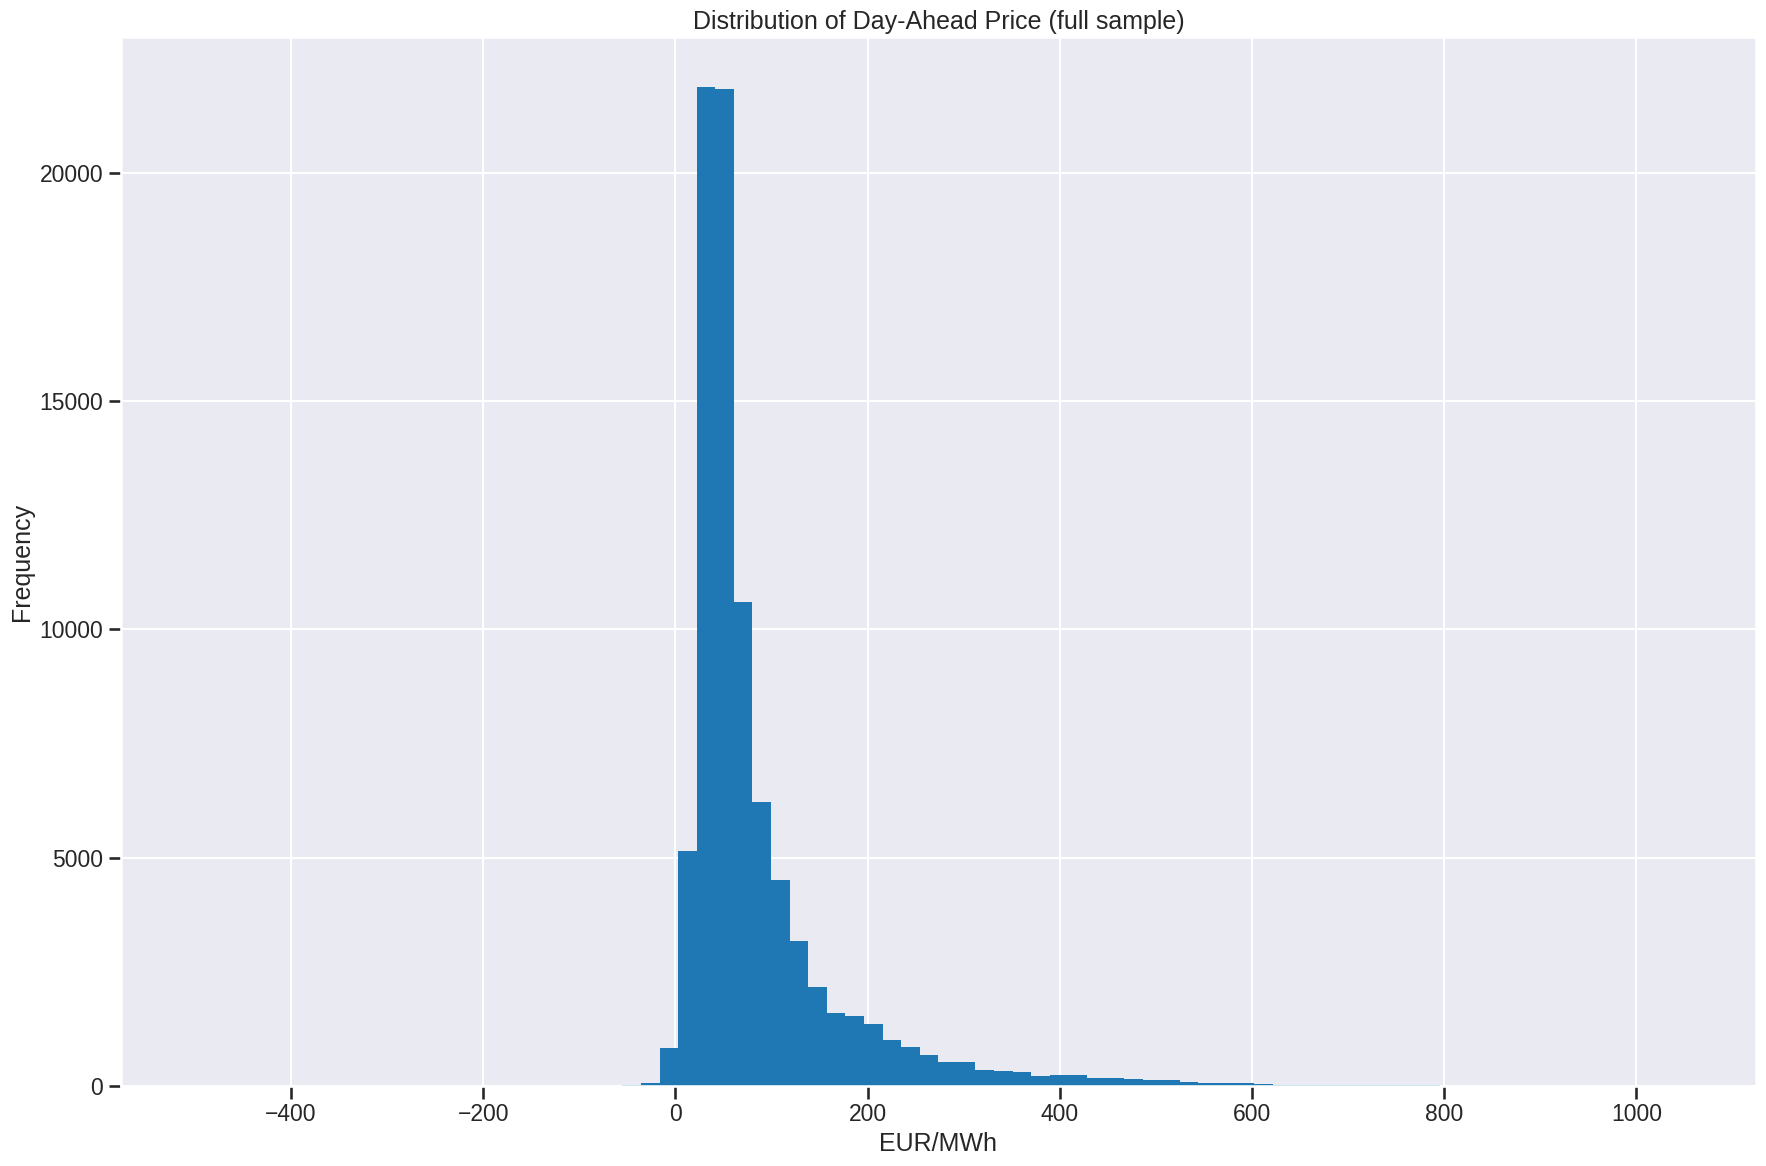

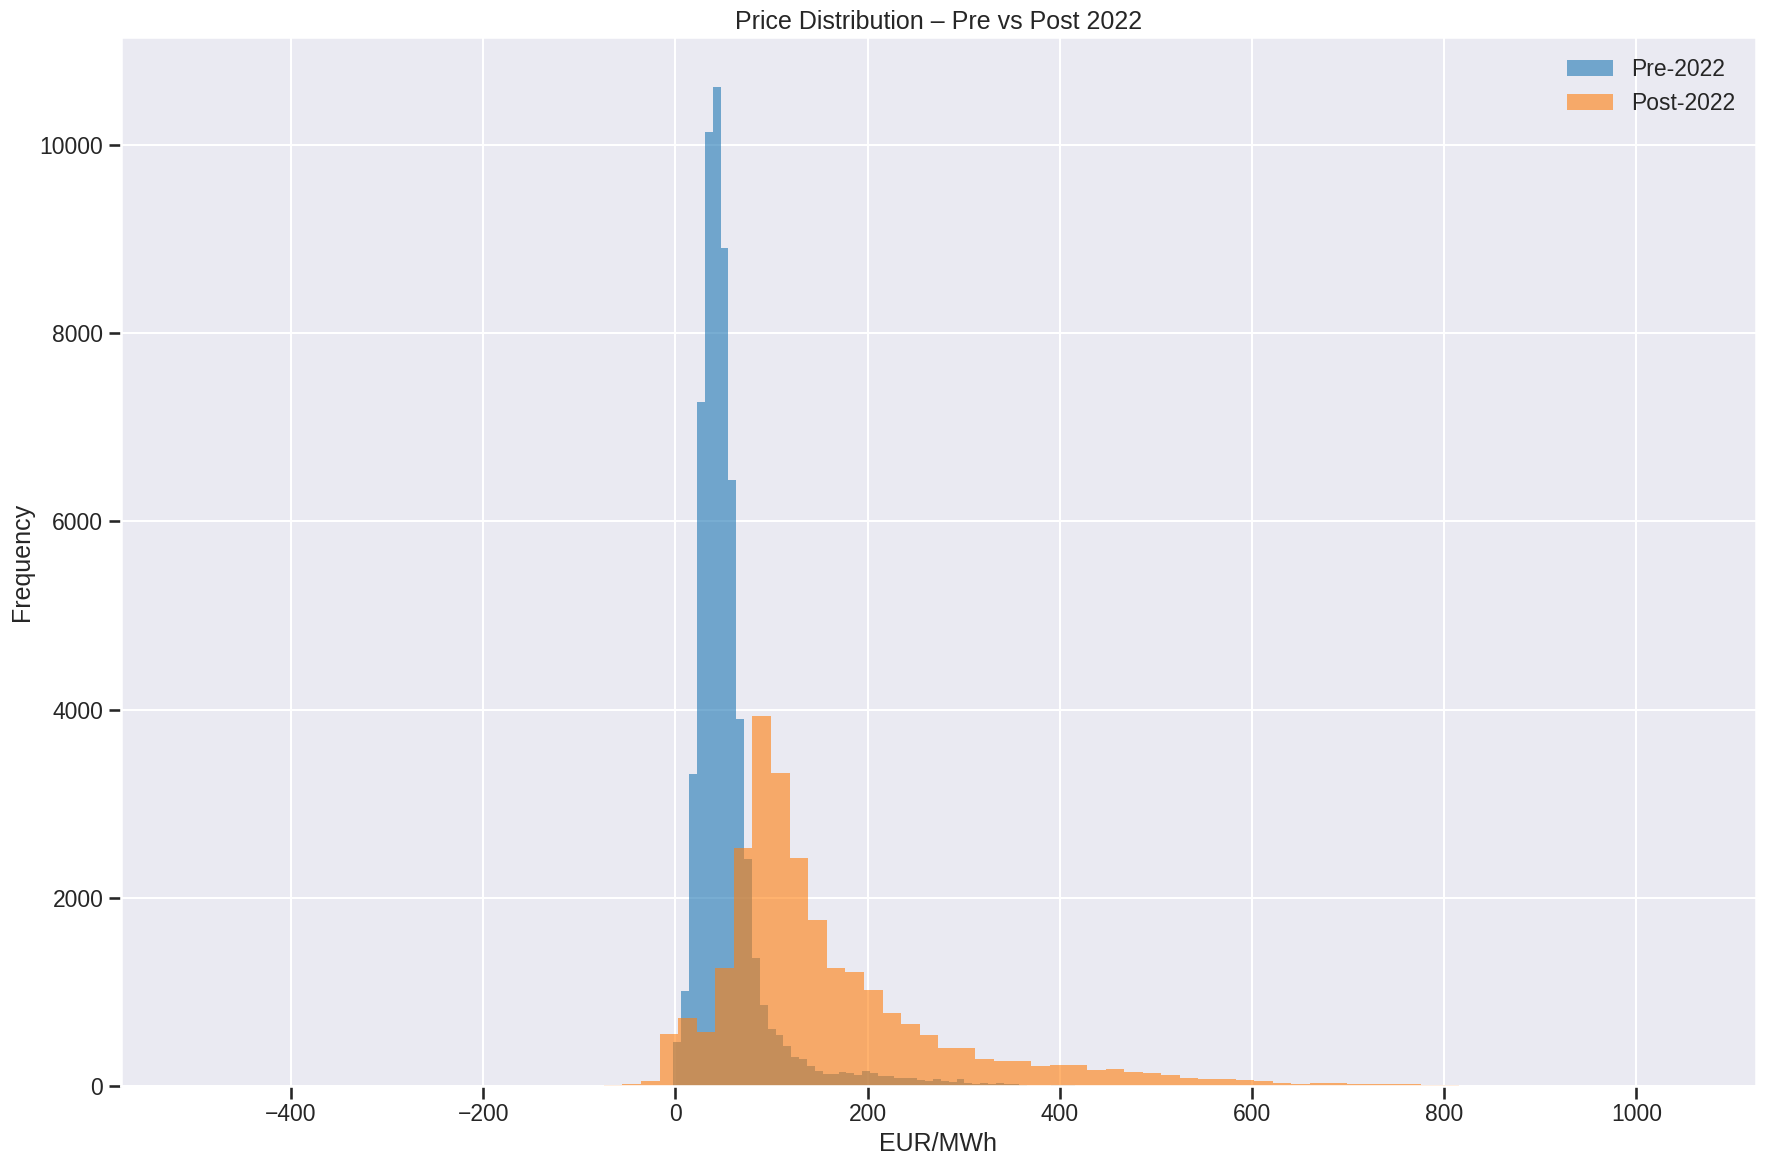


=== Global numeric correlation heatmap (top correlated with price) ===


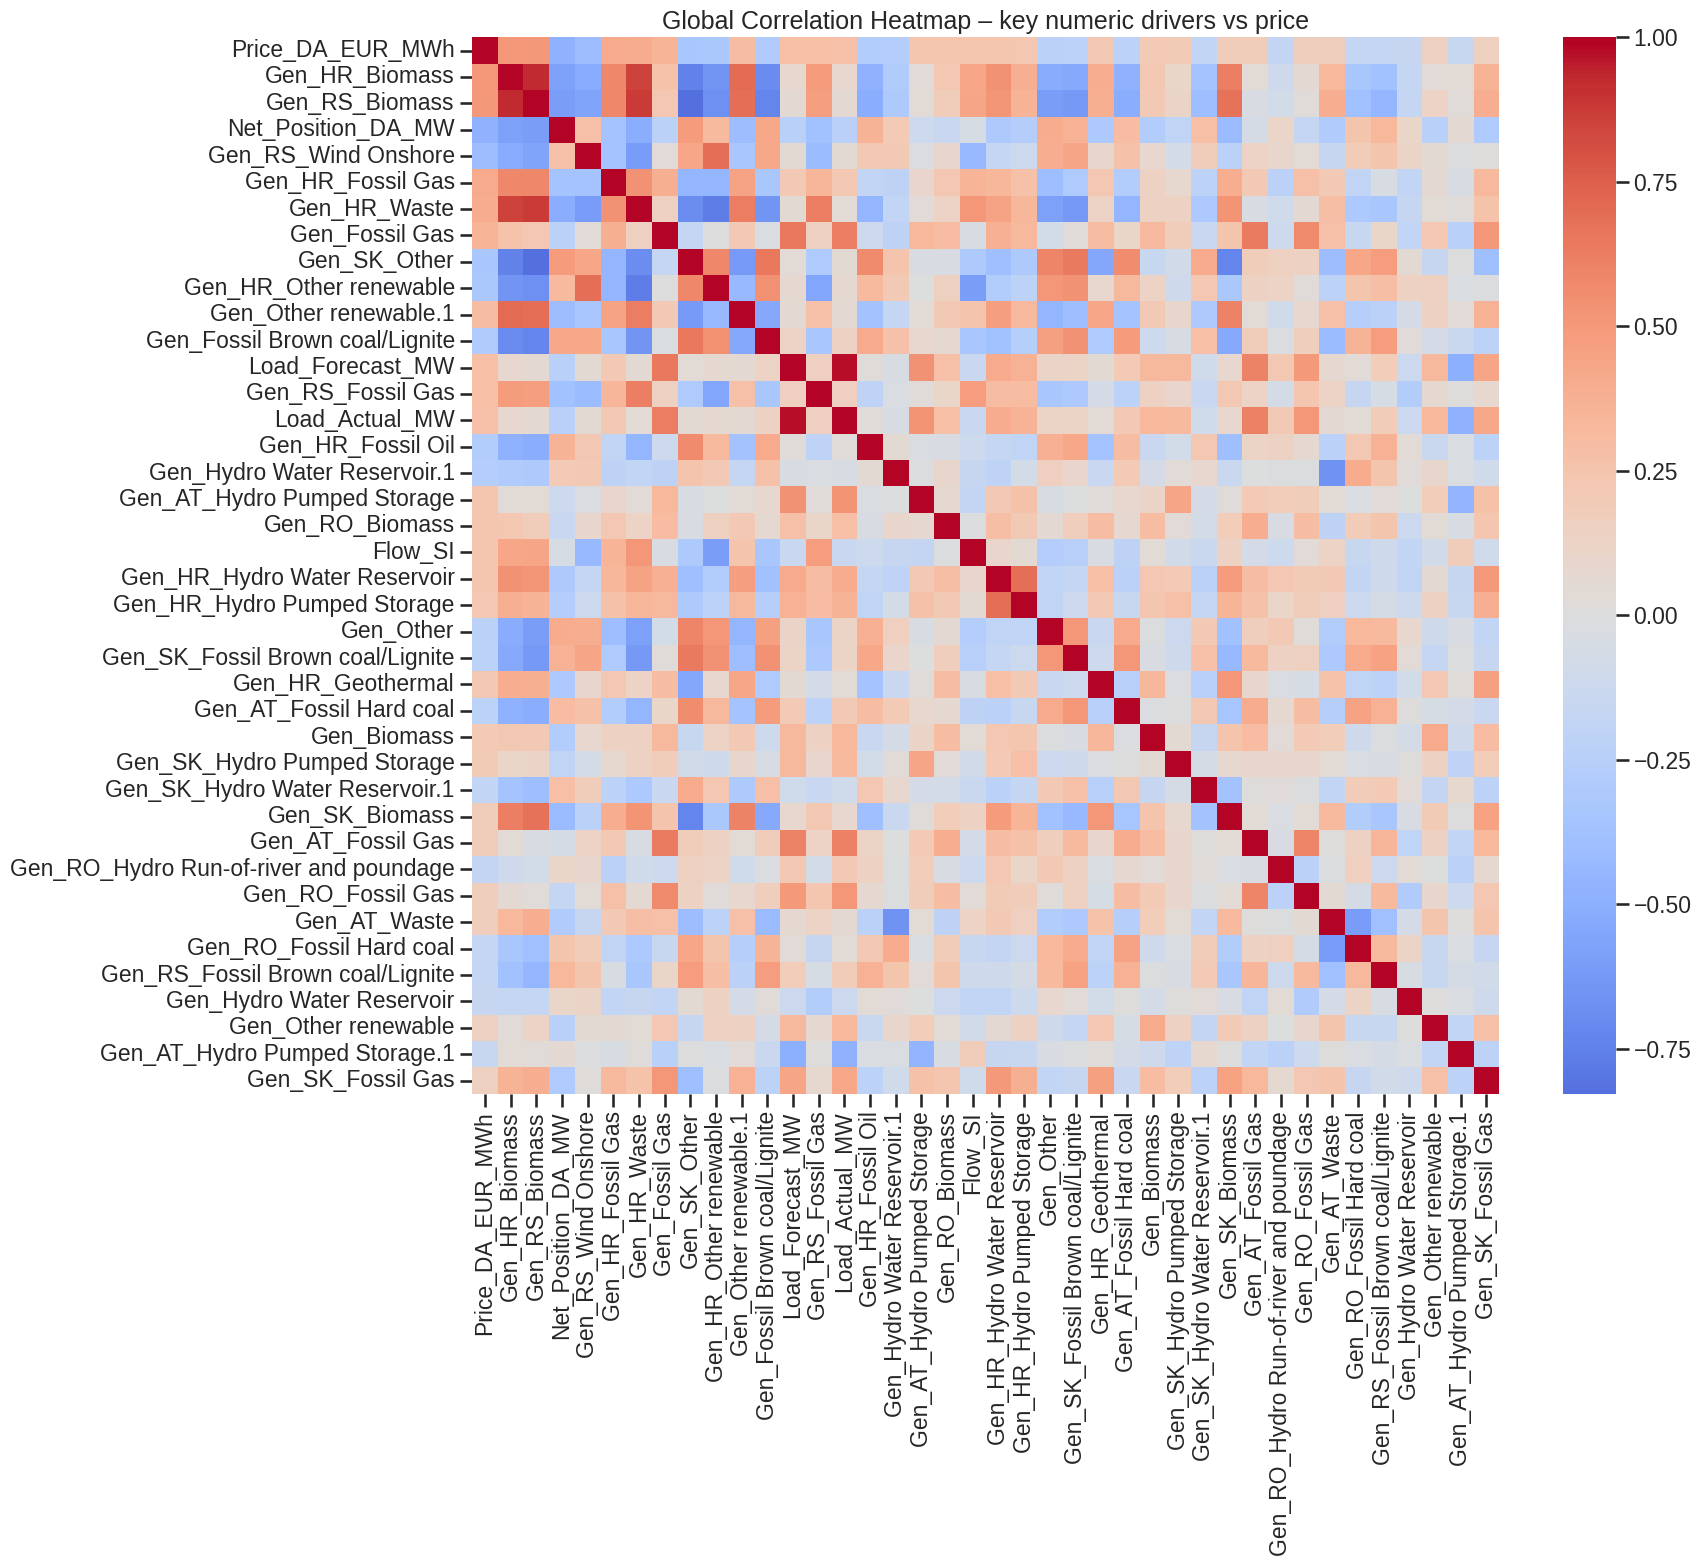


=== Weather vs price correlations (2022–2024, modelling window) ===
      corr_with_price
e               0.122
strd            0.092
tcwv            0.087
t2m             0.083
d2m             0.030
cp              0.023
hcc             0.003
tcc            -0.001
str            -0.004
tp             -0.009
lcc            -0.015
mcc            -0.026
u10            -0.055
u100           -0.076
ssrd           -0.078
ssr            -0.079
v10            -0.131
v100           -0.132
fg10           -0.141
ro             -0.211


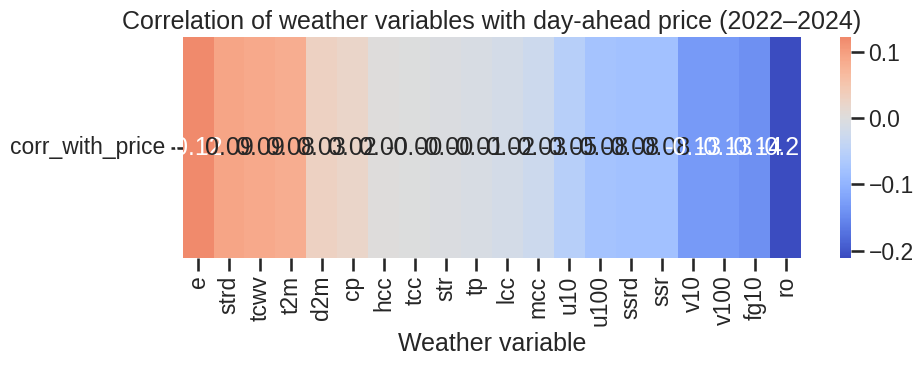


=== Regime-specific correlations with price ===

Pre-2022-split correlations with Price_DA_EUR_MWh (top 30):
Price_DA_EUR_MWh                          1.000000
Gen_HR_Biomass                            0.515867
Gen_Fossil Gas                            0.482580
Load_Forecast_MW                          0.433456
Gen_RS_Biomass                            0.427220
Load_Actual_MW                            0.419510
Gen_SK_Fossil Gas                         0.385324
Gen_RS_Other                              0.371798
Gen_Geothermal                            0.348287
Gen_HR_Waste                              0.329040
Gen_HR_Fossil Gas                         0.320712
Gen_AT_Fossil Gas                         0.314093
Gen_RO_Fossil Gas                         0.302053
Gen_AT_Hydro Pumped Storage               0.287283
Gen_HR_Hydro Pumped Storage               0.281535
Gen_HR_Hydro Water Reservoir              0.276030
Gen_RO_Biomass                            0.261468
Gen_HR_Geothermal      

In [ ]:
# 2.1 Data health & global correlations (flu-style EDA)

if RUN_EDA:
    print("=== Data Health Report on 15T master ===")
    data_health_report(df_15T, target_col=PRICE_COL, top_n_na=40)

    # Target distribution – full period
    plt.figure(figsize=(18, 12))
    df_15T[PRICE_COL].hist(bins=80)
    plt.title("Distribution of Day-Ahead Price (full sample)")
    plt.xlabel("EUR/MWh")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    # Target distribution – pre vs post structural break (2022)
    split_date = pd.to_datetime("2022-01-01")

    pre_price  = df_15T.loc[df_15T.index < split_date, PRICE_COL].dropna()
    post_price = df_15T.loc[df_15T.index >= split_date, PRICE_COL].dropna()

    plt.figure(figsize=(18, 12))
    plt.hist(pre_price,  bins=80, alpha=0.6, label="Pre-2022")
    plt.hist(post_price, bins=80, alpha=0.6, label="Post-2022")
    plt.title("Price Distribution – Pre vs Post 2022")
    plt.xlabel("EUR/MWh")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Correlation heatmap – top features with price
    print("\n=== Global numeric correlation heatmap (top correlated with price) ===")
    plot_corr_heatmap(
        df_15T,
        title="Global Correlation Heatmap – key numeric drivers vs price",
        max_features=40
    )

    # NEW: Weather vs price correlation heatmap (2022–2024, modelling window)
    print("\n=== Weather vs price correlations (2022–2024, modelling window) ===")

    model_start = pd.to_datetime(MODEL_START_DATE)
    model_end   = pd.to_datetime(MODEL_END_DATE)

    df_wx_win = df_15T.loc[model_start:model_end].copy()

    # Base ERA5 weather vars from merged file
    weather_cols_raw = [c for c in WEATHER_BASE_VARS if c in df_wx_win.columns]

    # Derived weather features (if already created elsewhere)
    derived_weather_candidates = [
        "wind_speed_10m", "wind_speed_100m",
        "solar_irradiance",
        "temp_C", "dewpoint_C", "temp_dewpoint_spread",
    ]
    derived_weather_cols = [c for c in derived_weather_candidates if c in df_wx_win.columns]

    weather_cols = weather_cols_raw + derived_weather_cols

    if not weather_cols:
        print("No weather columns found for correlation heatmap – skipping.")
    else:
        corr_series = (
            df_wx_win[[PRICE_COL] + weather_cols]
            .dropna()
            .corr()[PRICE_COL]             # correlation vs price
            .drop(PRICE_COL)
            .sort_values(ascending=False)
        )

        corr_df = corr_series.to_frame(name="corr_with_price")

        print(corr_df.round(3))

        plt.figure(figsize=(max(10, len(corr_df) * 0.4), 4))
        sns.heatmap(
            corr_df.T,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0
        )
        plt.title("Correlation of weather variables with day-ahead price (2022–2024)")
        plt.xlabel("Weather variable")
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

    # Regime-specific correlations: which drivers changed importance after 2022?
    print("\n=== Regime-specific correlations with price ===")
    plot_regime_correlations(df_15T, PRICE_COL, split_date, prefix="Pre-2022",  max_features=30)
    plot_regime_correlations(df_15T, PRICE_COL, split_date, prefix="Post-2022", max_features=30)

else:
    print("RUN_EDA is False – skipping data health & correlations.")

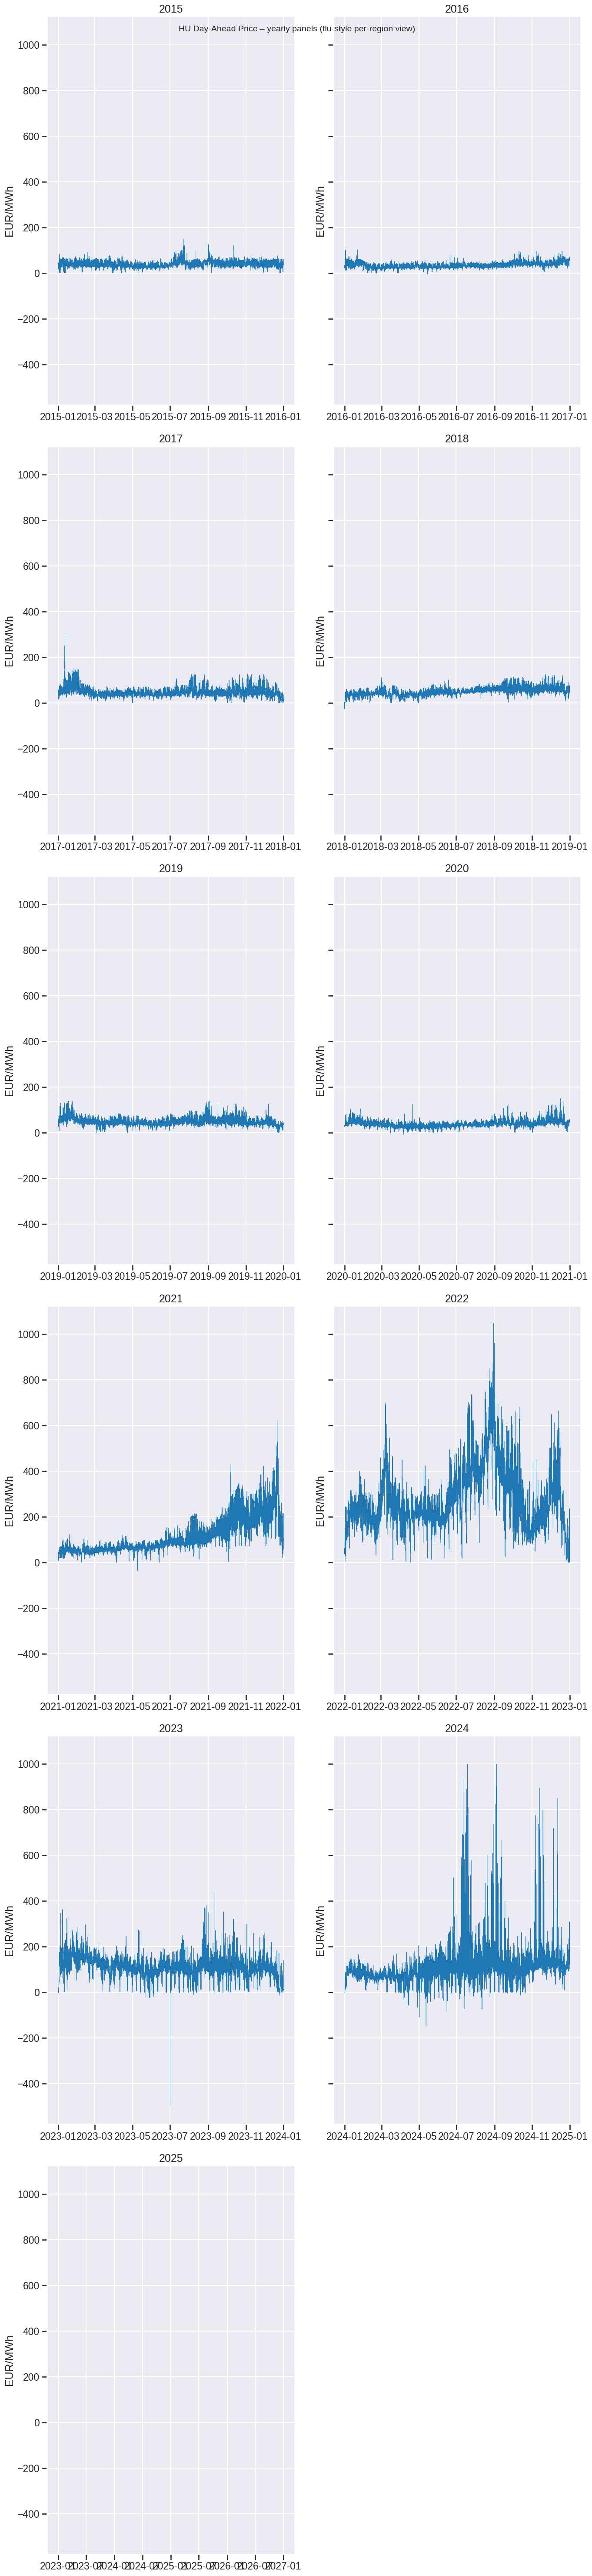

In [ ]:
# 2.2 Yearly panel view of HU day-ahead prices (flu-style per-region panels)

if RUN_EDA:
    df_price = df_15T[[PRICE_COL]].dropna().copy()
    df_price["year"] = df_price.index.year

    years = sorted(df_price["year"].unique())
    n_years = len(years)
    n_cols = 2
    n_rows = int(np.ceil(n_years / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 10 * n_rows), sharex=False, sharey=True)
    axes = axes.ravel()

    for ax, year in zip(axes, years):
        sub = df_price[df_price["year"] == year]
        ax.plot(sub.index, sub[PRICE_COL], linewidth=0.7)
        ax.set_title(str(year))
        ax.set_ylabel("EUR/MWh")

    for ax in axes[len(years):]:
        ax.axis("off")

    fig.suptitle("HU Day-Ahead Price – yearly panels (flu-style per-region view)", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("RUN_EDA is False – skipping yearly panel plots.")

Daily price series for decomposition: 2022-01-01 00:00:00 → 2024-12-30 00:00:00 | n = 1095


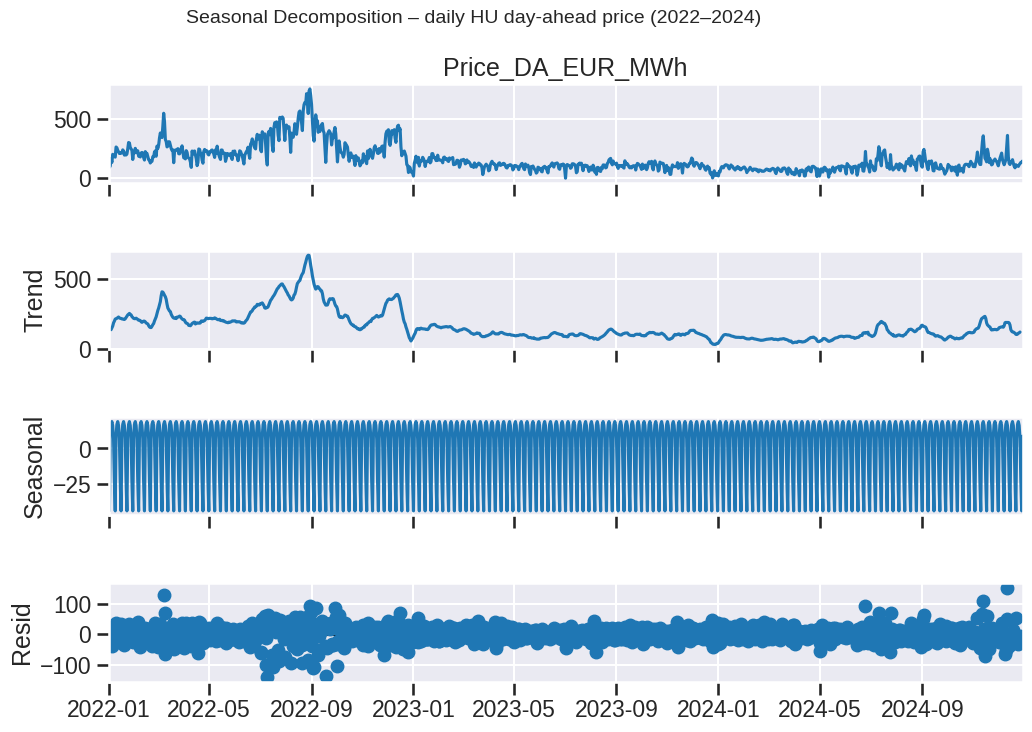

In [ ]:
# 2.3 Seasonal decomposition of daily prices – modelling regime only (2022–2024)

if RUN_EDA:
    model_start = pd.to_datetime(MODEL_START_DATE)
    model_end   = pd.to_datetime(MODEL_END_DATE)

    daily_price = (
        df_15T.loc[model_start:model_end, PRICE_COL]
        .dropna()
        .resample("D")
        .mean()
    )

    print("Daily price series for decomposition:",
          daily_price.index.min(), "→", daily_price.index.max(),
          "| n =", len(daily_price))

    if len(daily_price) > 2 * 52:
        decomp = seasonal_decompose(
            daily_price,
            model="additive",
            period=7  # weekly seasonality on daily data
        )

        fig = decomp.plot()
        fig.set_size_inches(12, 8)
        plt.suptitle("Seasonal Decomposition – daily HU day-ahead price (2022–2024)", fontsize=14)
        plt.show()
    else:
        print("Not enough daily data points for seasonal decomposition in 2022–2024 window.")
else:
    print("RUN_EDA is False – skipping seasonal decomposition.")

### 3. Core EDA: regimes, intraday patterns, correlations, ACF/PACF

 We:
 - Examine pre- vs post-2022 regime statistics and price volatility.
 - Explore intraday patterns, weekday/weekend effects, and high-price regimes.
 - Compute hourly correlation slices.
 - Inspect ACF/PACF for daily prices and the hourly 24h-ahead target.

count    87653.000000
mean        85.977574
std         91.606949
min       -500.000000
25%         37.020000
50%         54.780000
75%         96.480000
max       1047.100000
Name: Price_DA_EUR_MWh, dtype: float64

Pre-2022 price summary:
count    61354.000000
mean        54.363766
std         42.703744
min        -35.000000
25%         33.330000
50%         45.020000
75%         60.060000
max        620.000000
Name: Price_DA_EUR_MWh, dtype: float64

Post-2022 price summary:
count    26299.000000
mean       159.730706
std        126.270826
min       -500.000000
25%         84.950000
50%        120.000000
75%        198.000000
max       1047.100000
Name: Price_DA_EUR_MWh, dtype: float64


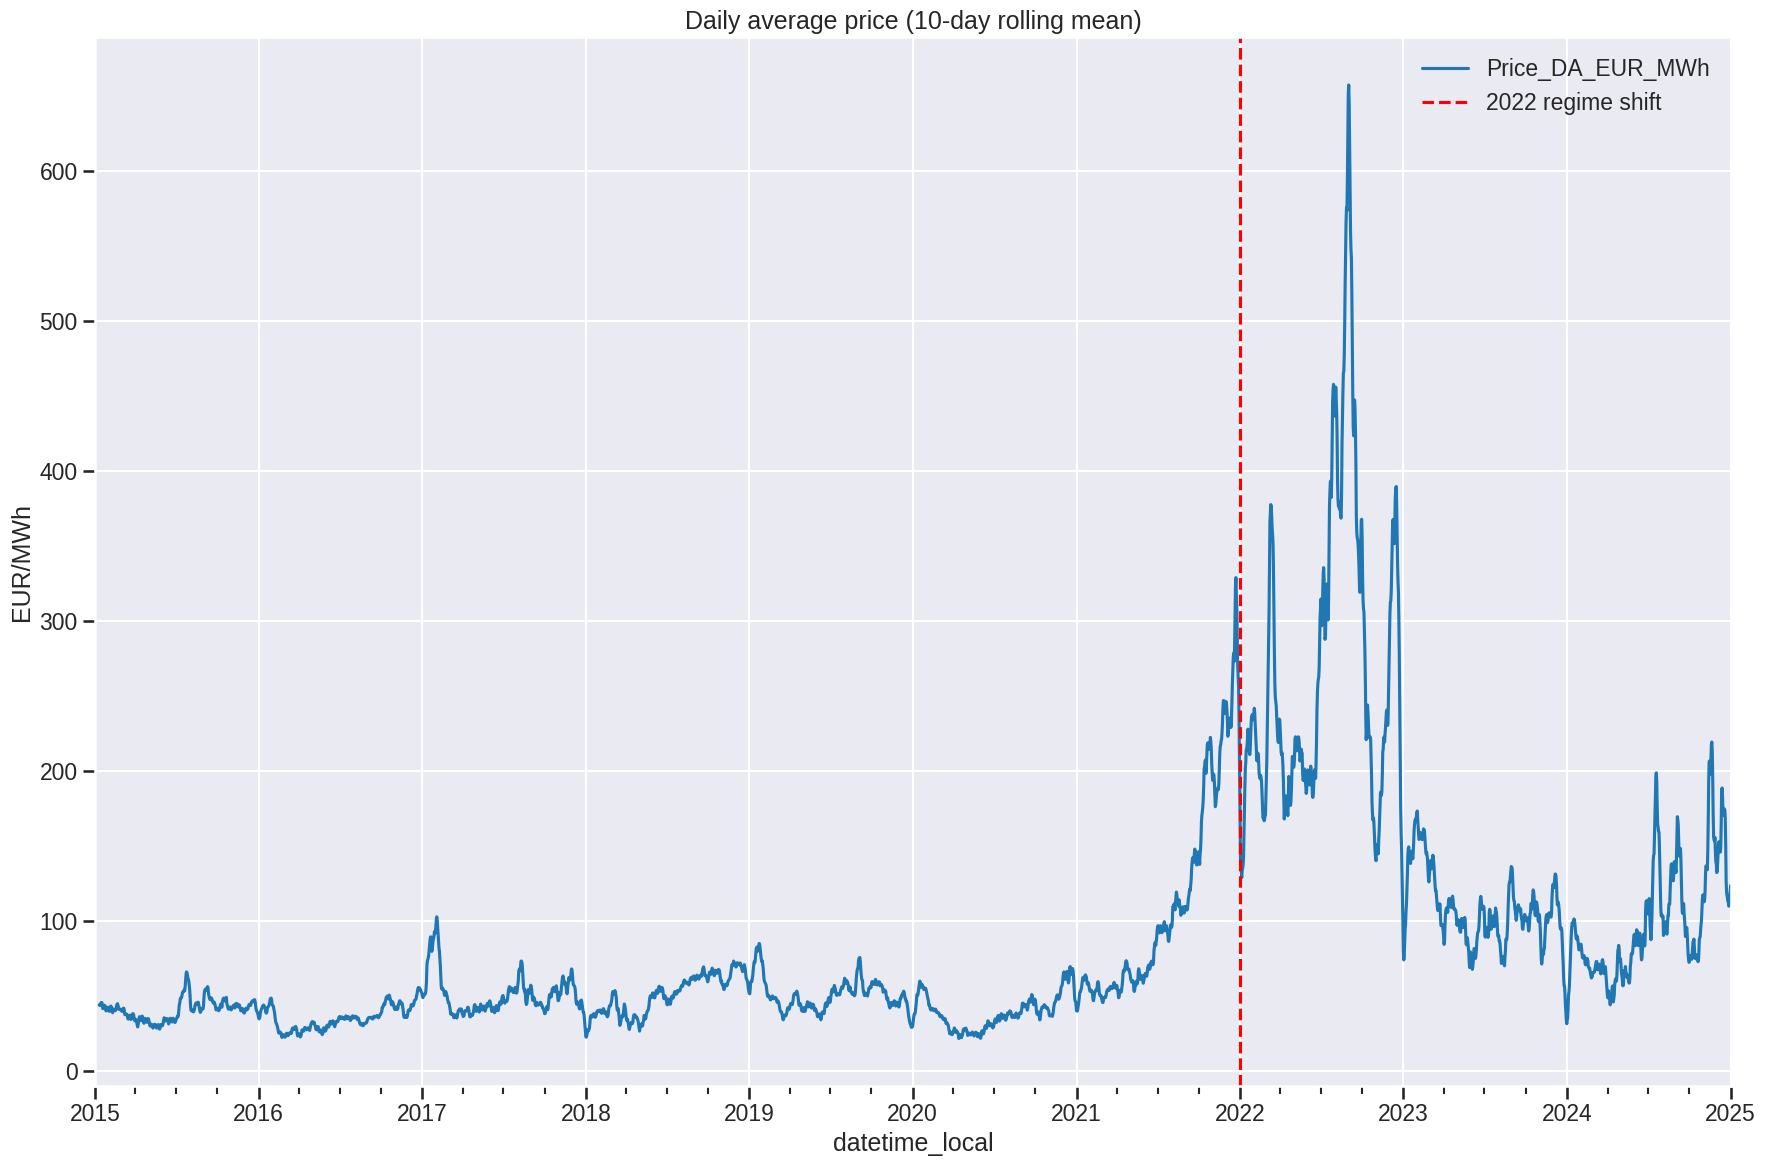

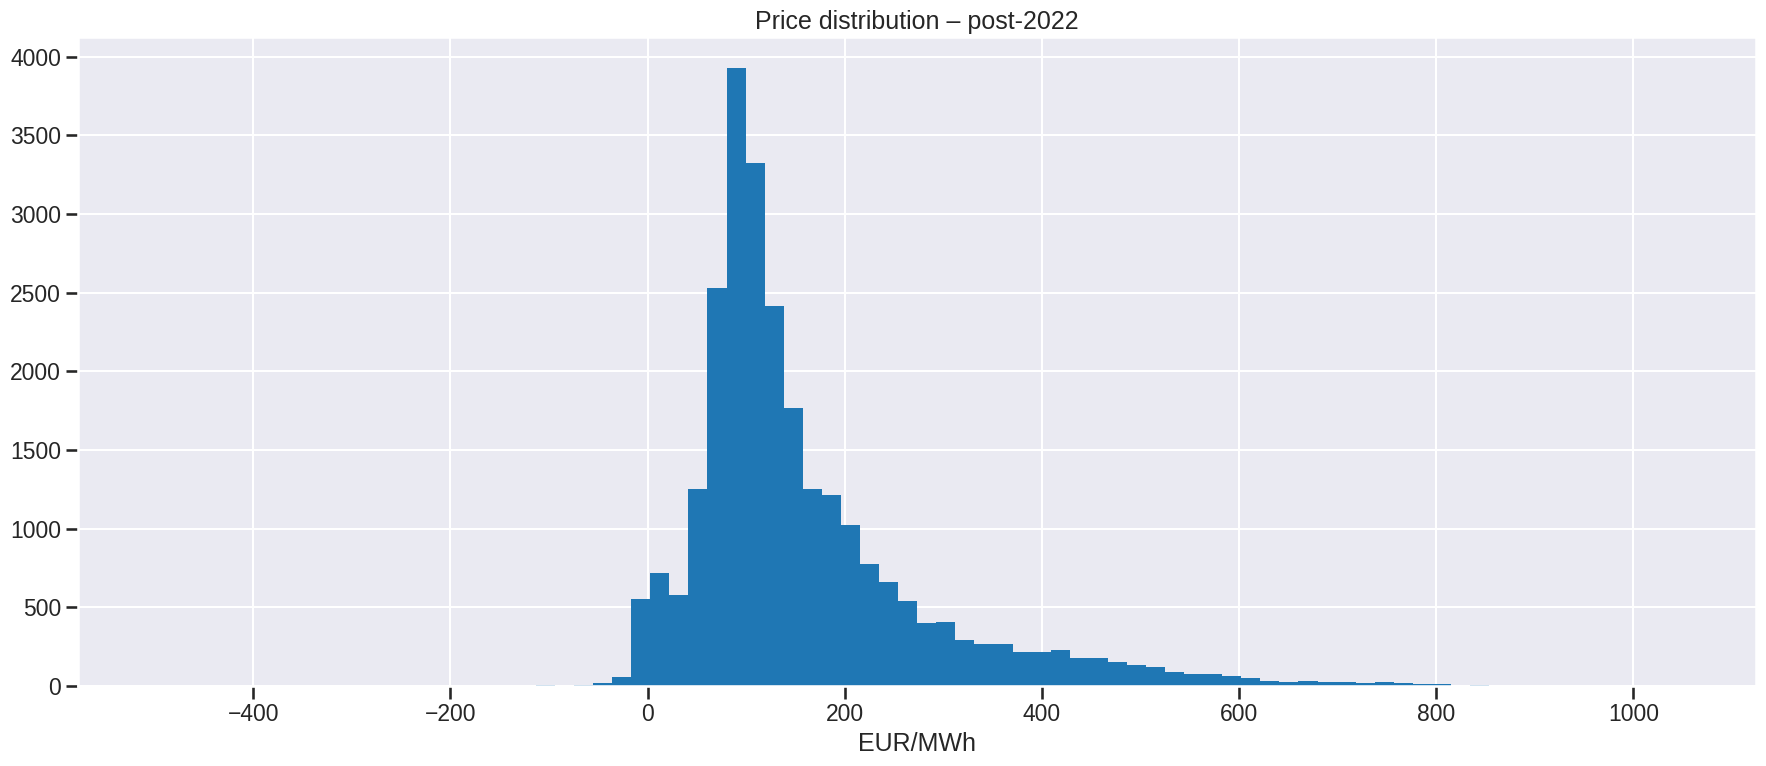

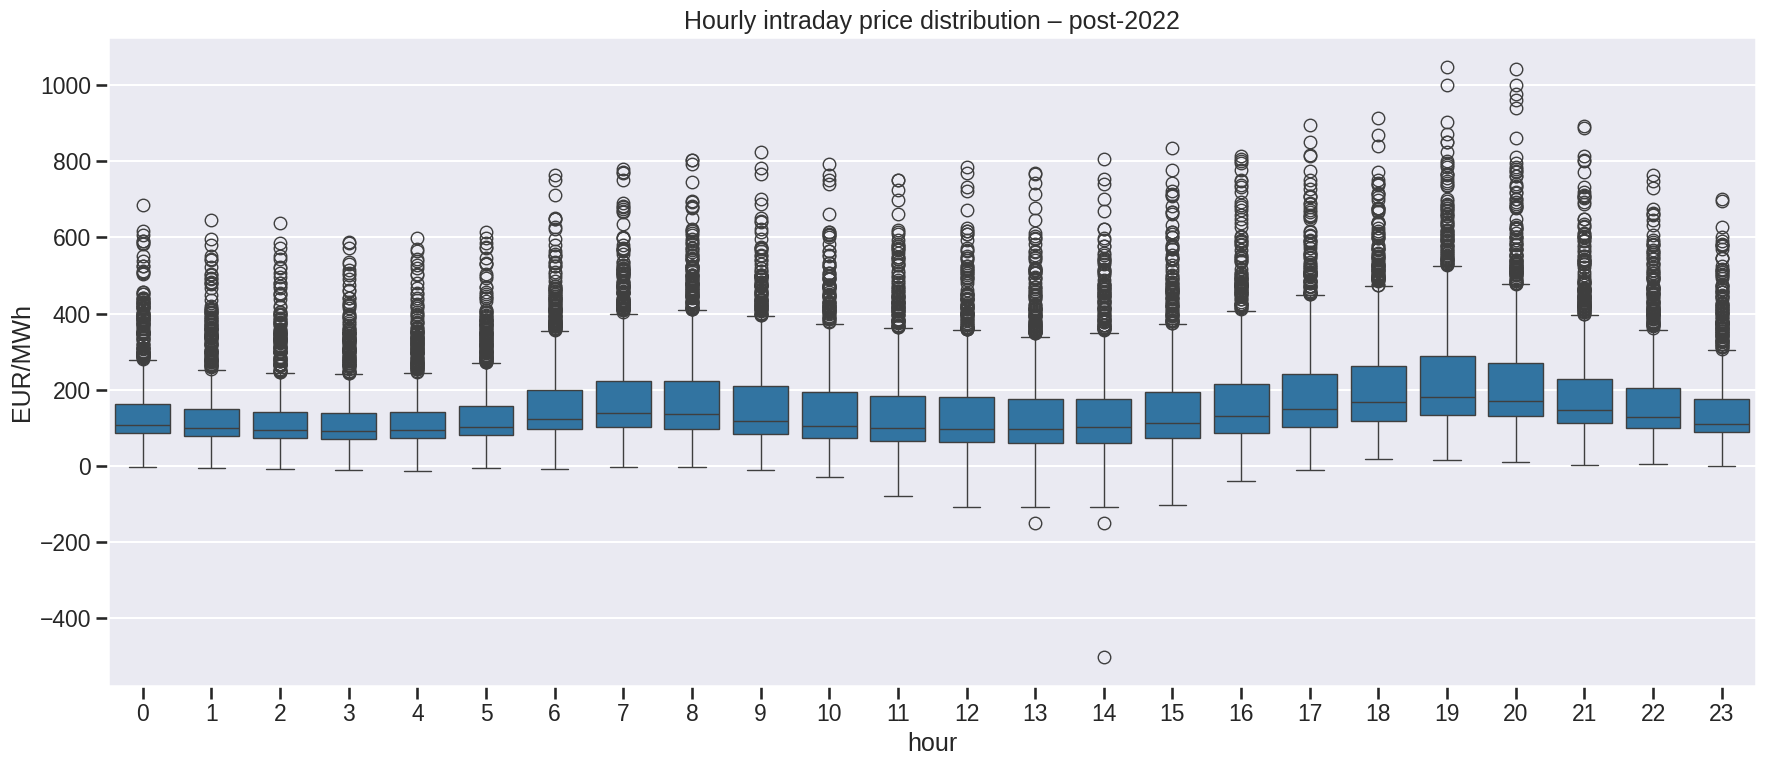


Price–load correlation (hourly):
                    Price_DA_EUR_MWh  Load_Actual_MW  Load_Forecast_MW  \
Price_DA_EUR_MWh            1.000000        0.327990          0.337460   
Load_Actual_MW              0.327990        1.000000          0.973761   
Load_Forecast_MW            0.337460        0.973761          1.000000   
Net_Position_DA_MW         -0.237861       -0.417515         -0.429197   
Gen_Solar                  -0.200335       -0.184276         -0.211811   
Gen_Wind Onshore           -0.123678        0.105714          0.091534   

                    Net_Position_DA_MW  Gen_Solar  Gen_Wind Onshore  
Price_DA_EUR_MWh             -0.237861  -0.200335         -0.123678  
Load_Actual_MW               -0.417515  -0.184276          0.105714  
Load_Forecast_MW             -0.429197  -0.211811          0.091534  
Net_Position_DA_MW            1.000000   0.680932         -0.094136  
Gen_Solar                     0.680932   1.000000         -0.160557  
Gen_Wind Onshore           

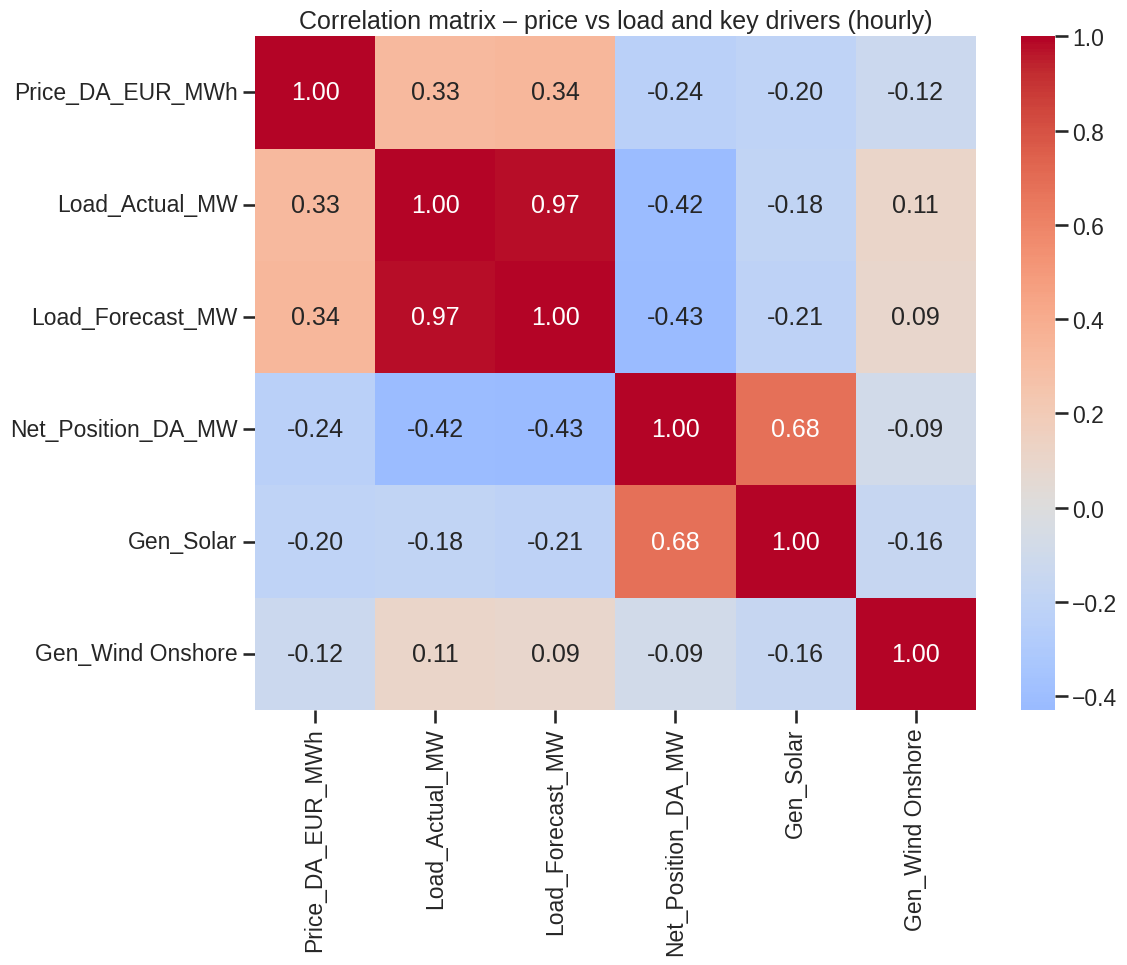

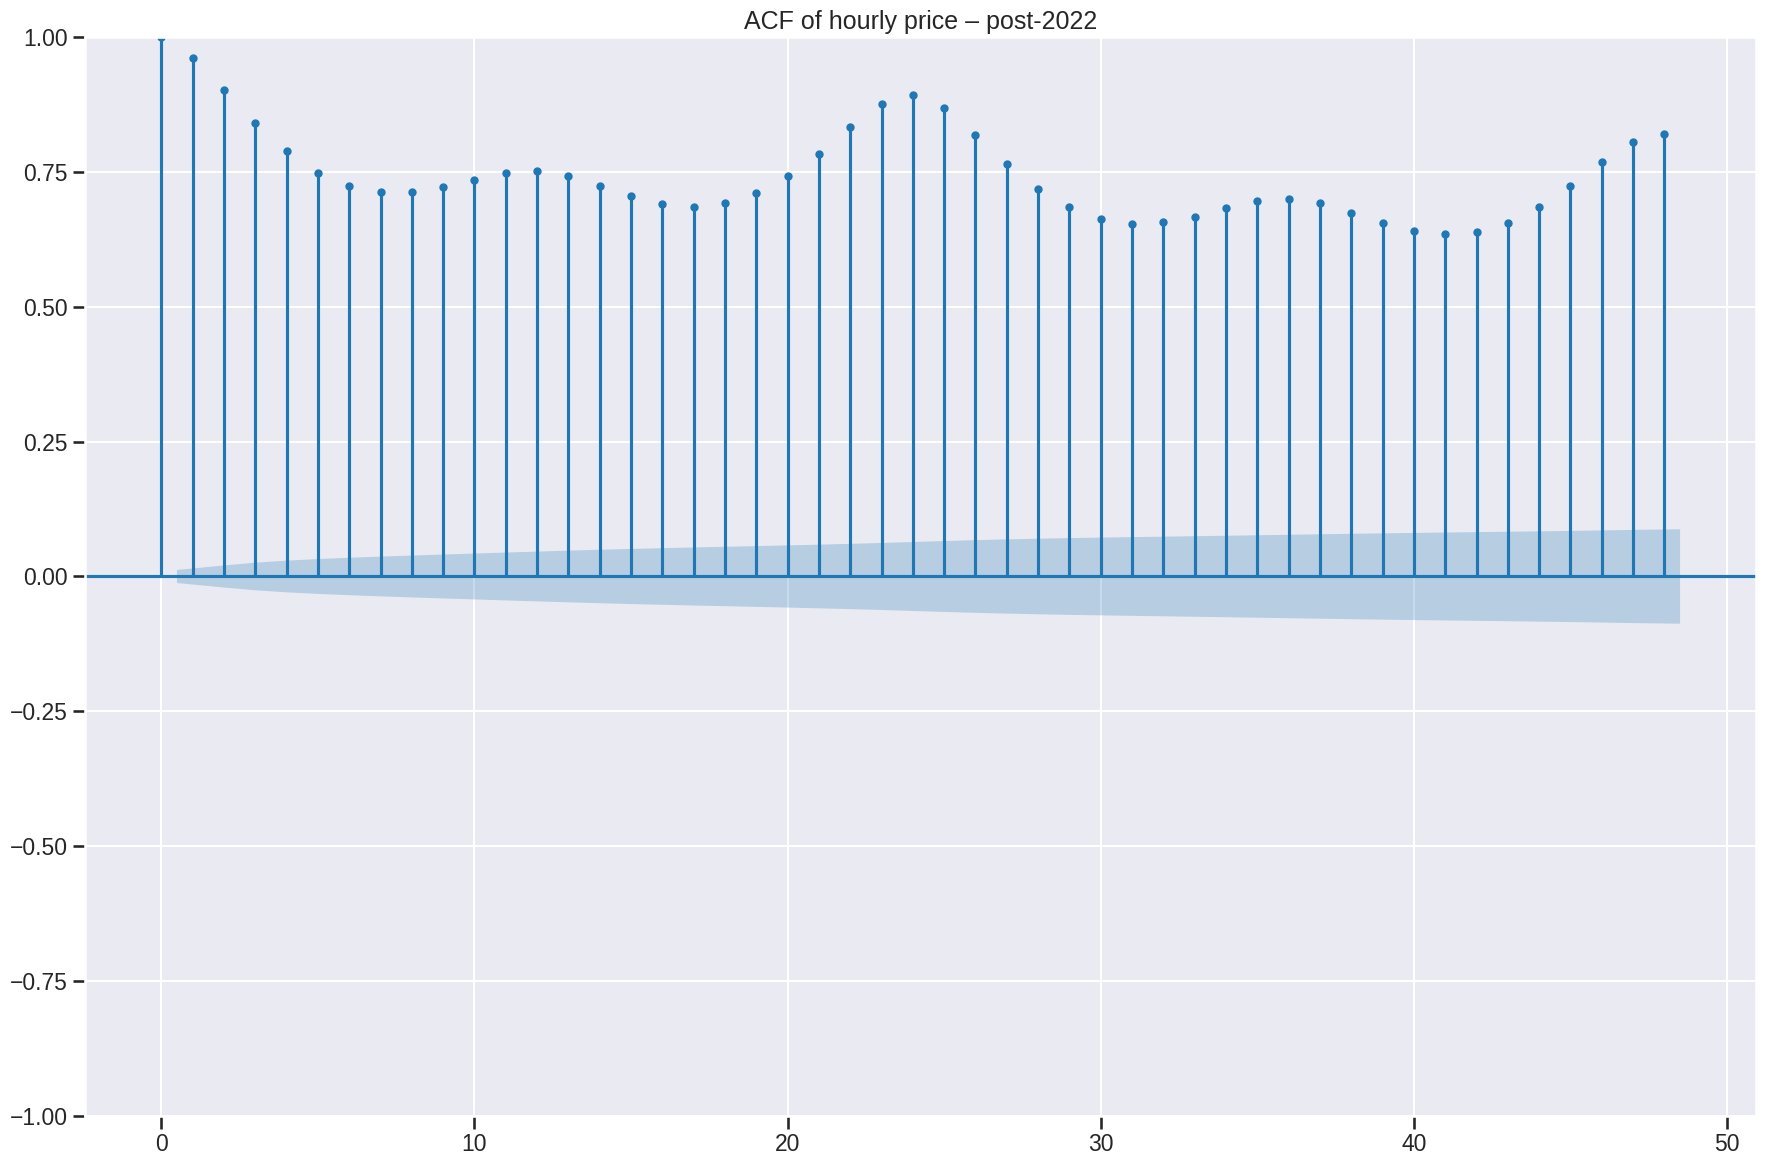

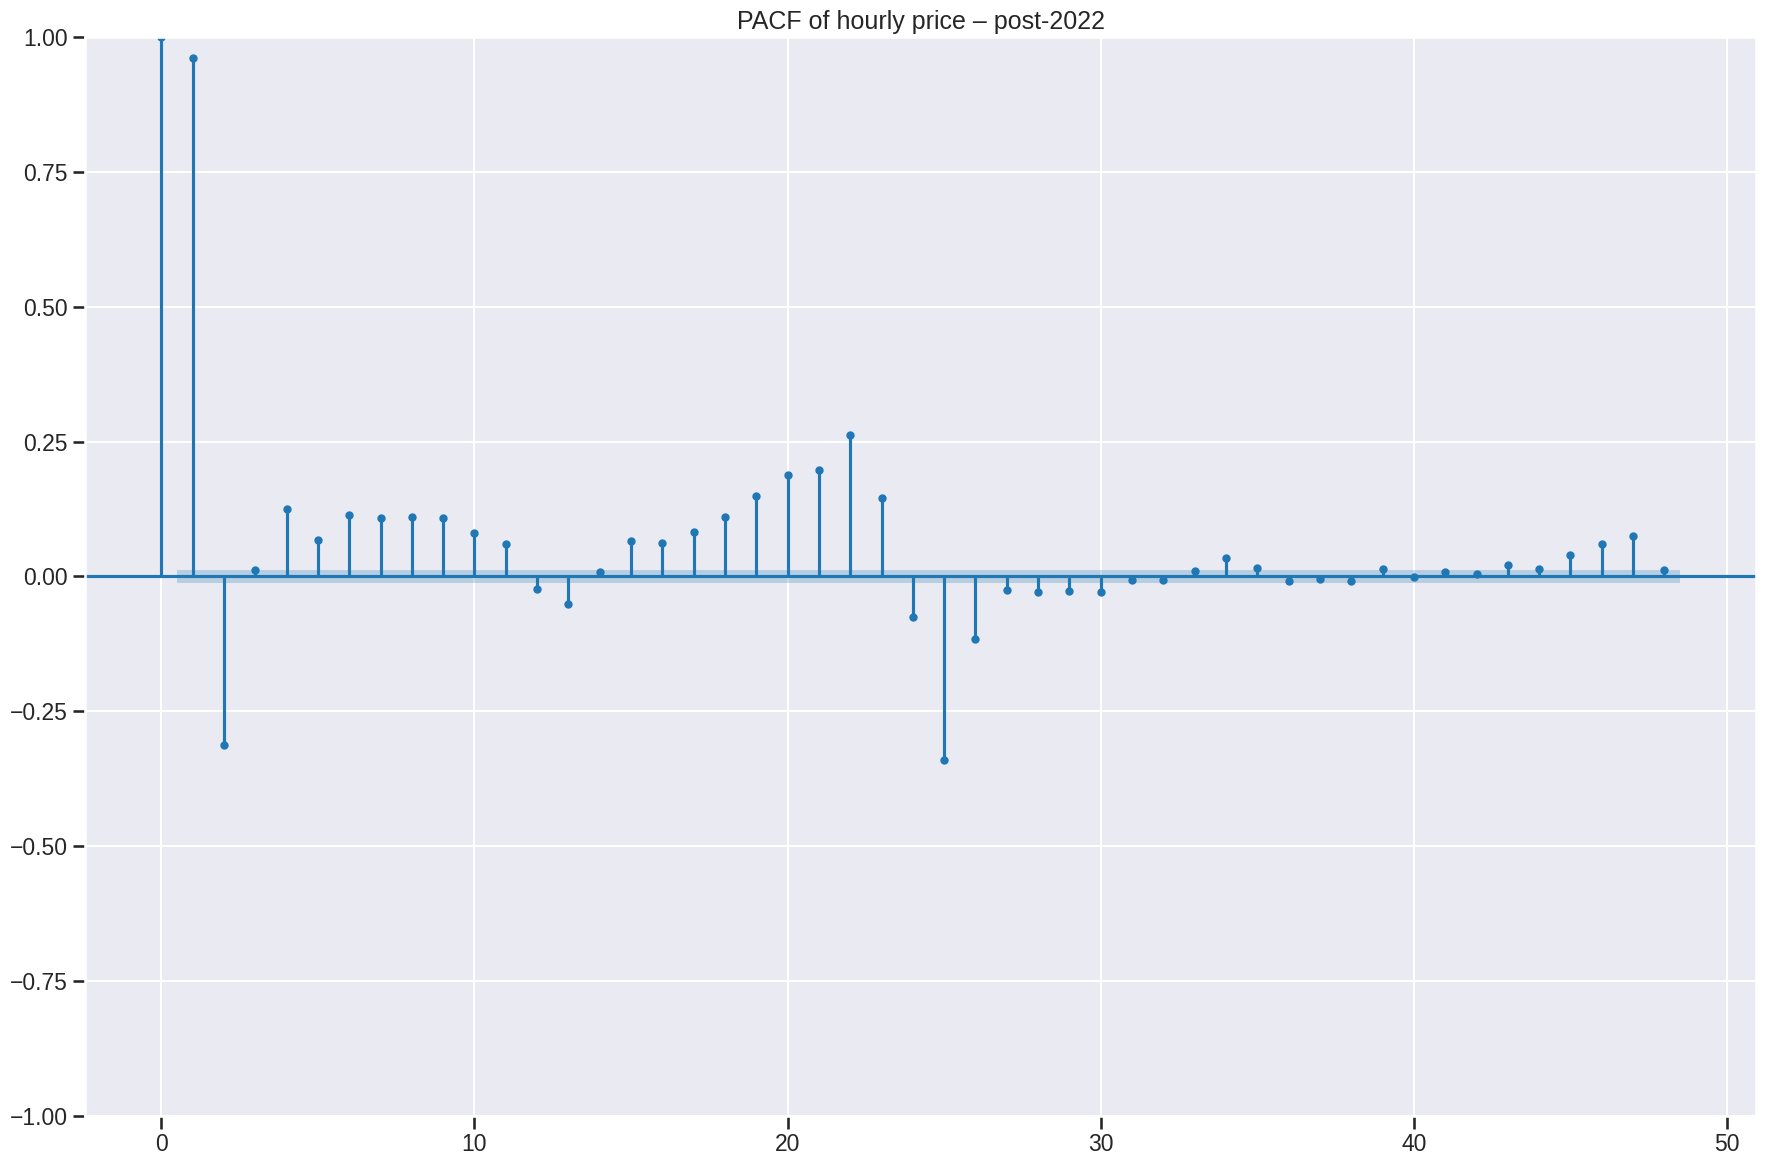

In [ ]:
# 3.1 EDA: price regimes, load, volatility, business context

if RUN_EDA:
    price_desc = df_15T[PRICE_COL].describe()
    print(price_desc)

    split_date = pd.to_datetime("2022-01-01")

    pre_price  = df_15T.loc[df_15T.index < split_date, PRICE_COL]
    post_price = df_15T.loc[df_15T.index >= split_date, PRICE_COL]

    print("\nPre-2022 price summary:")
    print(pre_price.describe())
    print("\nPost-2022 price summary:")
    print(post_price.describe())

    # 1) Long-run price series (10-day rolling mean)
    plt.figure(figsize=(18, 12))
    df_15T[PRICE_COL].resample("D").mean().rolling(10).mean().plot()
    plt.axvline(split_date, color="red", linestyle="--", label="2022 regime shift")
    plt.title("Daily average price (10-day rolling mean)")
    plt.ylabel("EUR/MWh")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 2) Histogram of post-2022 prices
    plt.figure(figsize=(18, 8))
    post_price.hist(bins=80)
    plt.title("Price distribution – post-2022")
    plt.xlabel("EUR/MWh")
    plt.tight_layout()
    plt.show()

    # 3) Intraday boxplot by hour (post-2022)
    hourly = df_15T.loc[df_15T.index >= split_date].resample("1H").mean()
    hourly["hour"] = hourly.index.hour

    plt.figure(figsize=(18, 8))
    sns.boxplot(x="hour", y=PRICE_COL, data=hourly.reset_index())
    plt.title("Hourly intraday price distribution – post-2022")
    plt.ylabel("EUR/MWh")
    plt.tight_layout()
    plt.show()

    # 4) Correlation with load & key drivers (post-2022, hourly)
    corr_cols = [
        PRICE_COL,
        "Load_Actual_MW",
        "Load_Forecast_MW",
        "Net_Position_DA_MW",
        "Gen_Solar",
        "Gen_Wind Onshore",
    ]
    corr_cols = [c for c in corr_cols if c in hourly.columns]
    corr = hourly[corr_cols].corr()
    print("\nPrice–load correlation (hourly):")
    print(corr)

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Correlation matrix – price vs load and key drivers (hourly)")
    plt.tight_layout()
    plt.show()

    # 5) ACF / PACF of post-2022 hourly price
    plt.figure(figsize=(18, 12))
    plot_acf(hourly[PRICE_COL].dropna(), ax=plt.gca(), lags=48)
    plt.title("ACF of hourly price – post-2022")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(18, 12))
    plot_pacf(hourly[PRICE_COL].dropna(), ax=plt.gca(), lags=48, method="ywm")
    plt.title("PACF of hourly price – post-2022")
    plt.tight_layout()
    plt.show()
else:
    print("RUN_EDA is False – skipping EDA (regimes & intraday).")

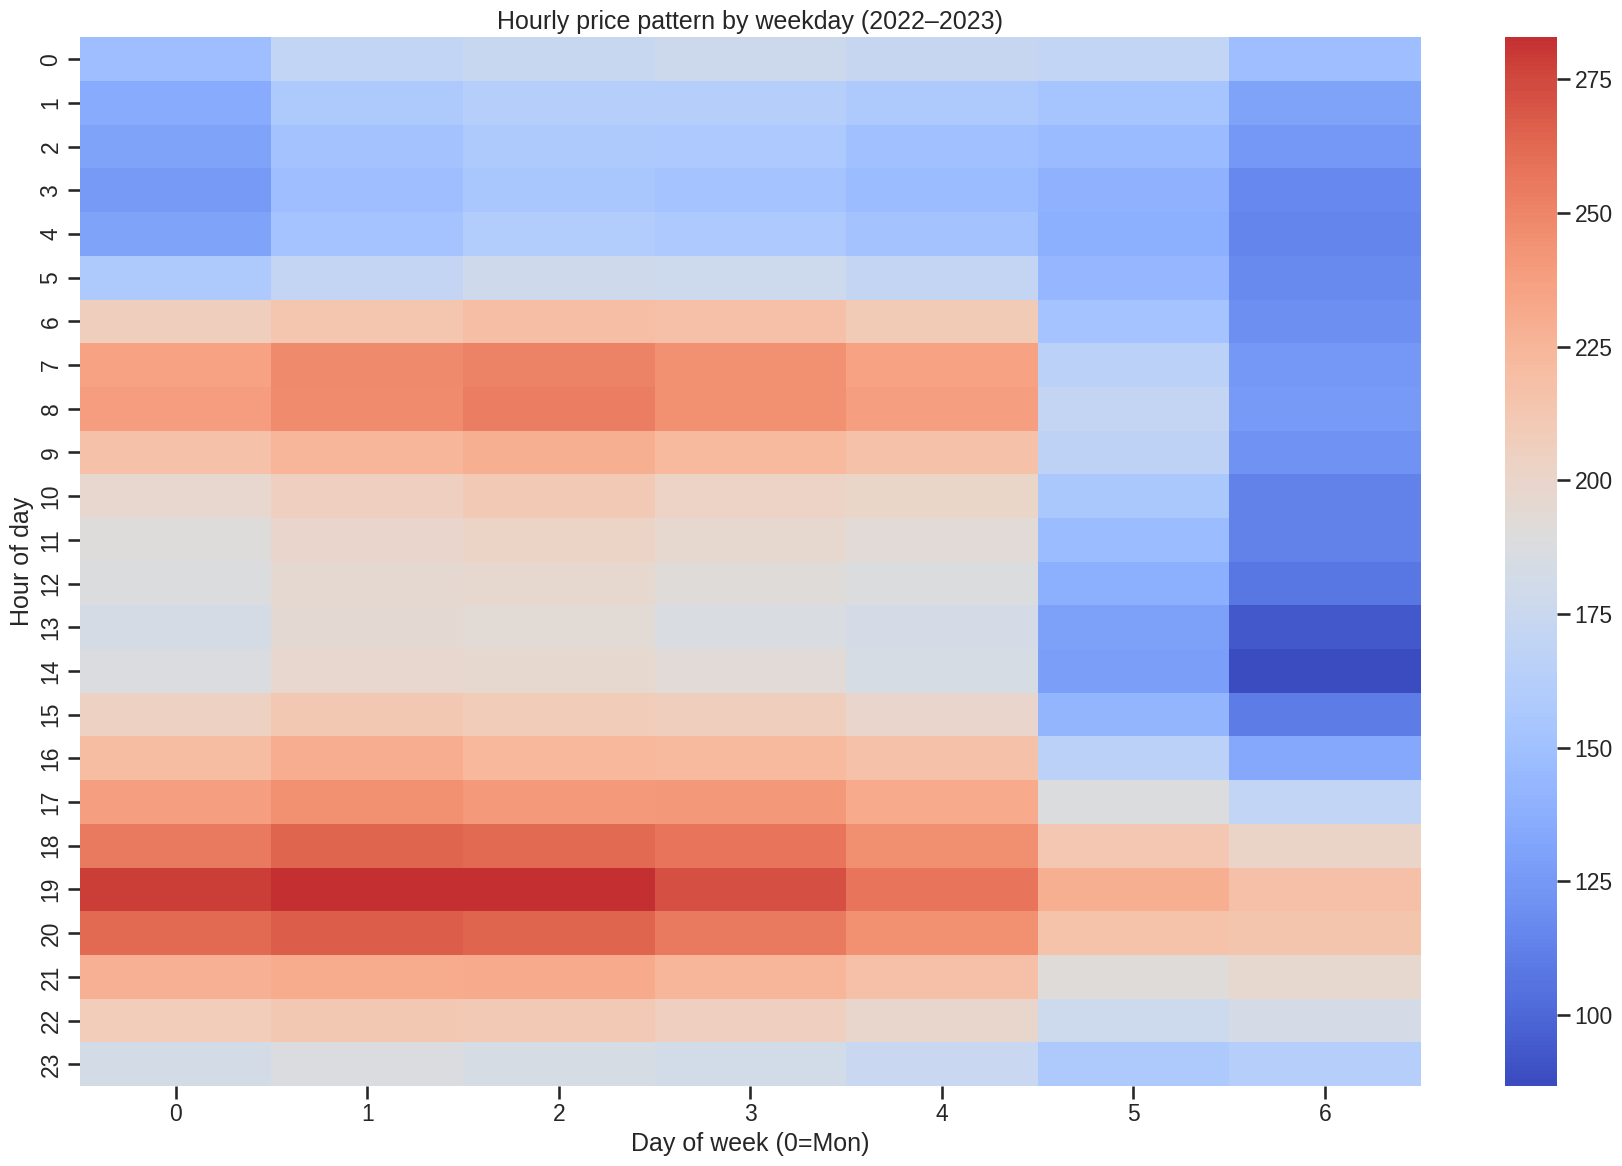


Quantiles of price in modelling window (EUR/MWh):
0.50    148.5300
0.75    239.9925
0.90    380.0900
0.95    468.6425
0.99    639.7345
Name: Price_DA_EUR_MWh, dtype: float64

Average drivers by regime (high vs normal prices):
                         Price_DA_EUR_MWh  Load_Actual_MW  Net_Position_DA_MW  \
high_price_flag                                                                 
normal (<=90th pct)            155.071136     4663.651946        -1412.026327   
high price (>=90th pct)        496.794866     4932.752868        -1525.967998   

                          Gen_Solar  Gen_Wind Onshore  
high_price_flag                                        
normal (<=90th pct)      430.830674         71.402334  
high price (>=90th pct)  392.174216         45.555442  


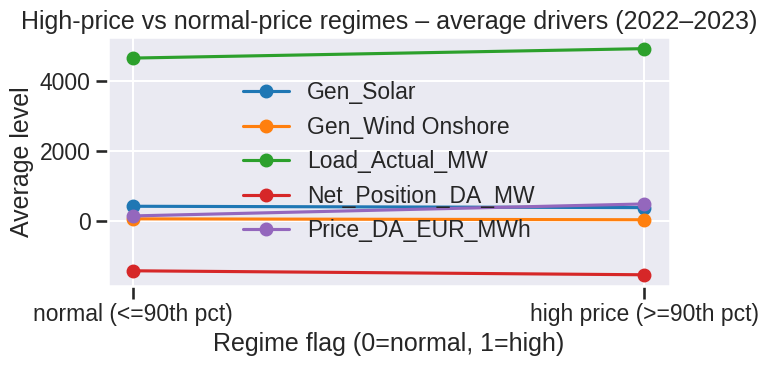

In [ ]:
# 3.2 Advanced EDA: intraday patterns & extreme price regimes (2022–2023)

if RUN_EDA:
    model_start = pd.to_datetime(MODEL_START_DATE)
    val_end     = pd.to_datetime(VAL_END_DATE)

    df_15T_win = df_15T.loc[model_start:val_end].copy()
    df_hourly = df_15T_win.resample("1H").mean()

    df_hourly["hour"] = df_hourly.index.hour
    df_hourly["dayofweek"] = df_hourly.index.dayofweek
    df_hourly["is_weekend"] = df_hourly["dayofweek"].isin([5, 6]).astype(int)

    # Hour × weekday heatmap
    price_pivot = df_hourly.pivot_table(
        values=PRICE_COL,
        index="hour",
        columns="dayofweek",
        aggfunc="mean"
    ).sort_index()

    plt.figure(figsize=(18, 12))
    sns.heatmap(price_pivot, cmap="coolwarm", center=price_pivot.values.mean())
    plt.title("Hourly price pattern by weekday (2022–2023)")
    plt.xlabel("Day of week (0=Mon)")
    plt.ylabel("Hour of day")
    plt.tight_layout()
    plt.show()

    # High-price regimes vs normal (90th percentile split)
    price_q = df_hourly[PRICE_COL].quantile([0.5, 0.75, 0.9, 0.95, 0.99])
    print("\nQuantiles of price in modelling window (EUR/MWh):")
    print(price_q)

    p90 = price_q.loc[0.9]
    df_hourly["high_price_flag"] = np.where(df_hourly[PRICE_COL] >= p90, 1, 0)

    cols_for_regime = [
        PRICE_COL,
        "Load_Actual_MW",
        "Net_Position_DA_MW",
        "Gen_Solar",
        "Gen_Wind Onshore",
    ]
    cols_for_regime = [c for c in cols_for_regime if c in df_hourly.columns]

    regime_group = (
        df_hourly[cols_for_regime + ["high_price_flag"]]
        .groupby("high_price_flag")
        .mean()
        .rename(index={0: "normal (<=90th pct)", 1: "high price (>=90th pct)"})
    )

    print("\nAverage drivers by regime (high vs normal prices):")
    print(regime_group)

    regime_melt = regime_group.reset_index().melt(
        id_vars="high_price_flag", var_name="variable", value_name="value"
    )

    plt.figure(figsize=(8, 4))
    for var, grp in regime_melt.groupby("variable"):
        xs = grp["high_price_flag"]
        ys = grp["value"]
        plt.plot(xs, ys, marker="o", label=var)

    plt.title("High-price vs normal-price regimes – average drivers (2022–2023)")
    plt.ylabel("Average level")
    plt.xlabel("Regime flag (0=normal, 1=high)")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("RUN_EDA is False – skipping advanced EDA (regimes).")

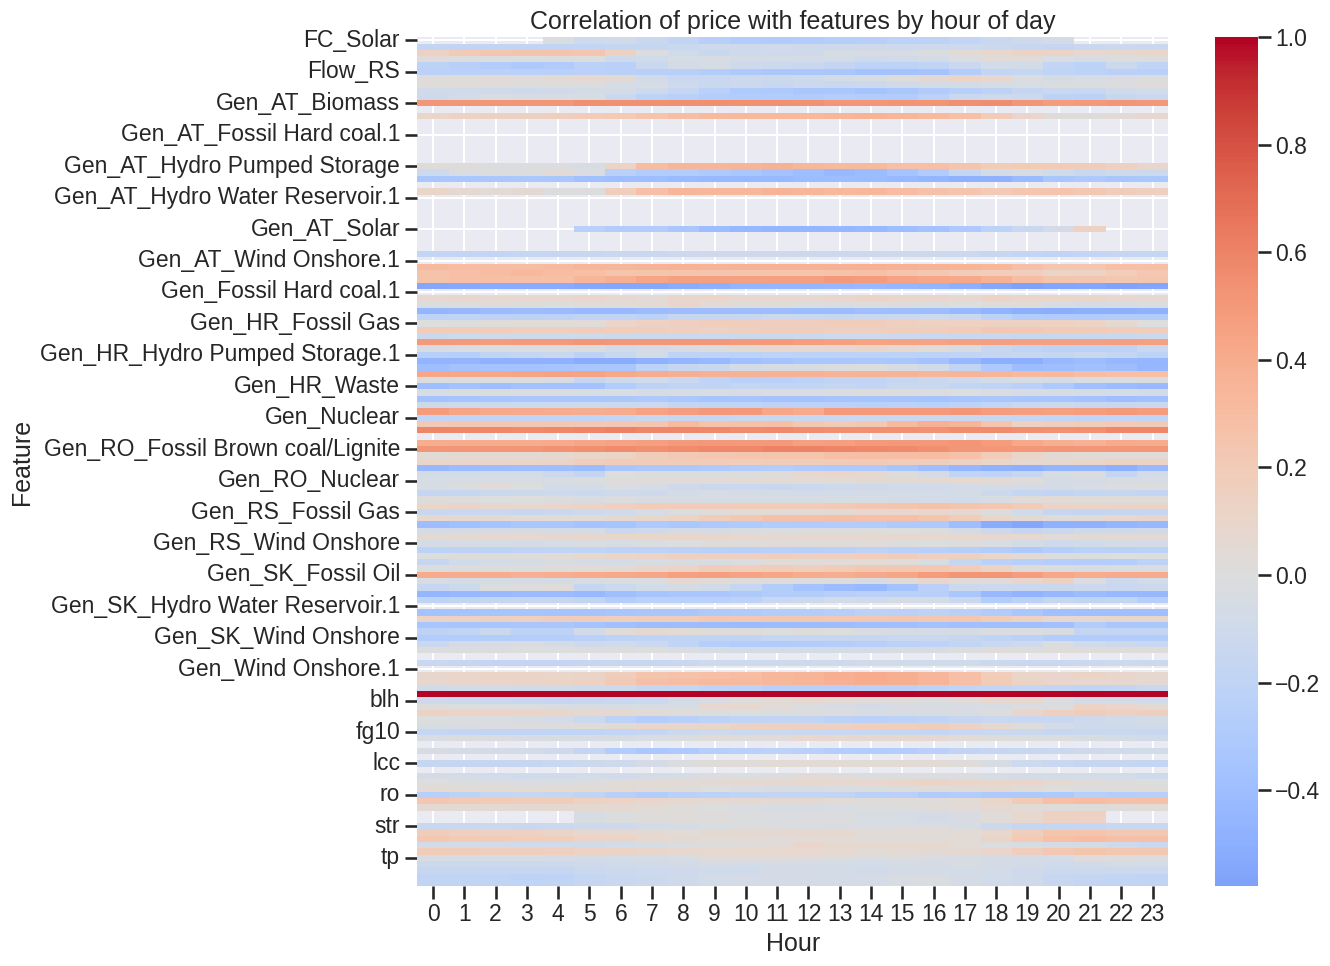

In [ ]:
# 3.3 Intraday / seasonal correlation slices (panel view)

if RUN_EDA:
    model_start = pd.to_datetime(MODEL_START_DATE)
    val_end     = pd.to_datetime(VAL_END_DATE)

    df_15T_win = df_15T.loc[model_start:val_end].copy()
    df_hourly  = df_15T_win.resample("1H").mean()

    df_hourly["hour"]       = df_hourly.index.hour
    df_hourly["dayofweek"]  = df_hourly.index.dayofweek
    df_hourly["month"]      = df_hourly.index.month
    df_hourly["is_weekend"] = df_hourly["dayofweek"].isin([5, 6]).astype(int)

    key_numeric_cols = [c for c in df_hourly.columns if c != PRICE_COL and np.issubdtype(df_hourly[c].dtype, np.number)]

    hourly_corrs = []
    for h in range(24):
        sub = df_hourly[df_hourly["hour"] == h]
        if len(sub) < 100:
            continue
        corr_series = sub[key_numeric_cols + [PRICE_COL]].corr()[PRICE_COL]
        hourly_corrs.append(pd.DataFrame({
            "hour": h,
            "feature": corr_series.index,
            "corr": corr_series.values
        }))

    if hourly_corrs:
        hourly_corrs = pd.concat(hourly_corrs, ignore_index=True)

        corr_pivot = hourly_corrs.pivot(index="feature", columns="hour", values="corr")

        plt.figure(figsize=(14, 10))
        sns.heatmap(corr_pivot, cmap="coolwarm", center=0)
        plt.title("Correlation of price with features by hour of day")
        plt.xlabel("Hour")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough data per hour slice for correlation heatmap.")
else:
    print("RUN_EDA is False – skipping intraday correlation slices.")

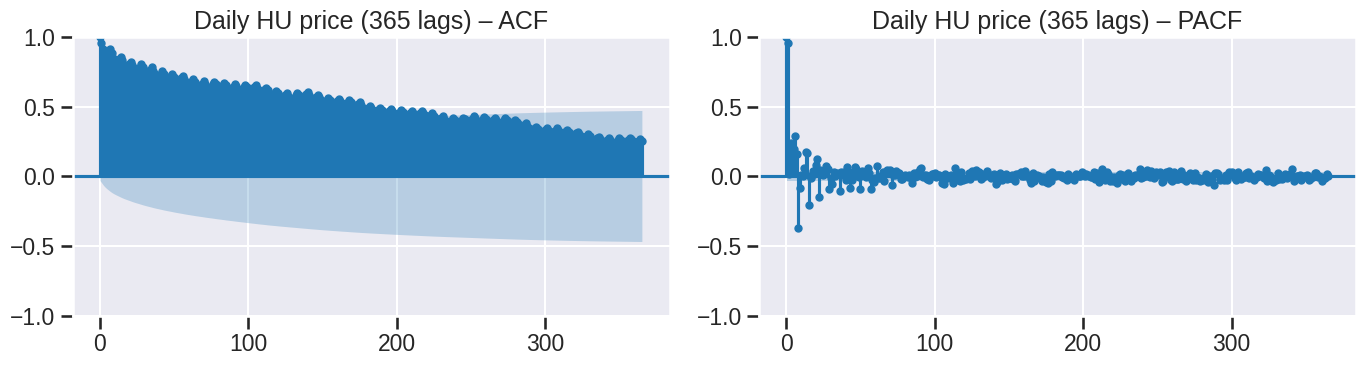

In [ ]:
# 3.4 ACF/PACF diagnostics for daily price (longer lags)

if RUN_EDA:
    # ACF/PACF for daily mean prices – full range
    daily_price_full = df_15T[PRICE_COL].dropna().resample("D").mean()
    plot_acf_pacf_series(daily_price_full, lags=365, title_prefix="Daily HU price (365 lags)")
else:
    print("RUN_EDA is False – skipping ACF/PACF diagnostics for daily price.")

### 4. Feature engineering: hourly and 15-minute enhanced sets

 Steps:
 - Aggregate 15-minute data to hourly (`feat_1H`).
 - Construct the 24h-ahead target (`target_24h`).
 - Add calendar variables, lagged prices, rolling statistics, cross-border flows, and weather-derived features.
 - Build:
   - `df_no_wx` – non-weather features only (for ablation).
   - `df_1H`    – non-weather + hourly weather.
   - `df_15Tf`  – non-weather + hourly + 15T-derived weather.

In [ ]:
# Cell 7 – feature engineering (hourly + 15T-derived weather, target_24h)

if RUN_FEATURE_ENGINEERING:
    model_start = pd.to_datetime(MODEL_START_DATE)
    model_end   = pd.to_datetime(MODEL_END_DATE)

    df_15T_win = df_15T.loc[model_start:model_end].copy()
    data_1H = df_15T_win.resample("1H").mean()

    feat_1H = data_1H.copy()

    # 1) 24h-ahead target
    feat_1H[TARGET_COL] = feat_1H[PRICE_COL].shift(-HORIZON_HOURS)

    # 2) Lags
    lag_hours = [1, 2, 3, 6, 12, 24]
    for lag in lag_hours:
        feat_1H[f"price_lag_{lag}h"] = feat_1H[PRICE_COL].shift(lag)
        if "Load_Actual_MW" in feat_1H.columns:
            feat_1H[f"load_actual_lag_{lag}h"] = feat_1H["Load_Actual_MW"].shift(lag)

    # Price change (diff) and rolling stats
    feat_1H["price_diff_1h"] = feat_1H[PRICE_COL].diff()
    feat_1H["price_rolling_std_24h"] = feat_1H[PRICE_COL].rolling(24).std()
    feat_1H["price_rolling_mean_24h"] = feat_1H[PRICE_COL].rolling(24).mean()

    if "Load_Actual_MW" in feat_1H.columns:
        feat_1H["load_rolling_mean_24h"] = feat_1H["Load_Actual_MW"].rolling(24).mean()
        feat_1H["load_rolling_std_24h"]  = feat_1H["Load_Actual_MW"].rolling(24).std()

    # 3) Calendar
    feat_1H["hour"]       = feat_1H.index.hour
    feat_1H["dayofweek"]  = feat_1H.index.dayofweek
    feat_1H["month"]      = feat_1H.index.month
    feat_1H["is_weekend"] = feat_1H["dayofweek"].isin([5, 6]).astype(int)

    # 4) Cross-border flows
    flow_cols = [c for c in feat_1H.columns if c.startswith("Flow_")]
    if flow_cols:
        feat_1H["Flow_net_sum"] = feat_1H[flow_cols].sum(axis=1)
        if "Load_Actual_MW" in feat_1H.columns:
            feat_1H["Flow_net_per_load"] = (
                feat_1H["Flow_net_sum"] / feat_1H["Load_Actual_MW"].replace(0, np.nan)
            )

    # 5) Weather-derived features (hourly)
    if {"u10", "v10"}.issubset(feat_1H.columns):
        feat_1H["wind_speed_10m"] = np.sqrt(feat_1H["u10"]**2 + feat_1H["v10"]**2)
    if {"u100", "v100"}.issubset(feat_1H.columns):
        feat_1H["wind_speed_100m"] = np.sqrt(feat_1H["u100"]**2 + feat_1H["v100"]**2)

    if "ssrd" in feat_1H.columns:
        feat_1H["solar_irradiance"] = feat_1H["ssrd"]
    elif "ssr" in feat_1H.columns:
        feat_1H["solar_irradiance"] = feat_1H["ssr"]

    if "solar_irradiance" in feat_1H.columns:
        feat_1H["is_daylight"] = (feat_1H["solar_irradiance"] > 0).astype(int)

    if "t2m" in feat_1H.columns:
        feat_1H["temp_C"] = feat_1H["t2m"] - 273.15
    if "d2m" in feat_1H.columns:
        feat_1H["dewpoint_C"] = feat_1H["d2m"] - 273.15
    if {"temp_C", "dewpoint_C"}.issubset(feat_1H.columns):
        feat_1H["temp_dewpoint_spread"] = feat_1H["temp_C"] - feat_1H["dewpoint_C"]

    # 6) 15T-derived intrahour weather variability (aggregated to 1H)
    numeric_15T = df_15T_win.select_dtypes(include=[np.number])
    wx_var_candidates = [c for c in WEATHER_BASE_VARS if c in numeric_15T.columns]
    if wx_var_candidates:
        wx_agg = numeric_15T[wx_var_candidates].resample("1H").agg(["min", "max", "std"])
        wx_agg.columns = [f"{var}_1h_{stat}" for (var, stat) in wx_agg.columns]
        feat_1H = feat_1H.join(wx_agg, how="left")

    # 7) Define feature groups
    numeric_cols = feat_1H.select_dtypes(include=[np.number]).columns.tolist()

    base_weather_candidates = [
        "u10", "v10", "d2m", "t2m", "u100", "v100",
        "tcwv", "tp", "ssr", "str", "ssrd", "strd",
        "e", "ro", "cp", "fg10", "hcc", "lcc", "mcc", "tcc",
        "wind_speed_10m", "wind_speed_100m",
        "solar_irradiance", "temp_C", "dewpoint_C", "temp_dewpoint_spread",
    ]
    base_weather_cols = [c for c in base_weather_candidates if c in numeric_cols]

    wx_15T_cols = [c for c in numeric_cols if "_1h_min" in c or "_1h_max" in c or "_1h_std" in c]

    exclude_from_common = set([TARGET_COL] + base_weather_cols + wx_15T_cols)
    common_feature_cols = [c for c in numeric_cols if c not in exclude_from_common]

    print("Number of common (non-weather) features:", len(common_feature_cols))
    print("Number of base hourly weather features:", len(base_weather_cols))
    print("Number of 15T-derived weather features:", len(wx_15T_cols))

    # 8) Build modelling datasets for ablation
    df_no_wx = feat_1H[common_feature_cols + [TARGET_COL]].dropna(subset=[TARGET_COL])
    df_1H    = feat_1H[common_feature_cols + base_weather_cols + [TARGET_COL]].dropna(subset=[TARGET_COL])

    if wx_15T_cols:
        df_15Tf = feat_1H[common_feature_cols + base_weather_cols + wx_15T_cols + [TARGET_COL]].dropna(subset=[TARGET_COL])
    else:
        df_15Tf = df_1H.copy()

    print("df_no_wx shape:", df_no_wx.shape)
    print("df_1H shape   (1H weather):", df_1H.shape)
    print("df_15Tf shape (1H + 15T): ", df_15Tf.shape)

    df_no_wx.to_parquet(MODEL_NO_WX_PATH)
    df_1H.to_parquet(MODEL_1H_PATH)
    df_15Tf.to_parquet(MODEL_15T_PATH)
    print("Saved df_no_wx to:", MODEL_NO_WX_PATH)
    print("Saved df_1H    to:", MODEL_1H_PATH)
    print("Saved df_15Tf  to:", MODEL_15T_PATH)
else:
    print("RUN_FEATURE_ENGINEERING is False – loading feature datasets from disk.")
    df_no_wx = pd.read_parquet(MODEL_NO_WX_PATH)
    df_1H    = pd.read_parquet(MODEL_1H_PATH)
    df_15Tf  = pd.read_parquet(MODEL_15T_PATH)

Number of common (non-weather) features: 135
Number of base hourly weather features: 26
Number of 15T-derived weather features: 60
df_no_wx shape: (26251, 136)
df_1H shape   (1H weather): (26251, 162)
df_15Tf shape (1H + 15T):  (26251, 222)


Saved df_no_wx to: /teamspace/studios/this_studio/Notebook_v2/data/model_data_no_weather_v4.parquet
Saved df_1H    to: /teamspace/studios/this_studio/Notebook_v2/data/model_data_hourly_weather_v4.parquet
Saved df_15Tf  to: /teamspace/studios/this_studio/Notebook_v2/data/model_data_15T_features_v4.parquet


### 5. Baseline ML models (Naive, Linear, XGBoost) and diagnostics

 We now build the forecasting baselines:
 1. Prepare consistent train/validation/test splits and a **Naive last-24h** benchmark.
 2. Fit **Linear Regression** and **XGBoost** models on:
    - `df_no_wx`   (no weather),
    - `df_1H`      (hourly weather),
    - `df_15Tf`    (hourly + 15T-derived weather).
 3. Run a compact **hyperparameter tuning** for XGBoost (1H and 15T).
 4. Analyse **feature importances** and short-horizon diagnostics.

In [ ]:
# 5.1 Splits, Naive baseline, ML matrices

results_rows = []

if RUN_BASE_MODELS:
    # Ensure no all-NA columns
    df_no_wx = df_no_wx.dropna(axis=1, how="all")
    df_1H    = df_1H.dropna(axis=1, how="all")
    df_15Tf  = df_15Tf.dropna(axis=1, how="all")

    # Time-based splits for all three datasets
    X_train_no,  y_train_no,  X_val_no,  y_val_no,  X_test_no,  y_test_no  = time_split(df_no_wx, TARGET_COL)
    X_train_1H,  y_train_1H,  X_val_1H,  y_val_1H,  X_test_1H,  y_test_1H  = time_split(df_1H,   TARGET_COL)
    X_train_15T, y_train_15T, X_val_15T, y_val_15T, X_test_15T, y_test_15T = time_split(df_15Tf, TARGET_COL)

    # Naive baseline: last 24h price (from 1H feature set)
    if "price_lag_24h" in X_test_1H.columns:
        naive_pred_full = X_test_1H["price_lag_24h"].astype(float)
        mask = (~y_test_1H.isna()) & (~naive_pred_full.isna())
        if mask.sum() == 0:
            print("WARNING: no valid observations for Naive_last_24h after dropping NaNs.")
            naive_pred_test = naive_pred_full
        else:
            naive_pred_test = naive_pred_full
            naive_metrics = evaluate_forecast(y_test_1H[mask], naive_pred_full[mask])
            naive_metrics["n"] = int(mask.sum())
            results_rows.append({
                "model": "Naive_last_24h",
                "subset": "test",
                **naive_metrics,
            })
    else:
        print("WARNING: price_lag_24h missing – Naive_last_24h not evaluated.")
        naive_pred_test = None

    # ML matrices (domain-aware imputation inside)
    feat_no,  Xtr_no_m,  ytr_no_m,  Xv_no_m,  yv_no_m,  Xte_no_m,  yte_no_m  = make_ml_matrices(
        X_train_no,  y_train_no,  X_val_no,  y_val_no,  X_test_no,  y_test_no
    )
    feat_1H,  Xtr_1H_m,  ytr_1H_m,  Xv_1H_m,  yv_1H_m,  Xte_1H_m,  yte_1H_m  = make_ml_matrices(
        X_train_1H,  y_train_1H,  X_val_1H,  y_val_1H,  X_test_1H,  y_test_1H
    )
    feat_15T, Xtr_15T_m, ytr_15T_m, Xv_15T_m, yv_15T_m, Xte_15T_m, yte_15T_m = make_ml_matrices(
        X_train_15T, y_train_15T, X_val_15T, y_val_15T, X_test_15T, y_test_15T
    )
else:
    print("RUN_BASE_MODELS is False – skipping baseline models.")

Train window: 2022-01-01 00:00:00 → 2023-06-30 00:00:00 n: 13078
Val   window: 2023-06-30 01:00:00 → 2023-12-31 23:00:00 n: 4438
Test  window: 2024-01-01 00:00:00 → 2024-12-29 23:00:00 n: 8735
Train window: 2022-01-01 00:00:00 → 2023-06-30 00:00:00 n: 13078
Val   window: 2023-06-30 01:00:00 → 2023-12-31 23:00:00 n: 4438
Test  window: 2024-01-01 00:00:00 → 2024-12-29 23:00:00 n: 8735


Train window: 2022-01-01 00:00:00 → 2023-06-30 00:00:00 n: 13078
Val   window: 2023-06-30 01:00:00 → 2023-12-31 23:00:00 n: 4438
Test  window: 2024-01-01 00:00:00 → 2024-12-29 23:00:00 n: 8735


In [ ]:
# 5.2 Baseline linear models (no weather, 1H, 15T)

if RUN_BASE_MODELS:
    # Linear Regression – no weather
    linreg_no = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("linreg", LinearRegression()),
    ])
    linreg_no.fit(Xtr_no_m, ytr_no_m)
    y_pred_lin_no_test = linreg_no.predict(Xte_no_m)
    lin_no_metrics = evaluate_forecast(yte_no_m, y_pred_lin_no_test)
    results_rows.append({
        "model": "LinReg_no_weather",
        "subset": "test",
        **lin_no_metrics,
    })

    # Linear Regression – 1H
    linreg_1H = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("linreg", LinearRegression()),
    ])
    linreg_1H.fit(Xtr_1H_m, ytr_1H_m)
    y_pred_lin_1H_test = linreg_1H.predict(Xte_1H_m)
    lin_1H_metrics = evaluate_forecast(yte_1H_m, y_pred_lin_1H_test)
    results_rows.append({
        "model": "LinReg_1H",
        "subset": "test",
        **lin_1H_metrics,
    })

    # Linear Regression – 15T
    linreg_15T = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("linreg", LinearRegression()),
    ])
    linreg_15T.fit(Xtr_15T_m, ytr_15T_m)
    y_pred_lin_15T_test = linreg_15T.predict(Xte_15T_m)
    lin_15T_metrics = evaluate_forecast(yte_15T_m, y_pred_lin_15T_test)
    results_rows.append({
        "model": "LinReg_15T_feats",
        "subset": "test",
        **lin_15T_metrics,
    })
else:
    print("RUN_BASE_MODELS is False – skipping linear baseline models.")

In [ ]:
# 5.3 Baseline XGBoost models (no weather, 1H, 15T)

if RUN_BASE_MODELS:
    xgb_params_baseline = dict(
        n_estimators=400,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        tree_method="hist",
        eval_metric="rmse",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )

    # XGB no-weather (ablation baseline)
    xgb_no_wx = XGBRegressor(**xgb_params_baseline)
    xgb_no_wx.fit(Xtr_no_m, ytr_no_m, eval_set=[(Xv_no_m, yv_no_m)], verbose=False)
    y_pred_no_wx_test = xgb_no_wx.predict(Xte_no_m)
    metrics_no_wx = evaluate_forecast(yte_no_m, y_pred_no_wx_test)
    results_rows.append({
        "model": "XGB_no_weather",
        "subset": "test",
        **metrics_no_wx,
    })

    # XGB 1H
    xgb_1H = XGBRegressor(**xgb_params_baseline)
    xgb_1H.fit(Xtr_1H_m, ytr_1H_m, eval_set=[(Xv_1H_m, yv_1H_m)], verbose=False)
    y_pred_xgb_1H_test = xgb_1H.predict(Xte_1H_m)
    xgb_1H_metrics = evaluate_forecast(yte_1H_m, y_pred_xgb_1H_test)
    results_rows.append({
        "model": "XGB_1H",
        "subset": "test",
        **xgb_1H_metrics,
    })

    # XGB 15T
    xgb_15T = XGBRegressor(**xgb_params_baseline)
    xgb_15T.fit(Xtr_15T_m, ytr_15T_m, eval_set=[(Xv_15T_m, yv_15T_m)], verbose=False)
    y_pred_xgb_15T_test = xgb_15T.predict(Xte_15T_m)
    xgb_15T_metrics = evaluate_forecast(yte_15T_m, y_pred_xgb_15T_test)
    results_rows.append({
        "model": "XGB_15T_feats",
        "subset": "test",
        **xgb_15T_metrics,
    })

    print("Baseline XGB models trained and evaluated on test set.")
else:
    print("RUN_BASE_MODELS is False – skipping XGB baseline models.")

Baseline XGB models trained and evaluated on test set.


In [ ]:
# 5.4 Hyperparameter tuning for XGBoost (1H and 15T)

if RUN_BASE_MODELS:
    print("=== Hyperparameter tuning for XGB_1H ===")
    best_xgb_1H, best_params_1H, xgb_1H_search = tune_xgb_single(
        X_train_1H, y_train_1H,
        X_val_1H, y_val_1H,
        model_name="XGB_1H_tuned"
    )

    y_pred_xgb_1H_test_tuned = best_xgb_1H.predict(X_test_1H)
    xgb_1H_test_metrics_tuned = evaluate_forecast(y_test_1H, y_pred_xgb_1H_test_tuned)
    results_rows.append({
        "model": "XGB_1H_tuned",
        "subset": "test",
        **xgb_1H_test_metrics_tuned,
    })

    print("=== Hyperparameter tuning for XGB_15T ===")
    best_xgb_15T, best_params_15T, xgb_15T_search = tune_xgb_single(
        X_train_15T, y_train_15T,
        X_val_15T, y_val_15T,
        model_name="XGB_15T_tuned"
    )

    y_pred_xgb_15T_test_tuned = best_xgb_15T.predict(X_test_15T)
    xgb_15T_test_metrics_tuned = evaluate_forecast(y_test_15T, y_pred_xgb_15T_test_tuned)
    results_rows.append({
        "model": "XGB_15T_tuned",
        "subset": "test",
        **xgb_15T_test_metrics_tuned,
    })

    print("XGB tuning complete. Tuned models added to results_rows.")
else:
    print("RUN_BASE_MODELS is False – skipping XGB hyperparameter tuning.")

=== Hyperparameter tuning for XGB_1H ===


Best XGB_1H_tuned RMSE on validation set: 31.234
Best params: {'max_depth': 4, 'learning_rate': 0.03, 'n_estimators': 400, 'subsample': 0.8, 'colsample_bytree': 0.8}
=== Hyperparameter tuning for XGB_15T ===
Best XGB_15T_tuned RMSE on validation set: 32.588
Best params: {'max_depth': 4, 'learning_rate': 0.03, 'n_estimators': 400, 'subsample': 0.8, 'colsample_bytree': 0.8}
XGB tuning complete. Tuned models added to results_rows.


Top-20 features – XGB (1H):


,importance_no_wx,importance_1H,importance_15T
feature,,,
price_lag_1h,0.458994,0.147558,0.263866
Price_DA_EUR_MWh,0.105766,0.126466,0.099395
price_lag_2h,0.001175,0.113218,0.122958
Gen_Hydro Water Reservoir.1,0.011235,0.108044,0.005599
price_rolling_mean_24h,0.039014,0.051349,0.038759
dayofweek,0.041640,0.038599,0.037773
price_lag_24h,0.030689,0.036844,0.029197
load_rolling_mean_24h,0.009702,0.012873,0.010251
month,0.010443,0.011812,0.009004



Top-20 features – XGB (1H + 15T):


,importance_no_wx,importance_1H,importance_15T
feature,,,
price_lag_1h,0.458994,0.147558,0.263866
price_lag_2h,0.001175,0.113218,0.122958
Price_DA_EUR_MWh,0.105766,0.126466,0.099395
price_rolling_mean_24h,0.039014,0.051349,0.038759
dayofweek,0.041640,0.038599,0.037773
price_lag_24h,0.030689,0.036844,0.029197
Gen_RO_Solar,0.010347,0.010340,0.013222
Gen_Fossil Hard coal,0.004084,0.007572,0.011455
e_1h_max,0.000000,0.000000,0.010778


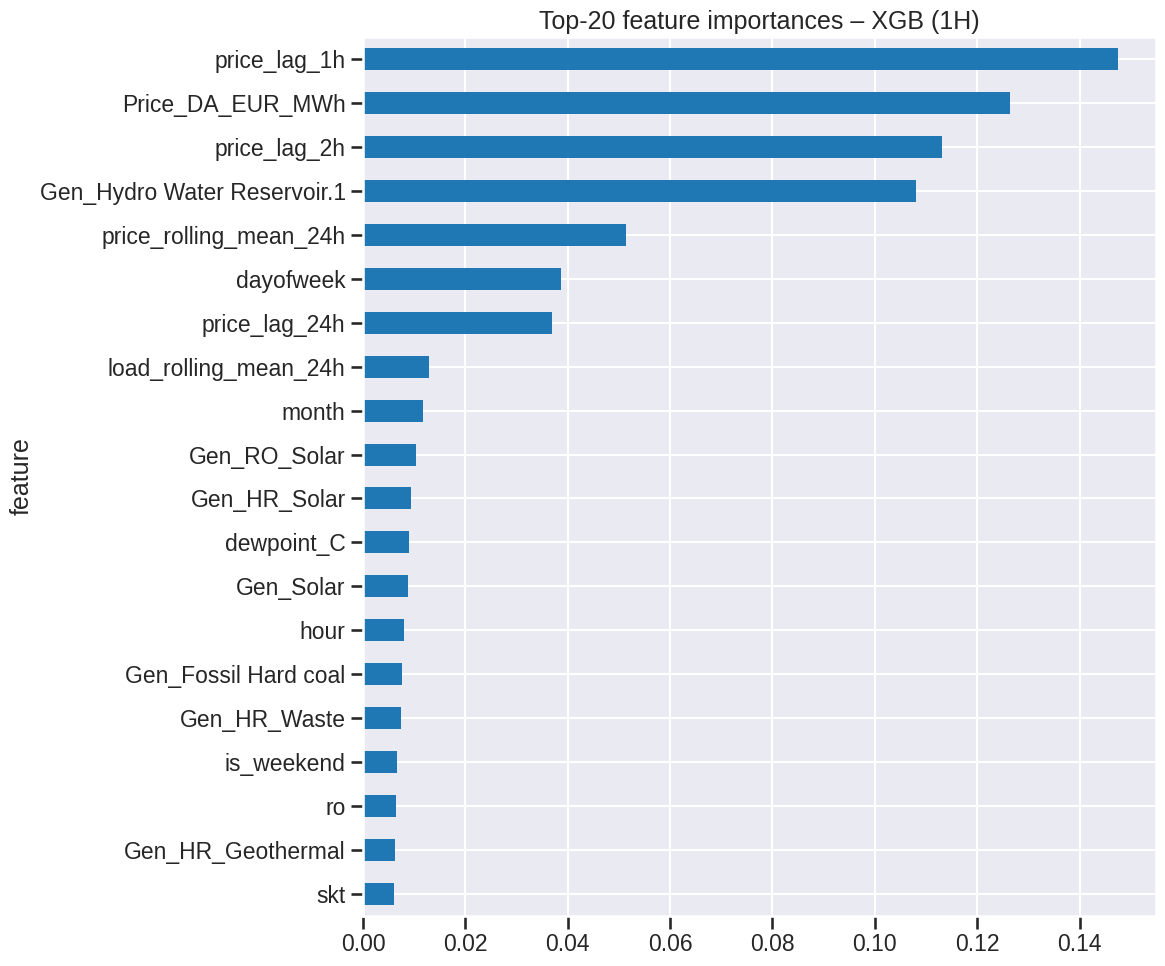

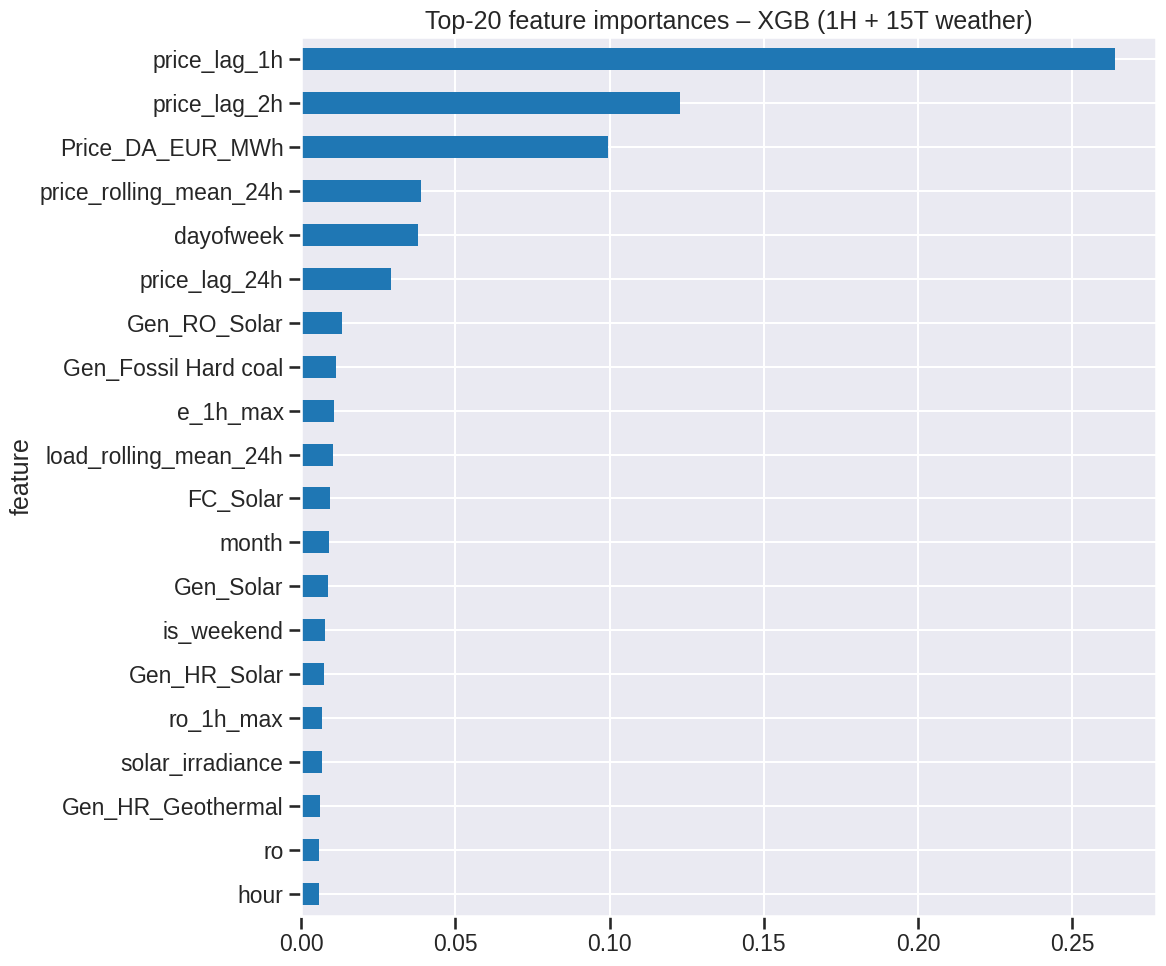


Features whose importance increases the most when adding 15T weather:


,importance_no_wx,importance_1H,importance_15T,delta_15T_minus_1H
feature,,,,
price_lag_1h,0.458994,0.147558,0.263866,0.116308
e_1h_max,0.000000,0.000000,0.010778,0.010778
price_lag_2h,0.001175,0.113218,0.122958,0.009740
ro_1h_max,0.000000,0.000000,0.006932,0.006932
FC_Solar,0.009105,0.004051,0.009322,0.005271
solar_irradiance,0.000000,0.001627,0.006873,0.005247
d2m_1h_min,0.000000,0.000000,0.004281,0.004281
u10_1h_max,0.000000,0.000000,0.004136,0.004136
Gen_Fossil Hard coal,0.004084,0.007572,0.011455,0.003883



Features whose importance decreases the most when adding 15T weather:


,importance_no_wx,importance_1H,importance_15T,delta_15T_minus_1H
feature,,,,
Gen_Hydro Water Reservoir.1,0.011235,0.108044,0.005599,-0.102445
Price_DA_EUR_MWh,0.105766,0.126466,0.099395,-0.027071
price_rolling_mean_24h,0.039014,0.051349,0.038759,-0.012590
dewpoint_C,0.000000,0.009074,0.001375,-0.007699
price_lag_24h,0.030689,0.036844,0.029197,-0.007647
Gen_HR_Waste,0.005494,0.007362,0.003573,-0.003789
Gen_HR_Other renewable,0.004691,0.005853,0.002476,-0.003377
month,0.010443,0.011812,0.009004,-0.002808
Gen_AT_Hydro Water Reservoir,0.002699,0.004480,0.001808,-0.002671


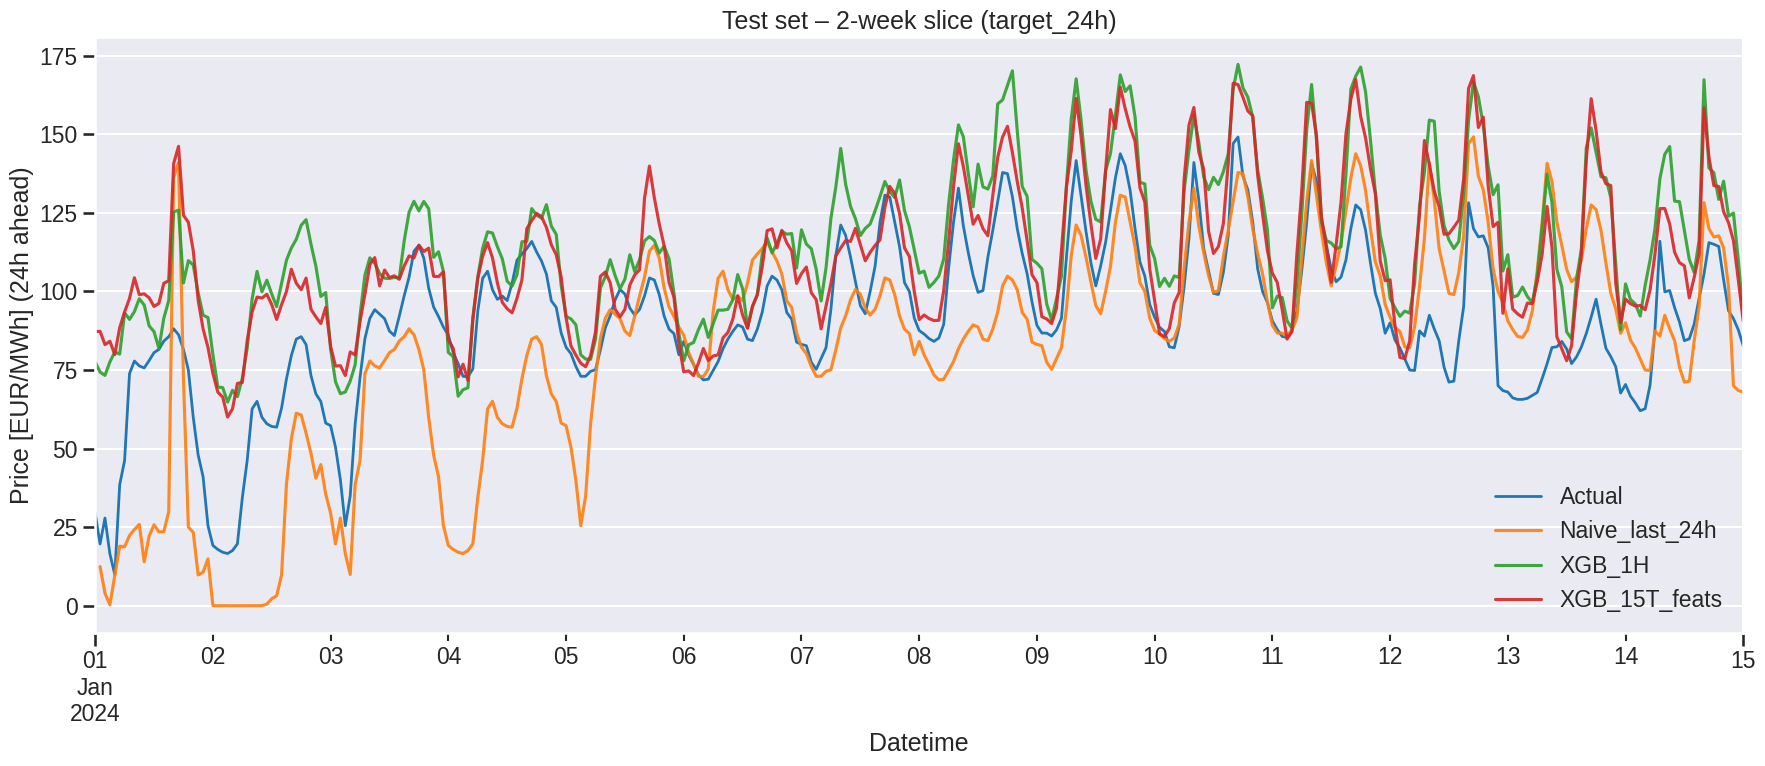

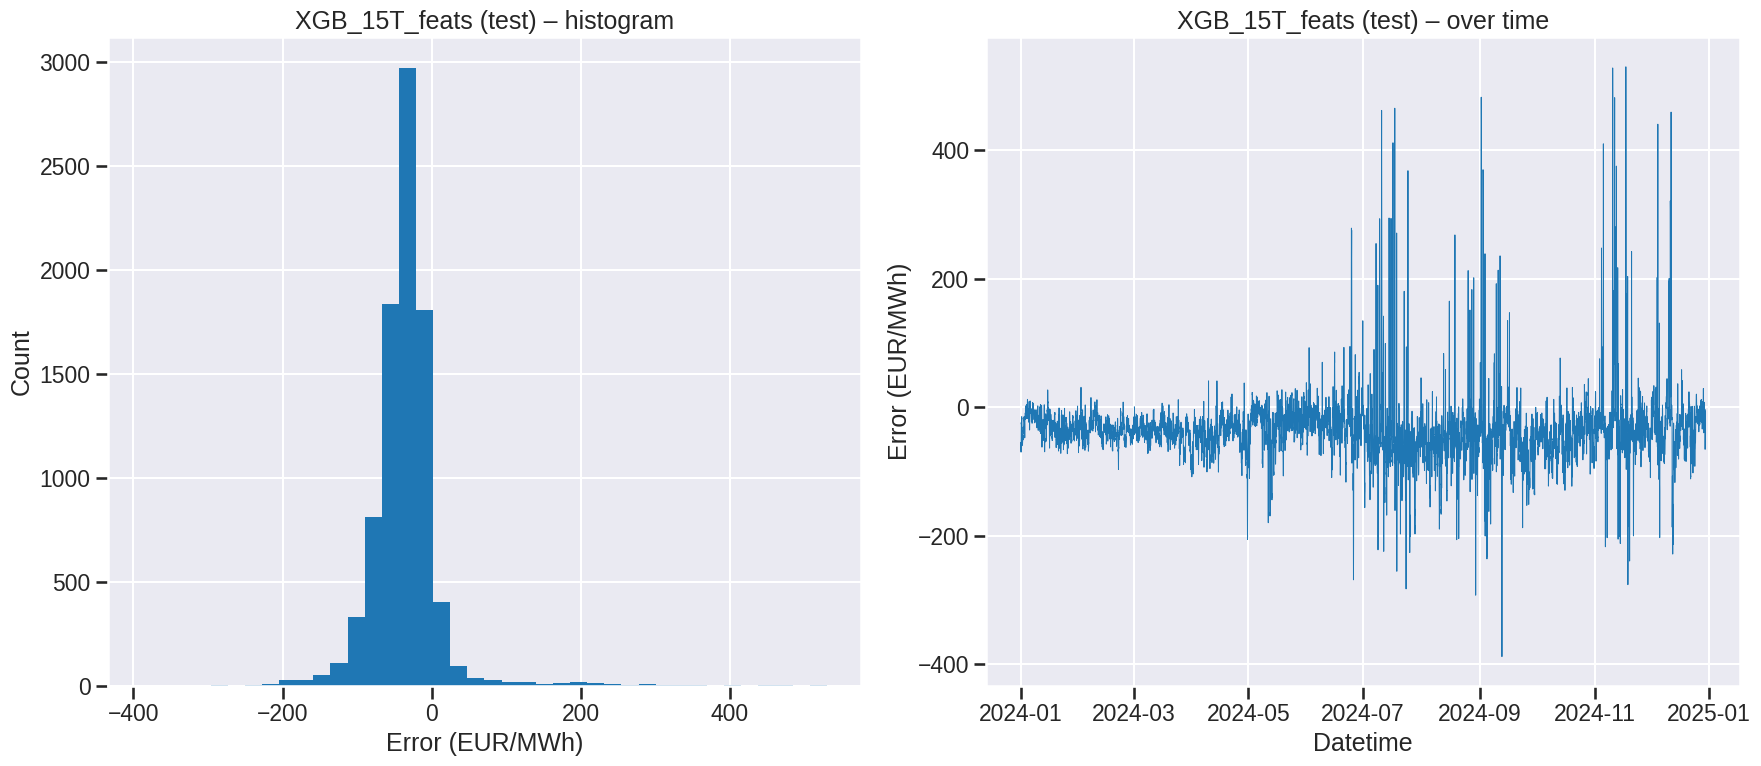

In [ ]:
# 5.5 XGB feature importance and diagnostics

if RUN_BASE_MODELS:
    def get_importance_df(model, feature_names, label):
        imp = model.feature_importances_
        df_imp = (
            pd.DataFrame({"feature": feature_names, "importance": imp})
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )
        df_imp = df_imp.set_index("feature")
        df_imp.columns = [label]
        return df_imp

    imp_no   = get_importance_df(xgb_no_wx, feat_no,   "importance_no_wx")
    imp_1Hdf = get_importance_df(xgb_1H,    feat_1H,   "importance_1H")
    imp_15Td = get_importance_df(xgb_15T,   feat_15T,  "importance_15T")

    imp_join = imp_no.join(imp_1Hdf, how="outer").join(imp_15Td, how="outer").fillna(0.0)

    top20_1H  = imp_join.sort_values("importance_1H",  ascending=False).head(20)
    top20_15T = imp_join.sort_values("importance_15T", ascending=False).head(20)

    print("Top-20 features – XGB (1H):")
    display(top20_1H)

    print("\nTop-20 features – XGB (1H + 15T):")
    display(top20_15T)

    plt.figure(figsize=(12, 10))
    top20_1H["importance_1H"].iloc[::-1].plot(kind="barh")
    plt.title("Top-20 feature importances – XGB (1H)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 10))
    top20_15T["importance_15T"].iloc[::-1].plot(kind="barh")
    plt.title("Top-20 feature importances – XGB (1H + 15T weather)")
    plt.tight_layout()
    plt.show()

    # Importance shifts
    imp_join["delta_15T_minus_1H"] = imp_join["importance_15T"] - imp_join["importance_1H"]
    increasing = imp_join.sort_values("delta_15T_minus_1H", ascending=False).head(20)
    decreasing = imp_join.sort_values("delta_15T_minus_1H").head(20)

    print("\nFeatures whose importance increases the most when adding 15T weather:")
    display(increasing)

    print("\nFeatures whose importance decreases the most when adding 15T weather:")
    display(decreasing)

    # 2-week slice diagnostics
    test_slice_start = pd.to_datetime(TEST_START_DATE)
    test_slice_end   = test_slice_start + pd.Timedelta(days=14)

    y_test_slice = y_test_15T.loc[test_slice_start:test_slice_end]

    preds_dict = {
        "Naive_last_24h": naive_pred_test.loc[y_test_slice.index] if isinstance(naive_pred_test, pd.Series) else None,
        "XGB_1H":         pd.Series(y_pred_xgb_1H_test, index=y_test_1H.index).loc[y_test_slice.index],
        "XGB_15T_feats":  pd.Series(y_pred_xgb_15T_test, index=y_test_15T.index).loc[y_test_slice.index],
    }

    plot_actual_vs_pred(y_test_slice, preds_dict, "Test set – 2-week slice (target_24h)")

    y_test_series_15T = pd.Series(y_test_15T, index=y_test_15T.index)
    y_test_pred_series_15T = pd.Series(y_pred_xgb_15T_test, index=y_test_15T.index)
    plot_residuals(y_test_series_15T, y_test_pred_series_15T, "XGB_15T_feats (test)")
else:
    print("Baseline models not run – skipping feature importance and diagnostics.")

### 6. Classical time series baselines (StatsForecast)

 We use **StatsForecast** to fit:
 - `AutoARIMA` – quickly tuned ARIMA with automated order selection.
 - `SeasonalNaive` – uses last day's same-hour price as a simple seasonal benchmark.

 These models operate on the hourly 24h-ahead series and are evaluated on the
 same 7-day horizon as NeuralForecast for fair comparison.

In [ ]:
# Cell 10 – StatsForecast classical baselines (AutoARIMA, SeasonalNaive)

if RUN_STATSFORECAST:
    # Use full train+val window for SF, drop any NaNs
    y_train_val = pd.concat([y_train_1H, y_val_1H]).sort_index().dropna()
    y_test_sf   = y_test_1H.sort_index().dropna()

    print("StatsForecast train horizon:", y_train_val.index.min(), "→", y_train_val.index.max(), "n:", len(y_train_val))

    sf_panel = pd.DataFrame({
        "unique_id": "HU_DA_target24h",
        "ds": y_train_val.index,
        "y": y_train_val.values.astype("float32"),
    })

    sf_models = [
        AutoARIMA(
            season_length=24,
            alias="SF_AutoARIMA",
            stepwise=True,
            approximation=True,
            max_p=3, max_q=3,
            max_P=1, max_Q=1,
            max_order=5,
        ),
        SeasonalNaive(season_length=24, alias="SF_SeasonalNaive"),
    ]

    sf = StatsForecast(
        models=sf_models,
        freq="H",
        n_jobs=1,
    )

    # Classic API: fit + forecast
    sf.fit(sf_panel)

    # Forecast only the 7-day horizon, to match NF and main comparison
    # Newer StatsForecast versions require passing the df explicitly
    sf_fcst = sf.forecast(df=sf_panel, h=SF_HORIZON_FOR_COMPARISON)

    test_7d_start = pd.to_datetime(TEST_START_DATE)
    test_7d_end   = test_7d_start + pd.Timedelta(hours=SF_HORIZON_FOR_COMPARISON - 1)
    y_test_7d_sf  = y_test_sf.loc[test_7d_start:test_7d_end].dropna()

    sf_fcst = sf_fcst[sf_fcst["unique_id"] == "HU_DA_target24h"].set_index("ds")
    sf_fcst_7d = sf_fcst.loc[y_test_7d_sf.index]

    if "SF_AutoARIMA" in sf_fcst_7d.columns:
        y_pred_autoarima_7d = sf_fcst_7d["SF_AutoARIMA"]
        autoarima_metrics_7d = evaluate_forecast(y_test_7d_sf, y_pred_autoarima_7d)
        results_rows.append({
            "model": "SF_AutoARIMA_7d",
            "subset": "test_7d",
            **autoarima_metrics_7d,
        })

    if "SF_SeasonalNaive" in sf_fcst_7d.columns:
        y_pred_snaive_7d = sf_fcst_7d["SF_SeasonalNaive"]
        snaive_metrics_7d = evaluate_forecast(y_test_7d_sf, y_pred_snaive_7d)
        results_rows.append({
            "model": "SF_SeasonalNaive_7d",
            "subset": "test_7d",
            **snaive_metrics_7d,
        })

    print("StatsForecast models evaluated on 7-day comparison horizon.")
else:
    print("RUN_STATSFORECAST is False – skipping StatsForecast models.")


StatsForecast train horizon: 2022-01-01 00:00:00 → 2023-12-31 23:00:00 n: 17516


StatsForecast models evaluated on 7-day comparison horizon.


### 7. NeuralForecast models – hourly and 15T, with tuning

 We now move to **NeuralForecast** models:
 - `NBEATSx` and `TiDE` on the hourly feature set (`df_1H`).
 - The same models using a curated set of 15T-enhanced features.
 - A small, resource-aware **hyperparameter grid search** for the 15T models.


In [ ]:
# 7.1 NeuralForecast (NBEATSx, TiDE) on 1H features – 7-day horizon

if RUN_NEURALFORECAST:
    # Train+val panel for NF (1H)
    df_trainval_1H_nf = pd.concat([X_train_1H, X_val_1H], axis=0).sort_index()
    y_trainval_1H_nf  = pd.concat([y_train_1H, y_val_1H]).sort_index()

    df_trainval_1H_nf = df_trainval_1H_nf.copy()
    df_trainval_1H_nf["y"] = y_trainval_1H_nf
    df_trainval_1H_nf["unique_id"] = "HU_DA_target24h"
    df_trainval_1H_nf = (
        df_trainval_1H_nf
        .reset_index()
        .rename(columns={df_trainval_1H_nf.index.name: "ds"})
    )

    # All non-target columns are historical exogenous features
    hist_exog_1H = [c for c in df_trainval_1H_nf.columns if c not in ["unique_id", "ds", "y"]]

    # Handle missing values in exogenous features for NeuralForecast
    n_nans_before = df_trainval_1H_nf[hist_exog_1H].isna().sum().sum()
    if n_nans_before > 0:
        print(f"Filling {n_nans_before} NaNs in NeuralForecast exogenous features (1H)...")
        df_trainval_1H_nf[hist_exog_1H] = (
            df_trainval_1H_nf[hist_exog_1H]
            .ffill()
            .bfill()
        )
    n_nans_after = df_trainval_1H_nf[hist_exog_1H].isna().sum().sum()
    if n_nans_after > 0:
        print(f"WARNING: still {n_nans_after} NaNs present in exogenous features after fill.")

    print(
        "NeuralForecast (1H) train+val window:",
        df_trainval_1H_nf["ds"].min(),
        "→",
        df_trainval_1H_nf["ds"].max(),
        "n:",
        len(df_trainval_1H_nf),
    )

    nbeatsx_1H = NBEATSx(
        h=NF_HORIZON_7D,                # 7-day ahead horizon (in hours)
        input_size=24 * 7 * 2,          # 2 weeks lookback
        hist_exog_list=hist_exog_1H,
        max_steps=150,
        val_check_steps=50,
        early_stop_patience_steps=5,
        batch_size=32,
        random_seed=RANDOM_SEED,
        alias="NF_NBEATSx_1H_7d",
    )

    tide_1H = TiDE(
        h=NF_HORIZON_7D,
        input_size=24 * 7 * 2,
        hist_exog_list=hist_exog_1H,
        max_steps=150,
        val_check_steps=50,
        early_stop_patience_steps=5,
        batch_size=32,
        random_seed=RANDOM_SEED,
        alias="NF_TiDE_1H_7d",
    )

    nf_1H = NeuralForecast(
        models=[nbeatsx_1H, tide_1H],
        freq="H",
    )

    # Provide val_size because early stopping is enabled
    nf_1H.fit(df=df_trainval_1H_nf, val_size=NF_HORIZON_7D)

    # Forecast first 7 days of the external test horizon (2024-01-01..2024-01-07)
    fcst_1H = nf_1H.predict(h=NF_HORIZON_7D)
    fcst_1H = fcst_1H[fcst_1H["unique_id"] == "HU_DA_target24h"].set_index("ds")

    test_7d_start = pd.to_datetime(TEST_START_DATE)
    test_7d_end   = test_7d_start + pd.Timedelta(hours=NF_HORIZON_7D - 1)
    y_test_7d     = y_test_1H.loc[test_7d_start:test_7d_end]

    fcst_1H_7d = fcst_1H.loc[y_test_7d.index]

    y_pred_nbeatsx_1H_7d = fcst_1H_7d["NF_NBEATSx_1H_7d"]
    y_pred_tide_1H_7d    = fcst_1H_7d["NF_TiDE_1H_7d"]

    metrics_nbeatsx_1H_7d = evaluate_forecast(y_test_7d, y_pred_nbeatsx_1H_7d)
    metrics_tide_1H_7d    = evaluate_forecast(y_test_7d, y_pred_tide_1H_7d)

    results_rows.append({
        "model": "NF_NBEATSx_1H_7d",
        "subset": "test_7d",
        **metrics_nbeatsx_1H_7d,
    })
    results_rows.append({
        "model": "NF_TiDE_1H_7d",
        "subset": "test_7d",
        **metrics_tide_1H_7d,
    })

    print("NeuralForecast (1H) models evaluated on first 7 days of 2024.")
else:
    print("RUN_NEURALFORECAST is False – skipping NeuralForecast(1H).")

Seed set to 42


Filling 800 NaNs in NeuralForecast exogenous features (1H)...
NeuralForecast (1H) train+val window: 2022-01-01 00:00:00 → 2023-12-31 23:00:00 n: 17516


Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
2025-12-11 07:36:04.737779: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-11 07:36:05.555011: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-11 07:36:08.135119: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the en

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

`Trainer.fit` stopped: `max_steps=150` reached.
Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

NeuralForecast (1H) models evaluated on first 7 days of 2024.


In [ ]:
# 7.2 NeuralForecast (NBEATSx, TiDE) on 15T-enhanced features – 7-day horizon

if RUN_NEURALFORECAST:
    # Train+val panel for NF (15T features)
    df_trainval_15T_nf = pd.concat([X_train_15T, X_val_15T], axis=0).sort_index()
    y_trainval_15T_nf  = pd.concat([y_train_15T, y_val_15T]).sort_index()

    df_trainval_15T_nf = df_trainval_15T_nf.copy()
    df_trainval_15T_nf["y"] = y_trainval_15T_nf
    df_trainval_15T_nf["unique_id"] = "HU_DA_target24h"
    df_trainval_15T_nf = (
        df_trainval_15T_nf
        .reset_index()
        .rename(columns={df_trainval_15T_nf.index.name: "ds"})
    )

    all_hist_exog_15T = [
        c for c in df_trainval_15T_nf.columns
        if c not in ["unique_id", "ds", "y"]
    ]

    # Curated exogenous set for NF 15T models
    core_exog_candidates_15T = [
        # price / load & engineered price features
        "Price_DA_EUR_MWh",
        "Load_Actual_MW",
        "Load_Forecast_MW",
        "Net_Position_DA_MW",
        "price_lag_1h",
        "price_lag_2h",
        "price_lag_24h",
        "price_rolling_mean_24h",
        "load_rolling_mean_24h",
        "load_rolling_std_24h",
        "price_diff_1h",

        # Hungarian generation mix – focus on solar / RES / key thermal
        "Gen_Solar",
        "Gen_Wind Onshore",
        "Gen_Nuclear",

        # Cross-border / flows
        "Flow_net_per_load",
        "Flow_net_sum",

        # Weather & proxies
        "solar_irradiance",
        "wind_speed_10m",
        "wind_speed_100m",
        "temp_C",
        "dewpoint_C",
        "temp_dewpoint_spread",
        "tcwv",
        "tp",
        "ssr",
        "ssrd",
        "str",
        "strd",

        # Calendar & daylight
        "hour",
        "dayofweek",
        "month",
        "is_weekend",
        "is_daylight",
    ]

    hist_exog_15T = [c for c in core_exog_candidates_15T if c in all_hist_exog_15T]

    print(
        f"NeuralForecast (15T): using {len(hist_exog_15T)} exogenous features "
        f"(out of {len(all_hist_exog_15T)} available)."
    )

    # Handle missing values in exogenous features for NeuralForecast
    n_nans_before_15T = df_trainval_15T_nf[hist_exog_15T].isna().sum().sum()
    if n_nans_before_15T > 0:
        print(f"Filling {n_nans_before_15T} NaNs in NeuralForecast exogenous features (15T)...")
        df_trainval_15T_nf[hist_exog_15T] = (
            df_trainval_15T_nf[hist_exog_15T]
            .ffill()
            .bfill()
        )
    n_nans_after_15T = df_trainval_15T_nf[hist_exog_15T].isna().sum().sum()
    if n_nans_after_15T > 0:
        print(f"WARNING: still {n_nans_after_15T} NaNs present in 15T exogenous features after fill.")

    print(
        "NeuralForecast (15T) train+val window:",
        df_trainval_15T_nf["ds"].min(),
        "→",
        df_trainval_15T_nf["ds"].max(),
        "n:",
        len(df_trainval_15T_nf),
    )

    # Keep only columns actually used by NF
    cols_nf_15T = ["unique_id", "ds", "y"] + hist_exog_15T
    df_trainval_15T_nf = df_trainval_15T_nf[cols_nf_15T].copy()

    remaining_nans = df_trainval_15T_nf.isna().sum().sum()
    if remaining_nans > 0:
        print(f"WARNING: {remaining_nans} NaNs still present in df_trainval_15T_nf after column reduction.")

    NF_15T_FINAL_CONFIG = {
        "input_size": 168,
        "max_steps": 200,
        "batch_size": 32,
    }
    print("Using NF_15T_FINAL_CONFIG:", NF_15T_FINAL_CONFIG)

    nbeatsx_15T = NBEATSx(
        h=NF_HORIZON_7D,
        input_size=NF_15T_FINAL_CONFIG["input_size"],
        hist_exog_list=hist_exog_15T,
        max_steps=NF_15T_FINAL_CONFIG["max_steps"],
        val_check_steps=50,
        early_stop_patience_steps=5,
        batch_size=NF_15T_FINAL_CONFIG["batch_size"],
        random_seed=RANDOM_SEED,
        alias="NF_NBEATSx_15T_7d",
    )

    tide_15T = TiDE(
        h=NF_HORIZON_7D,
        input_size=NF_15T_FINAL_CONFIG["input_size"],
        hist_exog_list=hist_exog_15T,
        max_steps=NF_15T_FINAL_CONFIG["max_steps"],
        val_check_steps=50,
        early_stop_patience_steps=5,
        batch_size=NF_15T_FINAL_CONFIG["batch_size"],
        random_seed=RANDOM_SEED,
        alias="NF_TiDE_15T_7d",
    )

    nf_15T = NeuralForecast(
        models=[nbeatsx_15T, tide_15T],
        freq="H",
    )

    nf_15T.fit(df=df_trainval_15T_nf, val_size=NF_HORIZON_7D)

    # Forecast first 7 days of the external test horizon (2024-01-01..2024-01-07)
    fcst_15T = nf_15T.predict(h=NF_HORIZON_7D)
    fcst_15T = fcst_15T[fcst_15T["unique_id"] == "HU_DA_target24h"].set_index("ds")

    test_7d_start = pd.to_datetime(TEST_START_DATE)
    test_7d_end   = test_7d_start + pd.Timedelta(hours=NF_HORIZON_7D - 1)
    y_test_7d_15T = y_test_15T.loc[test_7d_start:test_7d_end]

    fcst_15T_7d = fcst_15T.loc[y_test_7d_15T.index]

    y_pred_nbeatsx_15T_7d = fcst_15T_7d["NF_NBEATSx_15T_7d"]
    y_pred_tide_15T_7d    = fcst_15T_7d["NF_TiDE_15T_7d"]

    metrics_nbeatsx_15T_7d = evaluate_forecast(y_test_7d_15T, y_pred_nbeatsx_15T_7d)
    metrics_tide_15T_7d    = evaluate_forecast(y_test_7d_15T, y_pred_tide_15T_7d)

    results_rows.append({
        "model": "NF_NBEATSx_15T_7d",
        "subset": "test_7d",
        **metrics_nbeatsx_15T_7d,
    })
    results_rows.append({
        "model": "NF_TiDE_15T_7d",
        "subset": "test_7d",
        **metrics_tide_15T_7d,
    })

    print("NeuralForecast (15T) models evaluated on first 7 days of 2024 (final config).")
else:
    print("RUN_NEURALFORECAST is False – skipping NeuralForecast(15T).")

Seed set to 42
Seed set to 42


NeuralForecast (15T): using 33 exogenous features (out of 221 available).
Filling 352 NaNs in NeuralForecast exogenous features (15T)...
NeuralForecast (15T) train+val window: 2022-01-01 00:00:00 → 2023-12-31 23:00:00 n: 17516
Using NF_15T_FINAL_CONFIG: {'input_size': 168, 'max_steps': 200, 'batch_size': 32}


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 11.8 M | train
-------------------------------------------------------
11.7 M    Trainable params
113 K     Non-trainable params
11.8 M    Total params
47.082    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

`Trainer.fit` stopped: `max_steps=200` reached.
Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

NeuralForecast (15T) models evaluated on first 7 days of 2024 (final config).


In [ ]:
# 7.3 Hyperparameter tuning for NeuralForecast (NBEATSx, TiDE) on 15T – small grid

if RUN_NEURALFORECAST:
    print("=== Hyperparameter tuning for NeuralForecast 15T models (NBEATSx, TiDE) ===")

    df_trainval_15T_nf = pd.concat([X_train_15T, X_val_15T], axis=0).sort_index()
    y_trainval_15T_nf  = pd.concat([y_train_15T, y_val_15T]).sort_index()

    df_trainval_15T_nf = df_trainval_15T_nf.copy()
    df_trainval_15T_nf["y"] = y_trainval_15T_nf
    df_trainval_15T_nf["unique_id"] = "HU_DA_target24h"
    df_trainval_15T_nf = (
        df_trainval_15T_nf
        .reset_index()
        .rename(columns={df_trainval_15T_nf.index.name: "ds"})
    )

    all_hist_exog_15T = [
        c for c in df_trainval_15T_nf.columns
        if c not in ["unique_id", "ds", "y"]
    ]

    core_exog_candidates_15T = [
        "Price_DA_EUR_MWh",
        "Load_Actual_MW",
        "Load_Forecast_MW",
        "Net_Position_DA_MW",
        "price_lag_1h",
        "price_lag_2h",
        "price_lag_24h",
        "price_rolling_mean_24h",
        "load_rolling_mean_24h",
        "load_rolling_std_24h",
        "price_diff_1h",
        "Gen_Solar",
        "Gen_Wind Onshore",
        "Gen_Nuclear",
        "Flow_net_per_load",
        "Flow_net_sum",
        "solar_irradiance",
        "wind_speed_10m",
        "wind_speed_100m",
        "temp_C",
        "dewpoint_C",
        "temp_dewpoint_spread",
        "tcwv",
        "tp",
        "ssr",
        "ssrd",
        "str",
        "strd",
        "hour",
        "dayofweek",
        "month",
        "is_weekend",
        "is_daylight",
    ]

    hist_exog_15T = [c for c in core_exog_candidates_15T if c in all_hist_exog_15T]

    print(
        f"Tuning NF (15T): using {len(hist_exog_15T)} exogenous features "
        f"(out of {len(all_hist_exog_15T)} available)."
    )

    # Handle missing values in exogenous features
    n_nans_before_15T = df_trainval_15T_nf[hist_exog_15T].isna().sum().sum()
    if n_nans_before_15T > 0:
        print(f"Filling {n_nans_before_15T} NaNs in NeuralForecast exogenous features (15T)...")
        df_trainval_15T_nf[hist_exog_15T] = (
            df_trainval_15T_nf[hist_exog_15T]
            .ffill()
            .bfill()
        )
    n_nans_after_15T = df_trainval_15T_nf[hist_exog_15T].isna().sum().sum()
    if n_nans_after_15T > 0:
        print(f"WARNING: still {n_nans_after_15T} NaNs present in 15T exogenous features after fill.")

    required_cols_15T = ["unique_id", "ds", "y"] + hist_exog_15T
    df_trainval_15T_nf = df_trainval_15T_nf[required_cols_15T].copy()

    # Explicit train/validation split for tuning: last H as validation
    H = NF_HORIZON_7D
    df_panel_sorted = df_trainval_15T_nf.sort_values("ds")

    if len(df_panel_sorted) <= H:
        raise ValueError("Not enough observations for NF tuning: panel shorter than horizon.")

    df_val_nf = df_panel_sorted.tail(H).copy()
    df_train_nf = df_panel_sorted.iloc[:-H].copy()

    y_val_nf = df_val_nf.set_index("ds")["y"]

    NF_CONFIG_GRID_15T = [
        {"name": "cfg_168_100_bs32", "input_size": 168, "max_steps": 100, "batch_size": 32},
        {"name": "cfg_168_200_bs32", "input_size": 168, "max_steps": 200, "batch_size": 32},
    ]

    print(f"NF tuning grid (15T): {len(NF_CONFIG_GRID_15T)} configs")
    for cfg in NF_CONFIG_GRID_15T:
        print("  ", cfg)

    def build_models_15T(input_size, max_steps, batch_size):
        nbeatsx_15T = NBEATSx(
            h=H,
            input_size=input_size,
            hist_exog_list=hist_exog_15T,
            max_steps=max_steps,
            val_check_steps=50,
            early_stop_patience_steps=5,
            batch_size=batch_size,
            random_seed=RANDOM_SEED,
            alias="NF_NBEATSx_15T_7d",
        )
        tide_15T = TiDE(
            h=H,
            input_size=input_size,
            hist_exog_list=hist_exog_15T,
            max_steps=max_steps,
            val_check_steps=50,
            early_stop_patience_steps=5,
            batch_size=batch_size,
            random_seed=RANDOM_SEED,
            alias="NF_TiDE_15T_7d",
        )
        return nbeatsx_15T, tide_15T

    rows_nbeatsx = []
    rows_tide = []
    best_rmse_nbeatsx = np.inf
    best_cfg_nbeatsx = None
    best_rmse_tide = np.inf
    best_cfg_tide = None

    for cfg in NF_CONFIG_GRID_15T:
        print(f"\nTesting NF config: {cfg}")
        nbeatsx_15T, tide_15T = build_models_15T(
            input_size=cfg["input_size"],
            max_steps=cfg["max_steps"],
            batch_size=cfg["batch_size"],
        )
        nf_tmp = NeuralForecast(models=[nbeatsx_15T, tide_15T], freq="H")

        nf_tmp.fit(df=df_train_nf, val_size=H)

        fcst_val = nf_tmp.predict(h=H)
        fcst_val = fcst_val[fcst_val["unique_id"] == "HU_DA_target24h"].set_index("ds")

        common_idx_val = fcst_val.index.intersection(y_val_nf.index)
        if len(common_idx_val) < len(y_val_nf):
            print(f"WARNING: using {len(common_idx_val)}/{len(y_val_nf)} validation timestamps for NF tuning (intersection).")

        y_val_nf_aligned = y_val_nf.loc[common_idx_val]
        fcst_val_aligned = fcst_val.loc[common_idx_val]

        y_pred_nbeatsx_val = fcst_val_aligned["NF_NBEATSx_15T_7d"]
        y_pred_tide_val    = fcst_val_aligned["NF_TiDE_15T_7d"]

        metrics_nbeatsx_val = evaluate_forecast(y_val_nf_aligned, y_pred_nbeatsx_val)
        metrics_tide_val    = evaluate_forecast(y_val_nf_aligned, y_pred_tide_val)

        rmse_nbeatsx = metrics_nbeatsx_val["rmse"]
        rmse_tide    = metrics_tide_val["rmse"]

        rows_nbeatsx.append({**cfg, **metrics_nbeatsx_val})
        rows_tide.append({**cfg, **metrics_tide_val})

        if rmse_nbeatsx < best_rmse_nbeatsx:
            best_rmse_nbeatsx = rmse_nbeatsx
            best_cfg_nbeatsx = cfg

        if rmse_tide < best_rmse_tide:
            best_rmse_tide = rmse_tide
            best_cfg_tide = cfg

    nf_nbeatsx_search = pd.DataFrame(rows_nbeatsx).sort_values("rmse").reset_index(drop=True)
    nf_tide_search    = pd.DataFrame(rows_tide).sort_values("rmse").reset_index(drop=True)

    print("\nNBEATSx search results (sorted by RMSE):")
    display(nf_nbeatsx_search)
    print("\nTiDE search results (sorted by RMSE):")
    display(nf_tide_search)

    print("Best NF NBEATSx config:", best_cfg_nbeatsx, f"RMSE_val={best_rmse_nbeatsx:.3f}")
    print("Best NF TiDE config:",    best_cfg_tide,   f"RMSE_val={best_rmse_tide:.3f}")

    BEST_NF_CONFIG_15T = {
        "input_size": best_cfg_tide["input_size"],
        "max_steps":  best_cfg_tide["max_steps"],
        "batch_size": best_cfg_tide["batch_size"],
    }
    print("BEST_NF_CONFIG_15T (based on TiDE):", BEST_NF_CONFIG_15T)

    # Train final tuned NF models on full train+val panel, evaluate on test 7-day horizon
    nbeatsx_best_15T, _ = build_models_15T(
        input_size=best_cfg_nbeatsx["input_size"],
        max_steps=best_cfg_nbeatsx["max_steps"],
        batch_size=best_cfg_nbeatsx["batch_size"],
    )
    _, tide_best_15T = build_models_15T(
        input_size=best_cfg_tide["input_size"],
        max_steps=best_cfg_tide["max_steps"],
        batch_size=best_cfg_tide["batch_size"],
    )

    nf_15T_tuned = NeuralForecast(
        models=[nbeatsx_best_15T, tide_best_15T],
        freq="H",
    )

    nf_15T_tuned.fit(df=df_trainval_15T_nf, val_size=NF_HORIZON_7D)

    fcst_15T_test = nf_15T_tuned.predict(h=NF_HORIZON_7D)
    fcst_15T_test = fcst_15T_test[fcst_15T_test["unique_id"] == "HU_DA_target24h"].set_index("ds")

    test_7d_start = pd.to_datetime(TEST_START_DATE)
    test_7d_end   = test_7d_start + pd.Timedelta(hours=NF_HORIZON_7D - 1)
    y_test_7d_15T = y_test_15T.loc[test_7d_start:test_7d_end]

    common_idx_test = fcst_15T_test.index.intersection(y_test_7d_15T.index)
    if len(common_idx_test) < len(y_test_7d_15T):
        print(f"WARNING: using {len(common_idx_test)}/{len(y_test_7d_15T)} test timestamps for tuned NF 15T (intersection).")

    y_test_7d_15T_aligned = y_test_7d_15T.loc[common_idx_test]
    fcst_15T_7d_tuned = fcst_15T_test.loc[common_idx_test]

    y_pred_nbeatsx_15T_7d_tuned = fcst_15T_7d_tuned["NF_NBEATSx_15T_7d"]
    y_pred_tide_15T_7d_tuned    = fcst_15T_7d_tuned["NF_TiDE_15T_7d"]

    metrics_nbeatsx_15T_7d_tuned = evaluate_forecast(y_test_7d_15T_aligned, y_pred_nbeatsx_15T_7d_tuned)
    metrics_tide_15T_7d_tuned    = evaluate_forecast(y_test_7d_15T_aligned, y_pred_tide_15T_7d_tuned)

    results_rows.append({
        "model": "NF_NBEATSx_15T_7d_tuned",
        "subset": "test_7d",
        **metrics_nbeatsx_15T_7d_tuned,
    })
    results_rows.append({
        "model": "NF_TiDE_15T_7d_tuned",
        "subset": "test_7d",
        **metrics_tide_15T_7d_tuned,
    })

    print("NeuralForecast (15T) tuned models evaluated on first 7 days of 2024.")
else:
    print("RUN_NEURALFORECAST is False – skipping NeuralForecast(15T) tuning.")

Seed set to 42
Seed set to 42


=== Hyperparameter tuning for NeuralForecast 15T models (NBEATSx, TiDE) ===
Tuning NF (15T): using 33 exogenous features (out of 221 available).
Filling 352 NaNs in NeuralForecast exogenous features (15T)...
NF tuning grid (15T): 2 configs
   {'name': 'cfg_168_100_bs32', 'input_size': 168, 'max_steps': 100, 'batch_size': 32}
   {'name': 'cfg_168_200_bs32', 'input_size': 168, 'max_steps': 200, 'batch_size': 32}

Testing NF config: {'name': 'cfg_168_100_bs32', 'input_size': 168, 'max_steps': 100, 'batch_size': 32}


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 11.8 M | train
-------------------------------------------------------
11.7 M    Trainable params
113 K     Non-trainable params
11.8 M    Total params
47.082    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

`Trainer.fit` stopped: `max_steps=200` reached.
Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

NeuralForecast (15T) tuned models evaluated on first 7 days of 2024.


### 8. Consolidated model comparison (leaderboard)

 We gather all model metrics into a single `results_df` table and sort by RMSE:
 - `subset = "test"`   → full 2024 test horizon (baseline / XGB emphasis).
 - `subset = "test_7d"` → 7-day common horizon (Naive, SF, XGB, NF).

In [ ]:
# Cell 13 – consolidated model comparison

results_df = pd.DataFrame(results_rows)
results_df["horizon"] = results_df["subset"].map(
    lambda s: "7d" if "7d" in s else "full_test"
)
results_df = results_df.sort_values(by=["horizon", "rmse"]).reset_index(drop=True)
results_df

,model,subset,rmse,mae,smape,n,horizon
0,NF_NBEATSx_15T_7d,test_7d,40.976857,36.298022,54.075396,168,7d
1,NF_NBEATSx_15T_7d_tuned,test_7d,40.976857,36.298022,54.075396,168,7d
2,NF_NBEATSx_1H_7d,test_7d,48.064644,42.572745,44.496376,168,7d
3,NF_TiDE_1H_7d,test_7d,52.933048,46.356154,86.376890,168,7d
4,NF_TiDE_15T_7d,test_7d,57.582158,51.468060,96.775283,168,7d
5,NF_TiDE_15T_7d_tuned,test_7d,57.582158,51.468060,96.775283,168,7d
6,SF_AutoARIMA_7d,test_7d,62.651532,57.092624,119.879177,168,7d
7,SF_SeasonalNaive_7d,test_7d,67.670082,62.389226,145.263281,168,7d
8,XGB_15T_tuned,test,58.261191,39.167284,41.767125,8735,full_test
9,XGB_1H_tuned,test,58.367387,40.244222,42.805205,8735,full_test


### 9. Visual diagnostics and slice-wise evaluation

 We visualise:
 - 9.1 Full 2024 path vs main models.
 - 9.2 7-day Neural horizon zoom (first week of 2024).
 - 9.3 Daily 24h comparison panels for the first week.
 - 9.4 Slice-wise metrics (RMSE by hour, month, weekday/weekend).
 - 9.5 Interactive Plotly comparison (last 30 days of test).


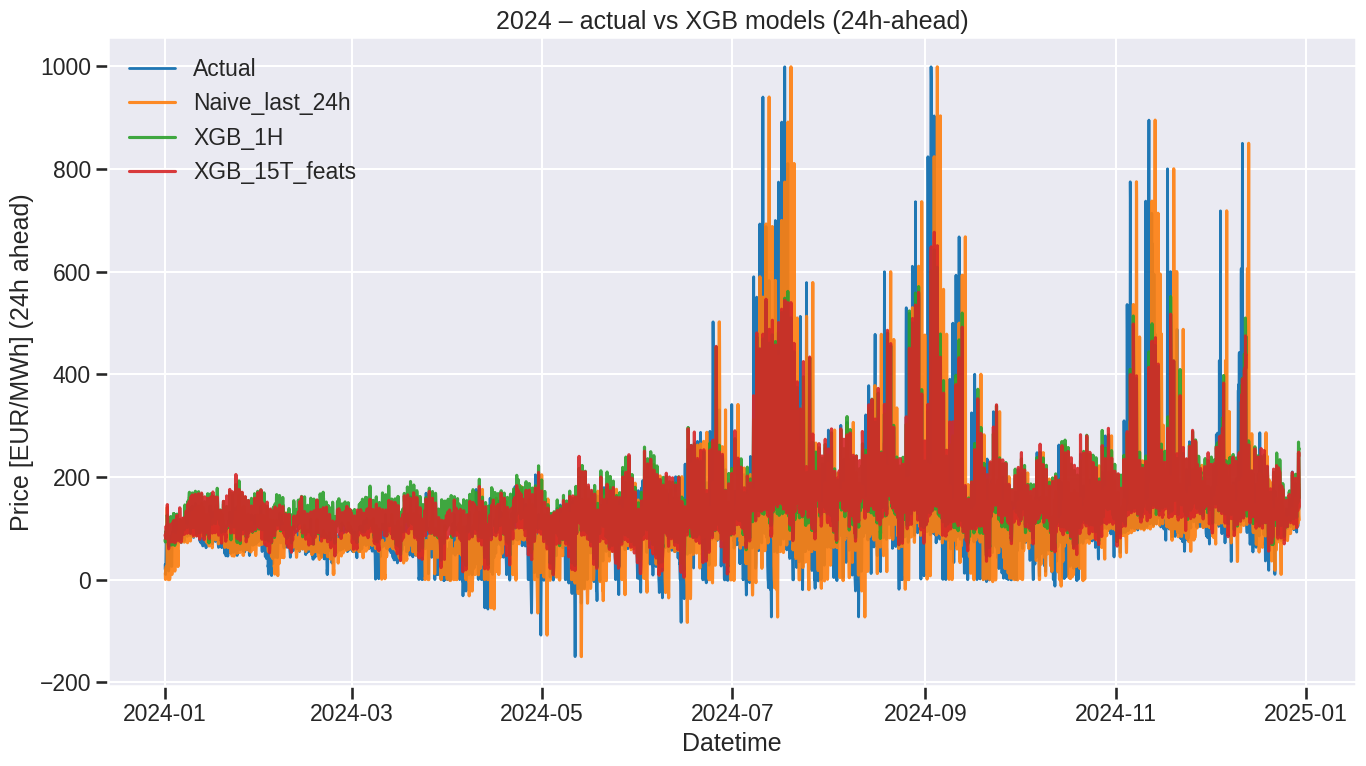

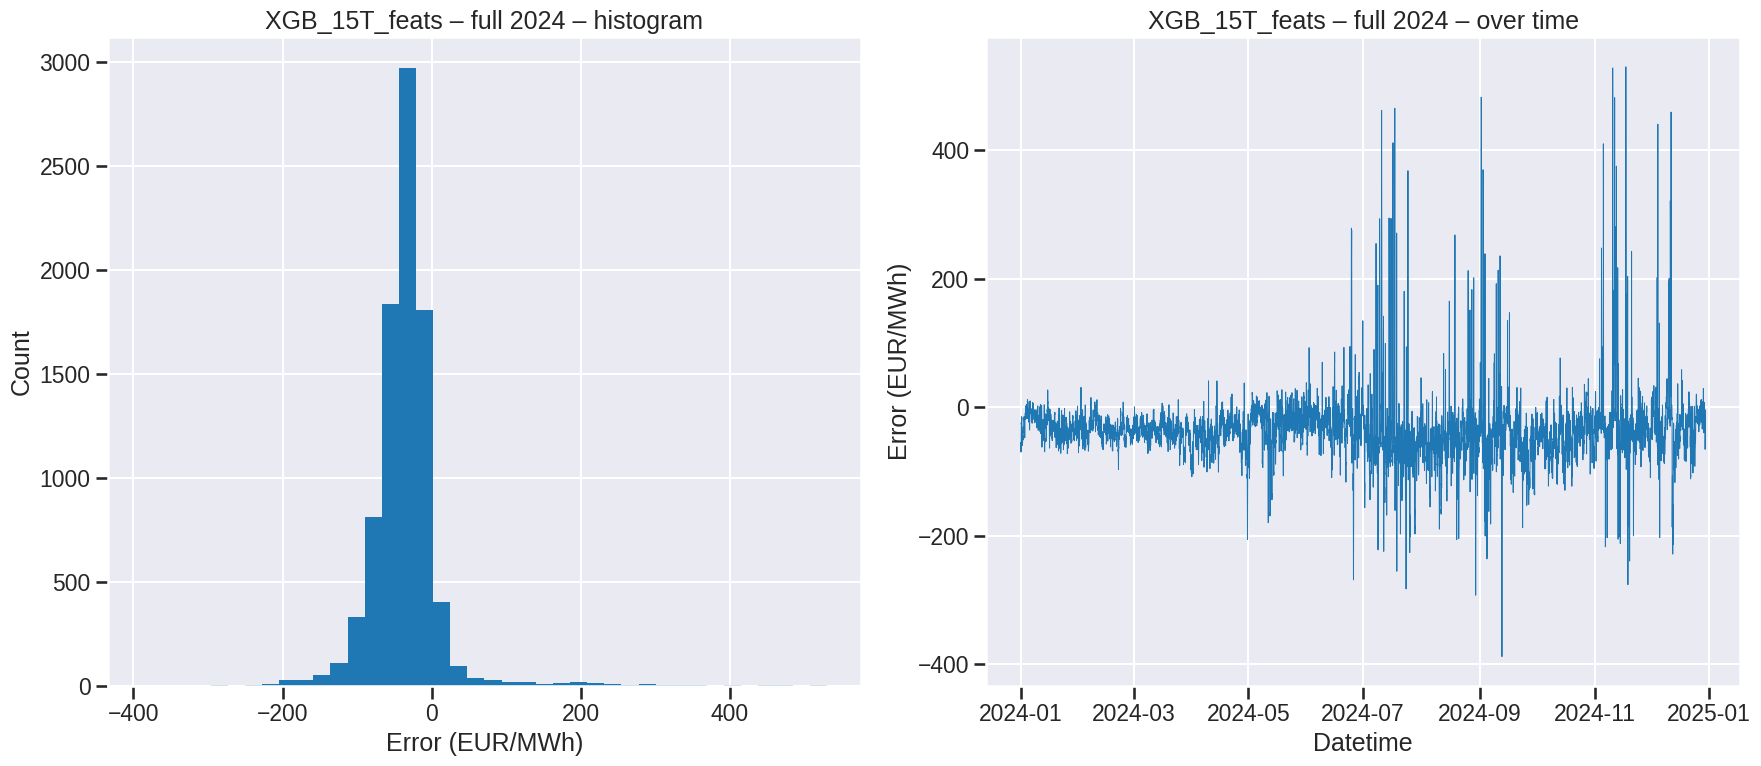

In [ ]:
# 9.1 Full 2024 actual vs main models & residuals

if RUN_BASE_MODELS:
    y_test_series = y_test_1H.copy()

    pred_series = {
        "Naive_last_24h": naive_pred_test.astype(float) if isinstance(naive_pred_test, pd.Series) else None,
        "XGB_1H":         pd.Series(y_pred_xgb_1H_test, index=y_test_1H.index),
        "XGB_15T_feats":  pd.Series(y_pred_xgb_15T_test, index=y_test_15T.index),
    }

    plot_actual_vs_forecast(
        y_true=y_test_series,
        y_pred_dict=pred_series,
        title="2024 – actual vs XGB models (24h-ahead)",
        figsize=(14, 8),
    )

    # Residuals for XGB_15T_feats on full test
    plot_residuals(
        y_true=y_test_series,
        y_pred=pd.Series(y_pred_xgb_15T_test, index=y_test_1H.index),
        title_prefix="XGB_15T_feats – full 2024"
    )
else:
    print("Baseline models not run – skipping full-year diagnostics.")

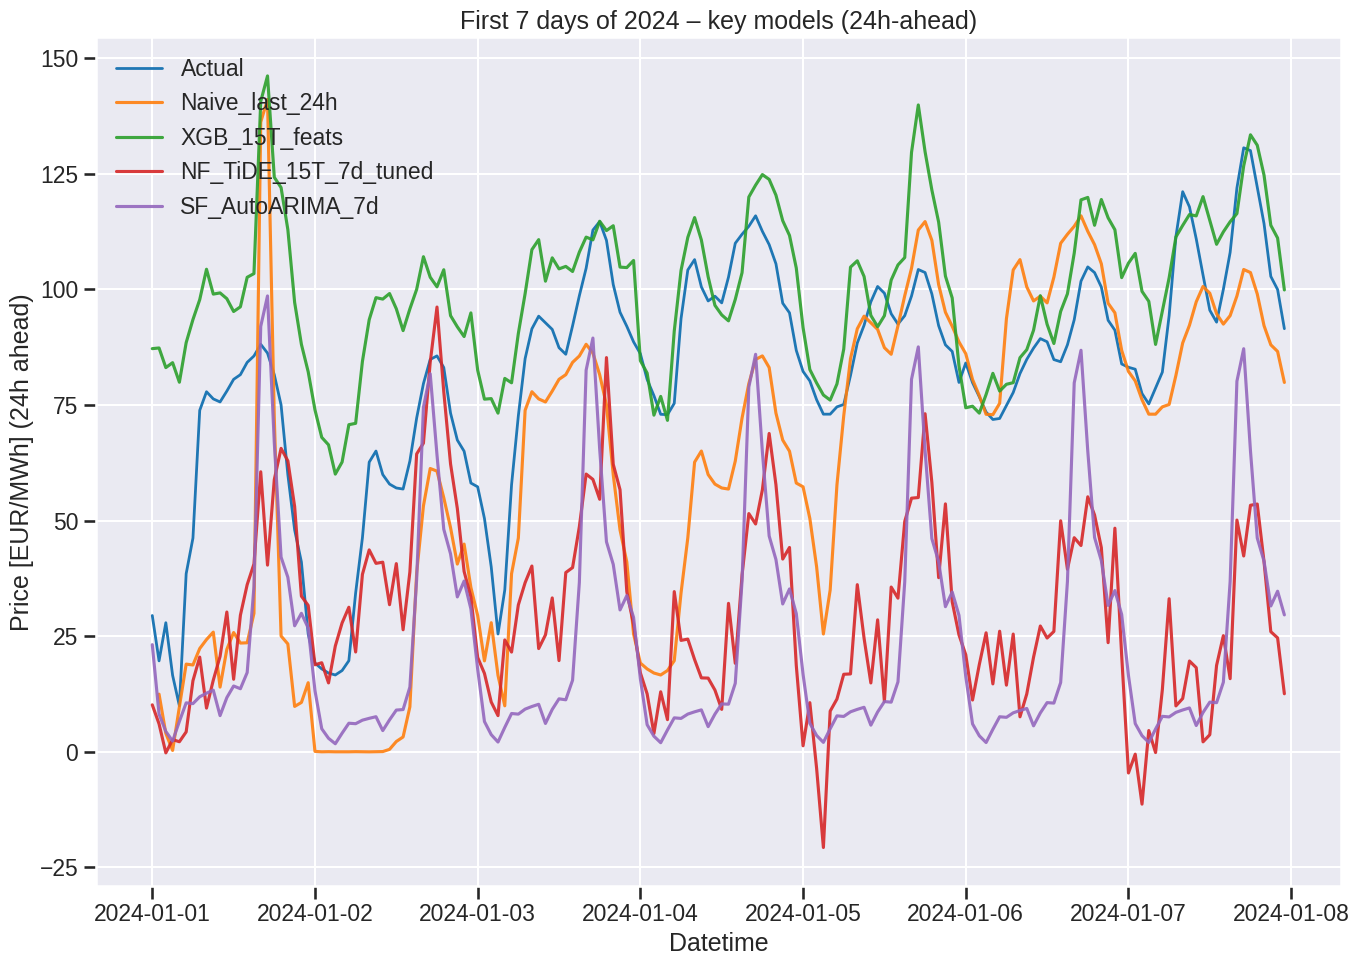

In [ ]:
# 9.2 7-day neural horizon zoom-in (first 7 days of 2024) – key models only

if RUN_NEURALFORECAST and RUN_BASE_MODELS:
    test_7d_start = pd.to_datetime(TEST_START_DATE)
    test_7d_end   = test_7d_start + pd.Timedelta(hours=NF_HORIZON_7D - 1)
    y_7d_series = y_test_1H.loc[test_7d_start:test_7d_end]

    pred_7d = {}

    if isinstance(naive_pred_test, pd.Series):
        pred_7d["Naive_last_24h"] = naive_pred_test.loc[y_7d_series.index].astype(float)

    pred_7d["XGB_15T_feats"] = pd.Series(y_pred_xgb_15T_test, index=y_test_1H.index).loc[y_7d_series.index]

    if "y_pred_tide_15T_7d_tuned" in globals():
        pred_7d["NF_TiDE_15T_7d_tuned"] = y_pred_tide_15T_7d_tuned.astype(float)
    elif "y_pred_tide_15T_7d" in globals():
        pred_7d["NF_TiDE_15T_7d"] = y_pred_tide_15T_7d.astype(float)

    if "y_pred_autoarima_7d" in globals():
        pred_7d["SF_AutoARIMA_7d"] = y_pred_autoarima_7d.astype(float)

    plot_actual_vs_forecast(
        y_true=y_7d_series,
        y_pred_dict=pred_7d,
        title="First 7 days of 2024 – key models (24h-ahead)",
        figsize=(14, 10),
    )

else:
    print("NeuralForecast or baseline models not run – skipping 7-day horizon diagnostics.")

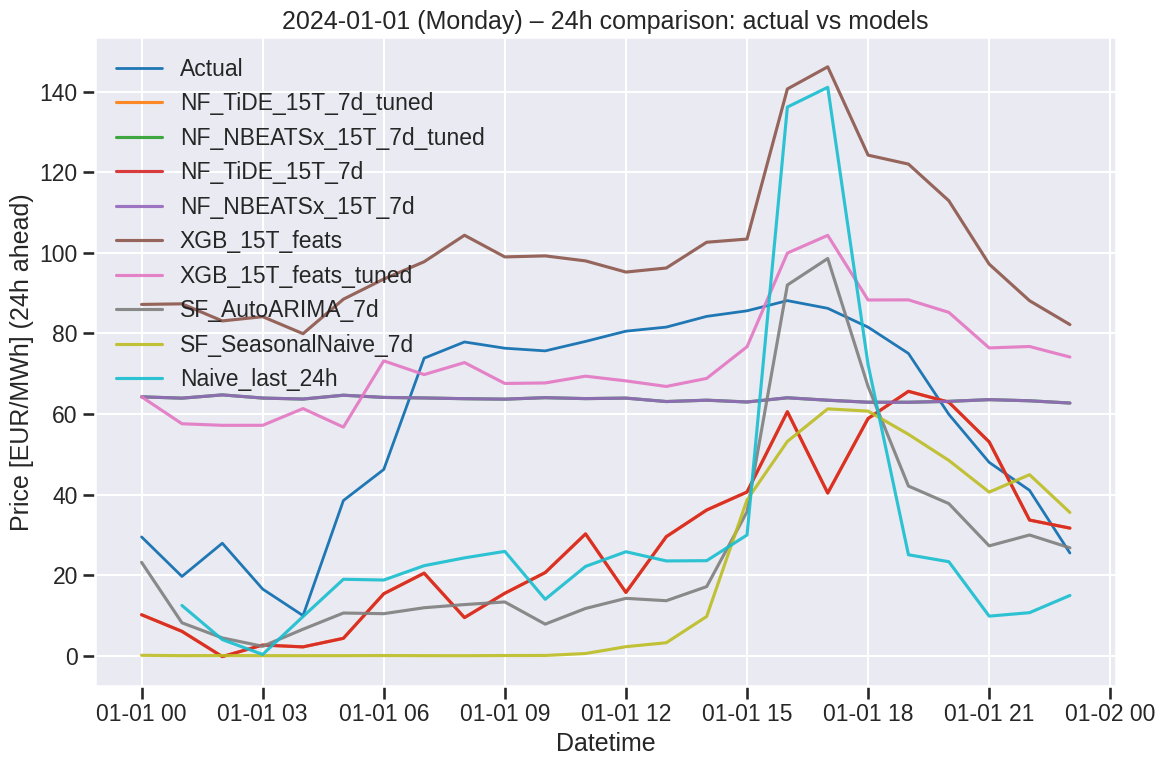

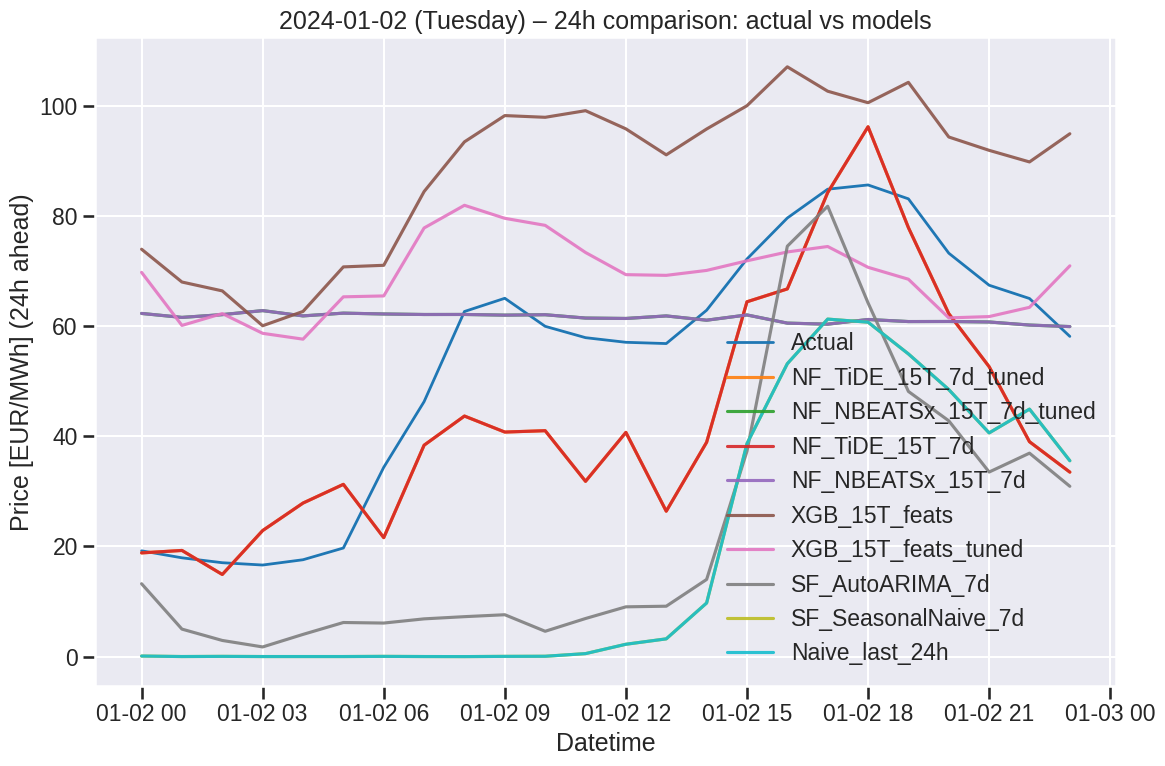

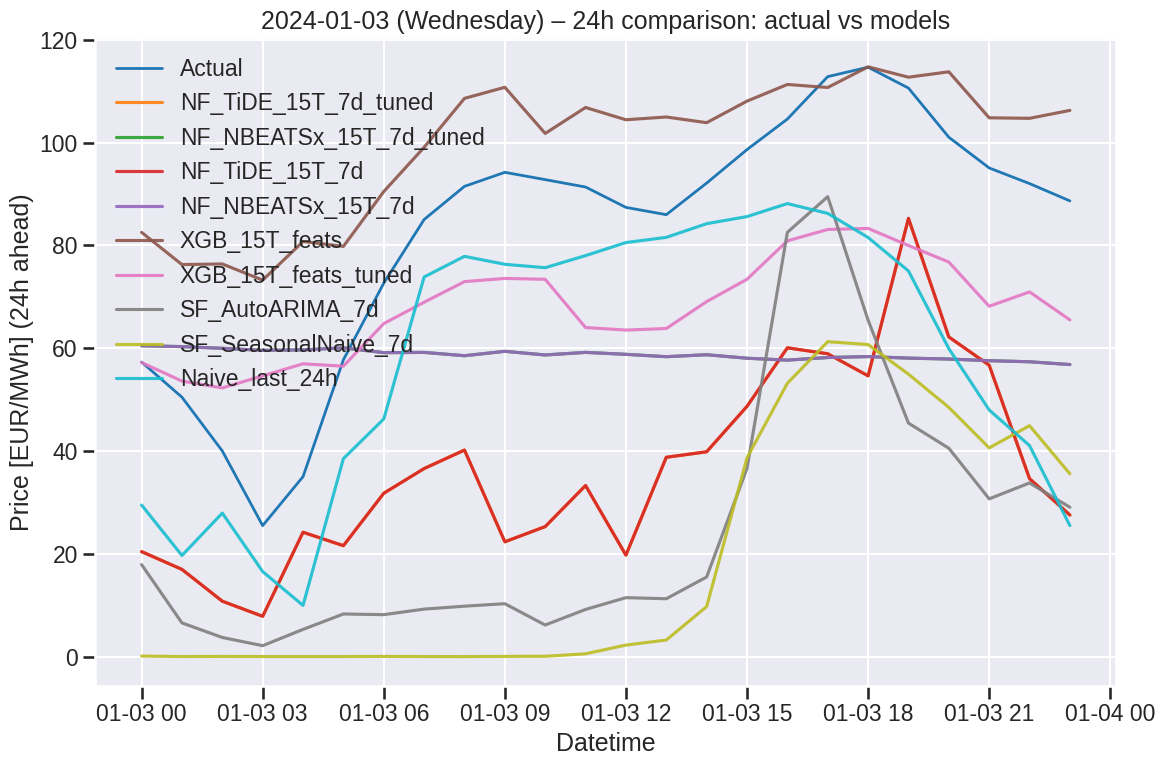

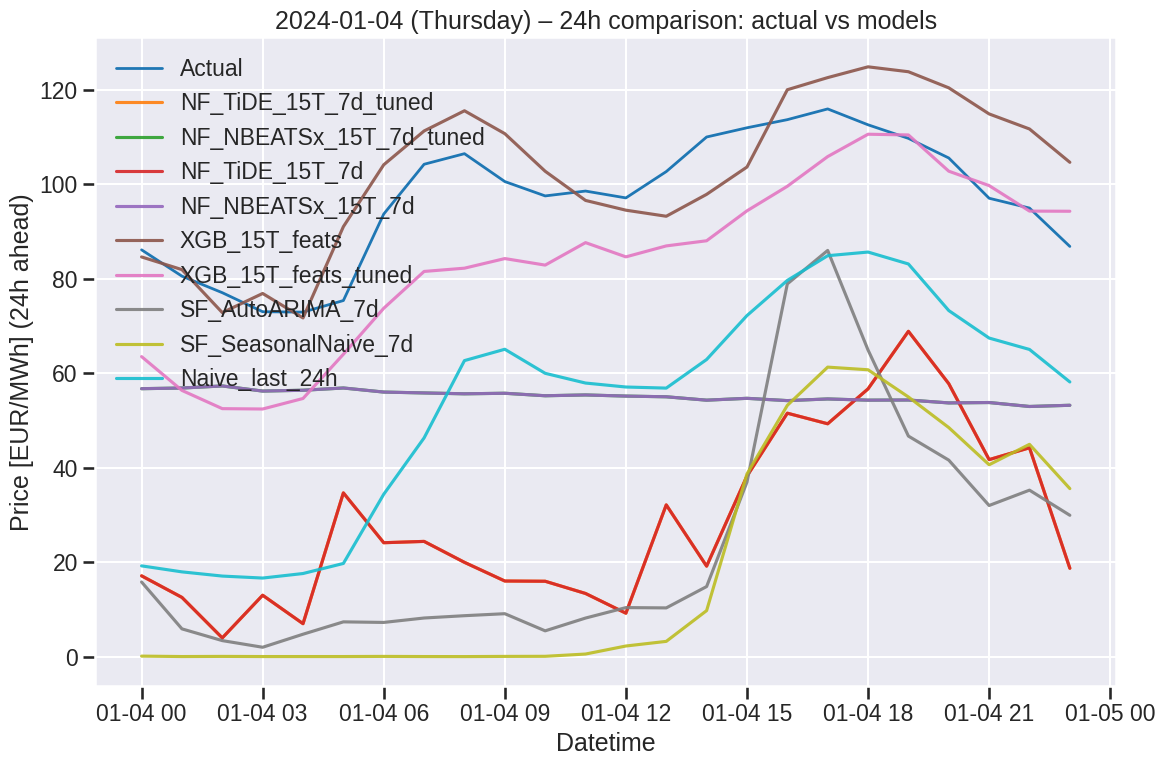

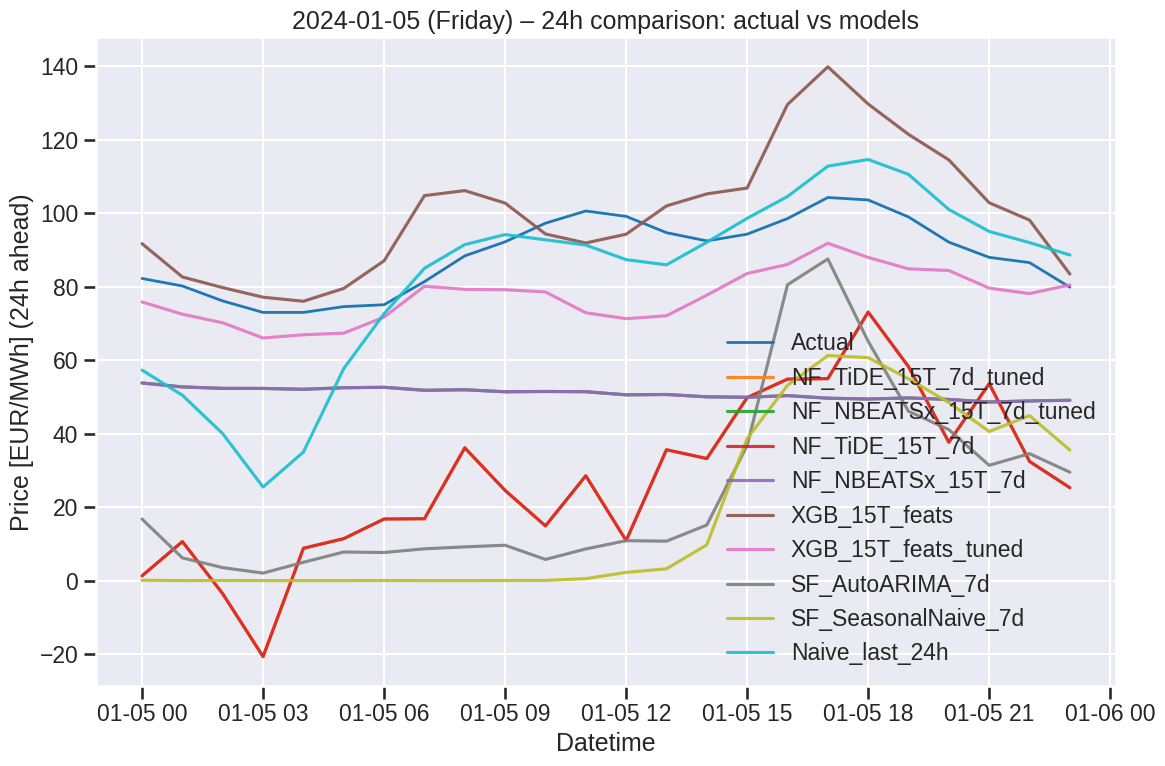

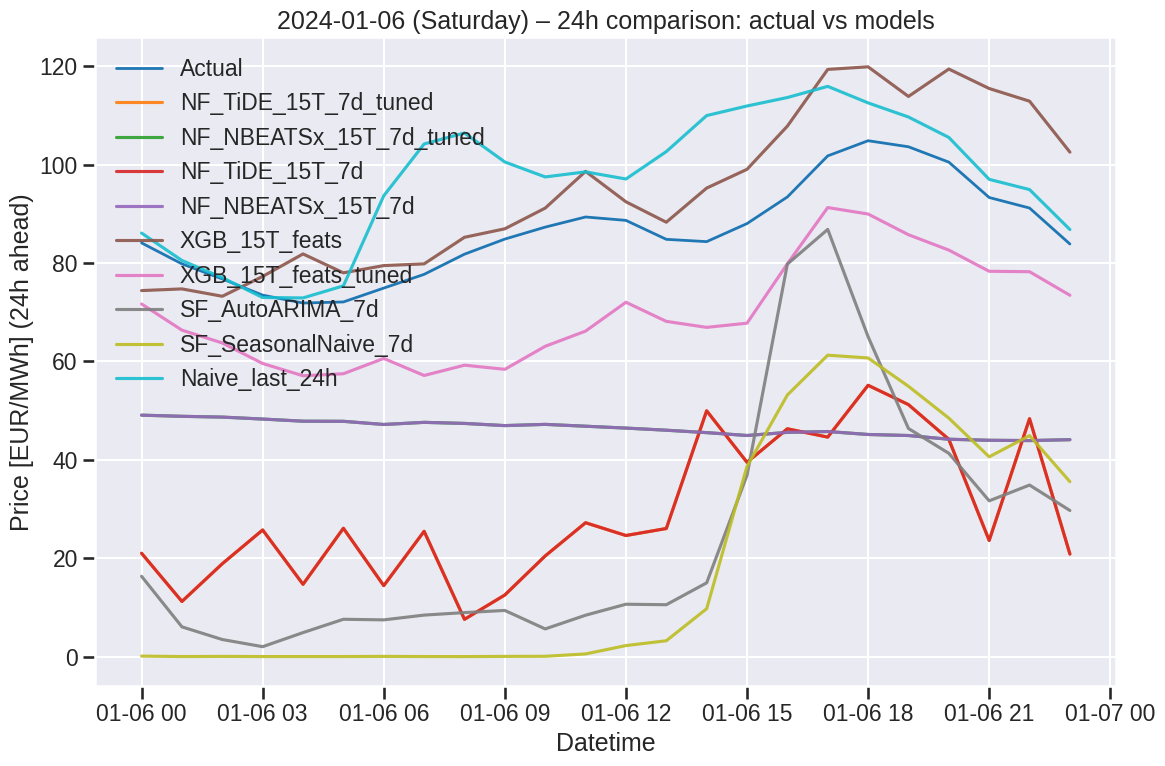

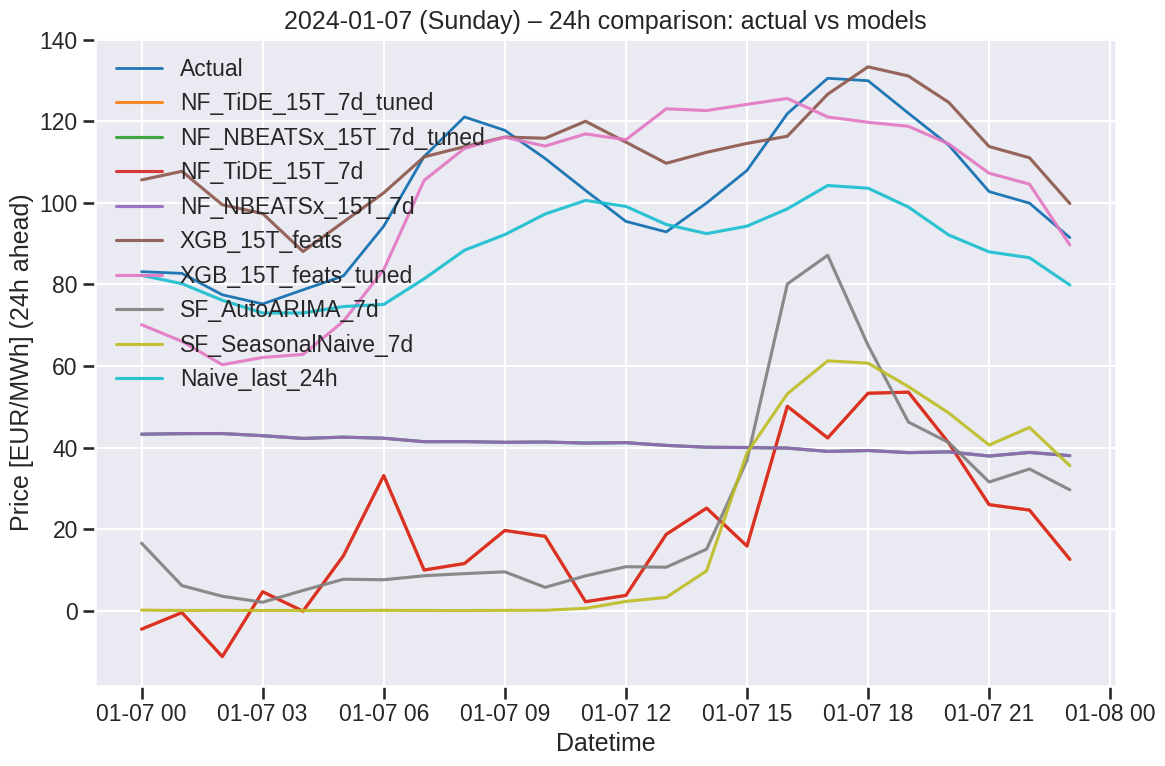

In [ ]:
# 9.3 Daily model comparison for first 7 days of 2024 (24h panels)

if RUN_NEURALFORECAST and RUN_BASE_MODELS:
    test_7d_start = pd.to_datetime(TEST_START_DATE)
    test_7d_end   = test_7d_start + pd.Timedelta(hours=NF_HORIZON_7D - 1)
    y_7d_series = y_test_1H.loc[test_7d_start:test_7d_end]

    models_7d = {}

    # NF tuned / untuned
    if "y_pred_tide_15T_7d_tuned" in globals():
        models_7d["NF_TiDE_15T_7d_tuned"] = y_pred_tide_15T_7d_tuned.astype(float)
    if "y_pred_nbeatsx_15T_7d_tuned" in globals():
        models_7d["NF_NBEATSx_15T_7d_tuned"] = y_pred_nbeatsx_15T_7d_tuned.astype(float)
    if "y_pred_tide_15T_7d" in globals():
        models_7d["NF_TiDE_15T_7d"] = y_pred_tide_15T_7d.astype(float)
    if "y_pred_nbeatsx_15T_7d" in globals():
        models_7d["NF_NBEATSx_15T_7d"] = y_pred_nbeatsx_15T_7d.astype(float)

    # XGB
    models_7d["XGB_15T_feats"] = pd.Series(y_pred_xgb_15T_test, index=y_test_1H.index).loc[y_7d_series.index]
    if "y_pred_xgb_15T_test_tuned" in globals():
        models_7d["XGB_15T_feats_tuned"] = pd.Series(y_pred_xgb_15T_test_tuned, index=y_test_1H.index).loc[y_7d_series.index]

    # StatsForecast
    if "y_pred_autoarima_7d" in globals():
        models_7d["SF_AutoARIMA_7d"] = y_pred_autoarima_7d.astype(float)
    if "y_pred_snaive_7d" in globals():
        models_7d["SF_SeasonalNaive_7d"] = y_pred_snaive_7d.astype(float)

    # Naive
    if isinstance(naive_pred_test, pd.Series):
        models_7d["Naive_last_24h"] = naive_pred_test.loc[y_7d_series.index].astype(float)

    aligned_models_7d = {}
    for name, s in models_7d.items():
        if not isinstance(s, pd.Series):
            s = pd.Series(s, index=y_7d_series.index)
        s_aligned = s.loc[y_7d_series.index]
        aligned_models_7d[name] = s_aligned.astype(float)

    unique_days = sorted(y_7d_series.index.normalize().unique())

    for d in unique_days:
        mask = (y_7d_series.index.normalize() == d)
        y_day = y_7d_series[mask]
        if y_day.empty:
            continue

        preds_day = {name: s.loc[y_day.index] for name, s in aligned_models_7d.items()}

        day_str = d.strftime("%Y-%m-%d (%A)")
        plot_actual_vs_forecast(
            y_true=y_day,
            y_pred_dict=preds_day,
            title=f"{day_str} – 24h comparison: actual vs models",
            figsize=(12, 8),
        )
else:
    print("RUN_NEURALFORECAST is False – skipping daily model comparison plots.")

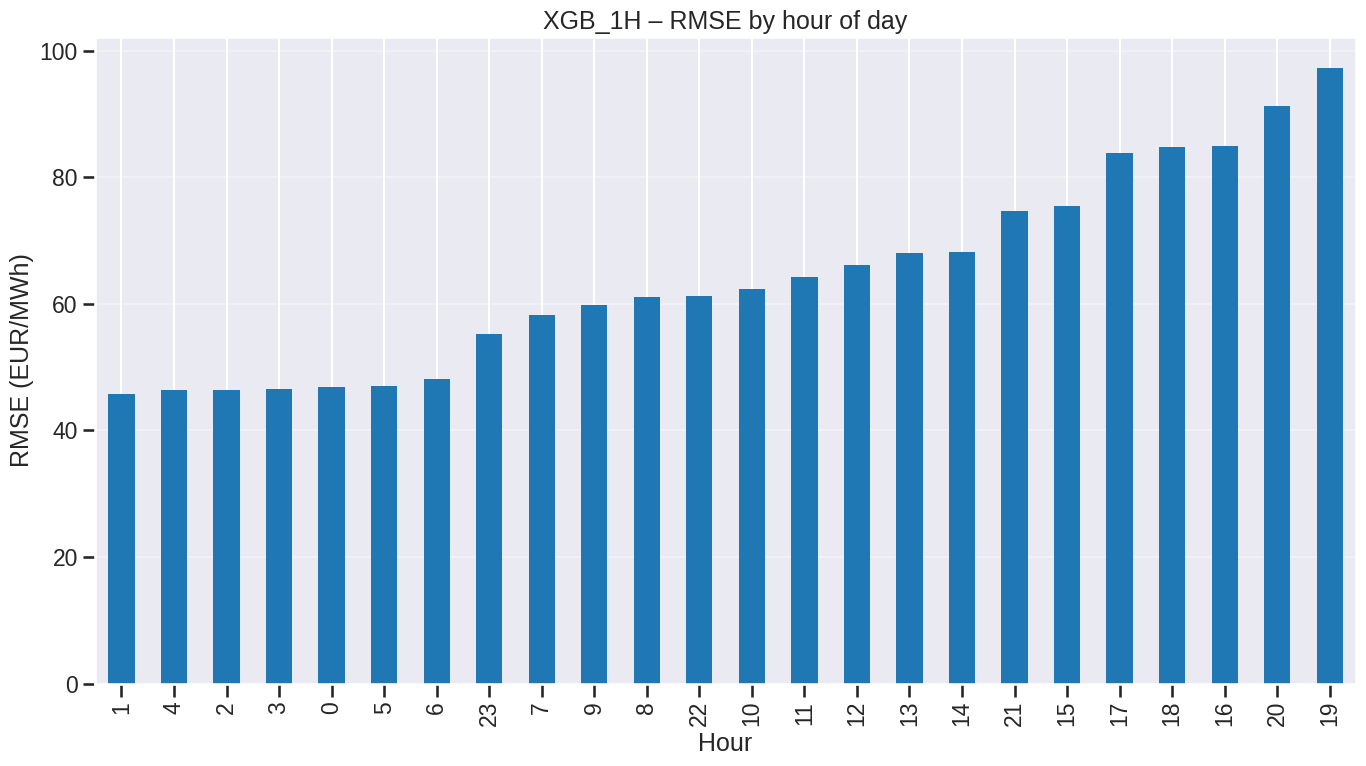

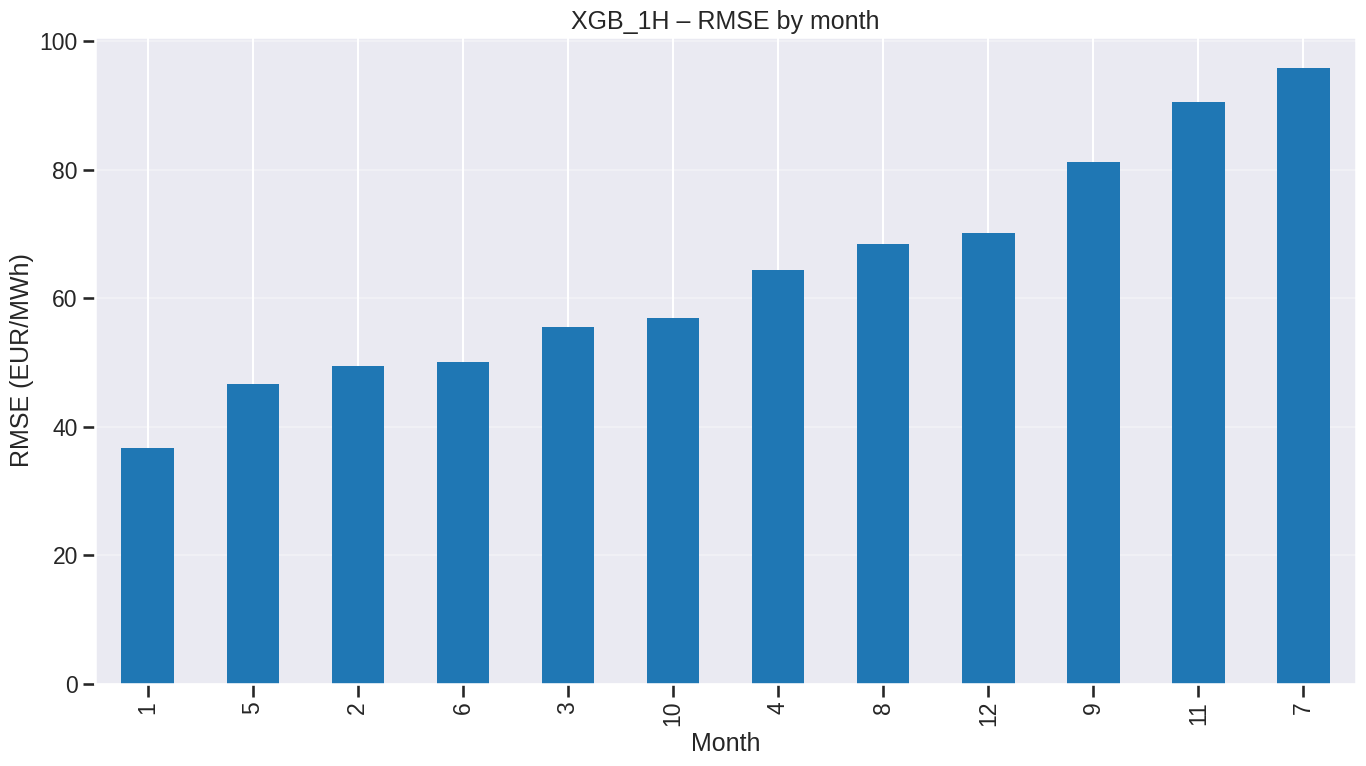

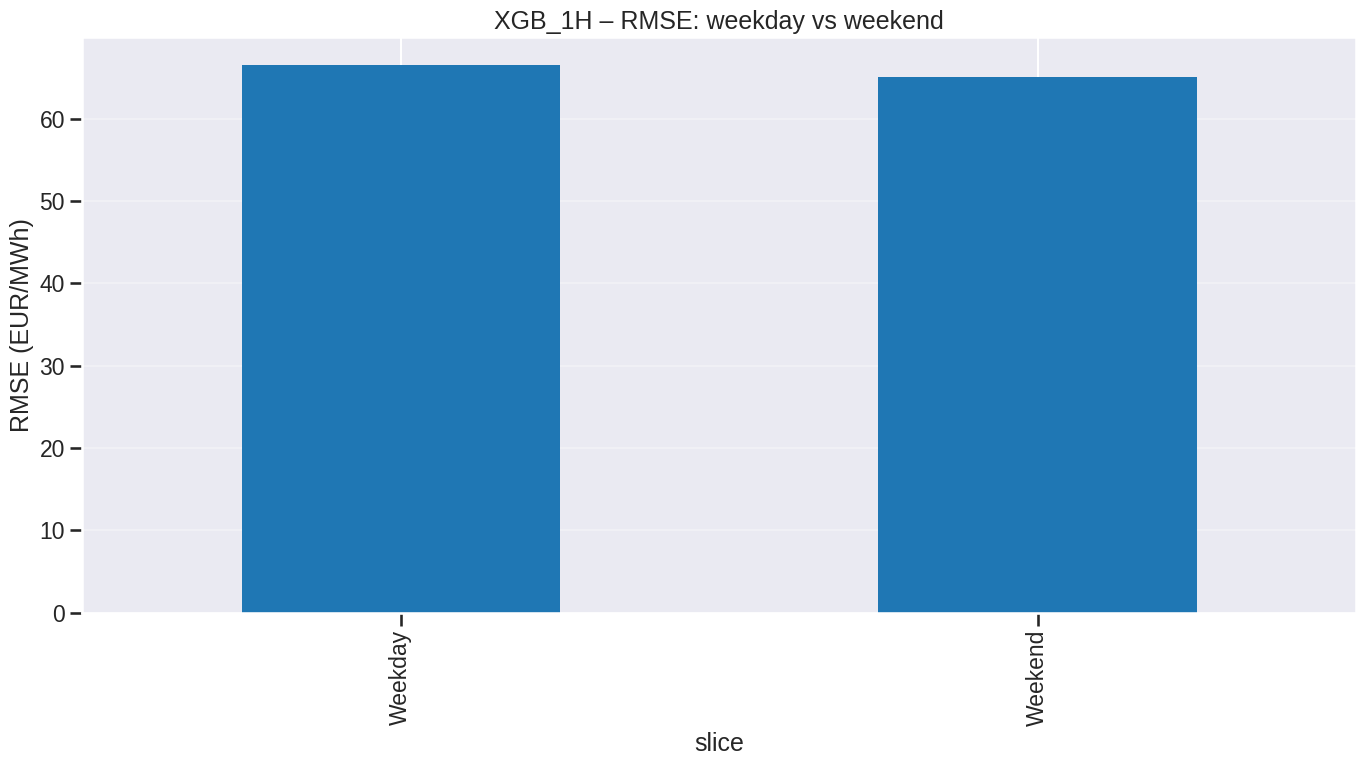

In [ ]:
# 9.4 Slice-wise metrics (RMSE by hour/month/is_weekend) for XGB_1H

if RUN_BASE_MODELS:
    y_true = y_test_1H.sort_index()
    y_pred = pd.Series(y_pred_xgb_1H_test, index=y_test_1H.index).sort_index()

    df_err = pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred,
    }).dropna()

    idx = df_err.index

    df_err["hour"]       = idx.hour
    df_err["month"]      = idx.month
    df_err["dayofweek"]  = idx.dayofweek
    df_err["is_weekend"] = df_err["dayofweek"].isin([5, 6]).astype(int)

    # Hour-of-day metrics
    metrics_by_hour = slice_metrics_df(df_err["y_true"], df_err["y_pred"], df_err["hour"])
    metrics_by_hour = metrics_by_hour.sort_values("rmse")

    plt.figure(figsize=(14, 8))
    metrics_by_hour["rmse"].plot(kind="bar")
    plt.title("XGB_1H – RMSE by hour of day")
    plt.ylabel("RMSE (EUR/MWh)")
    plt.xlabel("Hour")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Month metrics
    metrics_by_month = slice_metrics_df(df_err["y_true"], df_err["y_pred"], df_err["month"])
    metrics_by_month = metrics_by_month.sort_values("rmse")

    plt.figure(figsize=(14, 8))
    metrics_by_month["rmse"].plot(kind="bar")
    plt.title("XGB_1H – RMSE by month")
    plt.ylabel("RMSE (EUR/MWh)")
    plt.xlabel("Month")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Weekday vs weekend
    metrics_by_weekend = slice_metrics_df(df_err["y_true"], df_err["y_pred"], df_err["is_weekend"])
    metrics_by_weekend.index = metrics_by_weekend.index.map({0: "Weekday", 1: "Weekend"})

    plt.figure(figsize=(14, 8))
    metrics_by_weekend["rmse"].plot(kind="bar")
    plt.title("XGB_1H – RMSE: weekday vs weekend")
    plt.ylabel("RMSE (EUR/MWh)")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("RUN_BASE_MODELS is False – skipping slice-wise metrics.")

In [ ]:
# 9.5 Interactive Plotly comparison: actual vs XGB_1H (last 30 days of test)

if RUN_BASE_MODELS:
    y_test_sorted = y_test_1H.sort_index()
    test_end   = y_test_sorted.index.max()
    test_start = test_end - pd.Timedelta(days=30)

    y_window = y_test_sorted.loc[test_start:test_end]

    df_plot = pd.DataFrame({
        "datetime": y_window.index,
        "Actual_price": y_window.values,
    })

    y_pred_xgb_1H_series = pd.Series(y_pred_xgb_1H_test, index=y_test_1H.index)
    df_plot["XGB_1H"] = y_pred_xgb_1H_series.loc[y_window.index].values

    df_long = df_plot.melt(
        id_vars="datetime",
        var_name="Series",
        value_name="Price_EUR_MWh"
    )

    fig = px.line(
        df_long,
        x="datetime",
        y="Price_EUR_MWh",
        color="Series",
        title="HU day-ahead price: actual vs XGB_1H – last 30 days of test (interactive)",
        labels={"datetime": "Datetime", "Price_EUR_MWh": "EUR/MWh"},
    )

    out_html = DATA_DIR / "interactive_price_XGB1H_last30d.html"
    fig.write_html(str(out_html))
    fig.show()
else:
    print("RUN_BASE_MODELS is False – skipping interactive comparison.")


Collected 17 models for tier evaluation:
 - Naive_last_24h
 - LinReg_no_weather
 - LinReg_1H
 - LinReg_15T_feats
 - XGB_no_weather
 - XGB_1H
 - XGB_15T_feats
 - XGB_1H_tuned
 - XGB_15T_feats_tuned
 - SF_AutoARIMA_7d
 - SF_SeasonalNaive_7d
 - NF_NBEATSx_1H_7d
 - NF_TiDE_1H_7d
 - NF_NBEATSx_15T_7d
 - NF_TiDE_15T_7d
 - NF_NBEATSx_15T_7d_tuned
 - NF_TiDE_15T_7d_tuned

Evaluation windows:
24h: 2024-01-01 00:00:00 → 2024-01-01 23:00:00 n = 24
72h: 2024-01-01 00:00:00 → 2024-01-03 23:00:00 n = 72

Final evaluation table on 72h window (sorted by RMSE):


,model,n_points,rmse,mae,smape,rank,tier
0,XGB_1H_tuned,72,23.944913,19.787991,35.417217,1,Tier 1
1,XGB_15T_feats_tuned,72,24.548099,20.858525,37.039048,2,Tier 1
2,NF_NBEATSx_15T_7d,72,28.984475,24.554302,42.760525,3,Tier 1
3,NF_NBEATSx_15T_7d_tuned,72,28.984475,24.554302,42.760525,4,Tier 2
4,NF_TiDE_1H_7d,72,30.878751,25.337195,55.918326,5,Tier 2
5,NF_NBEATSx_1H_7d,72,31.810539,26.900538,43.333823,6,Tier 2
6,XGB_1H,72,35.798711,32.118897,48.038642,7,Tier 2
7,XGB_15T_feats,72,35.800884,31.295460,47.451629,8,Tier 3
8,Naive_last_24h,71,36.727720,31.969718,89.715951,9,Tier 3
9,NF_TiDE_15T_7d,72,36.766646,30.472698,67.095630,10,Tier 3



Tier 1 models: ['XGB_1H_tuned', 'XGB_15T_feats_tuned', 'NF_NBEATSx_15T_7d']
Tier 2 models: ['NF_NBEATSx_15T_7d_tuned', 'NF_TiDE_1H_7d', 'NF_NBEATSx_1H_7d', 'XGB_1H']
Tier 3 models: ['XGB_15T_feats', 'Naive_last_24h', 'NF_TiDE_15T_7d', 'NF_TiDE_15T_7d_tuned', 'XGB_no_weather', 'SF_AutoARIMA_7d', 'SF_SeasonalNaive_7d', 'LinReg_15T_feats', 'LinReg_1H', 'LinReg_no_weather']


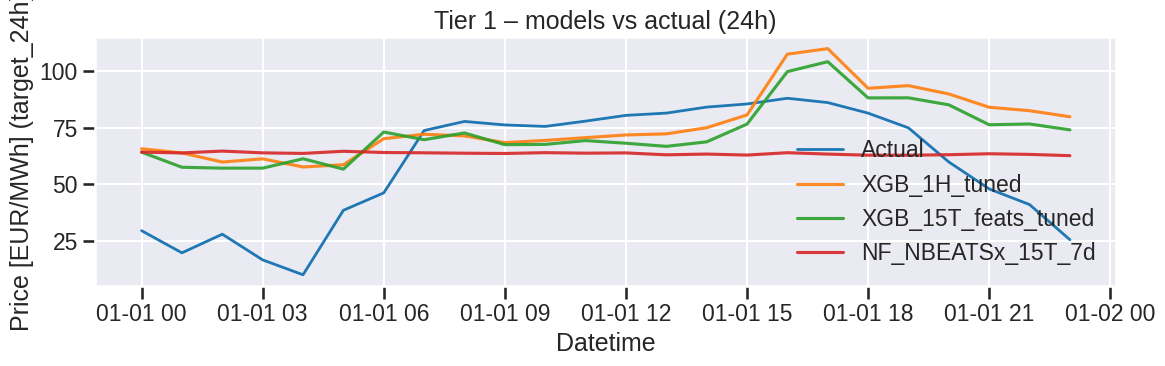

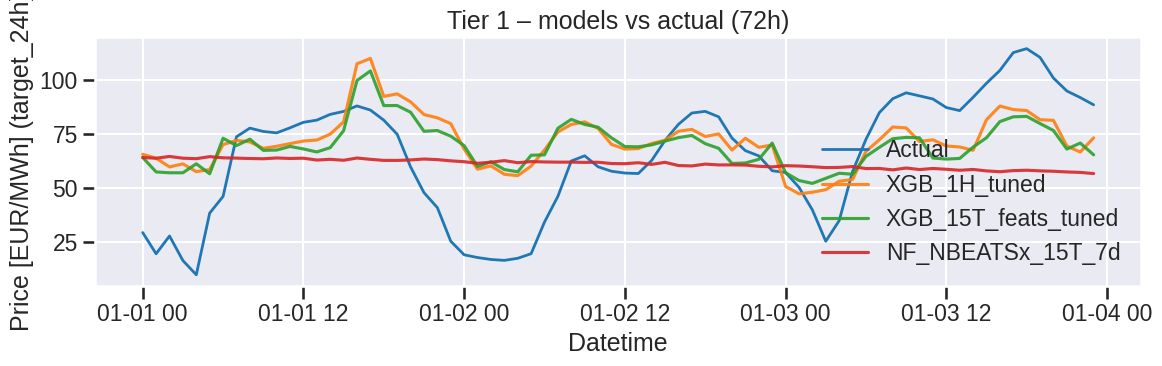

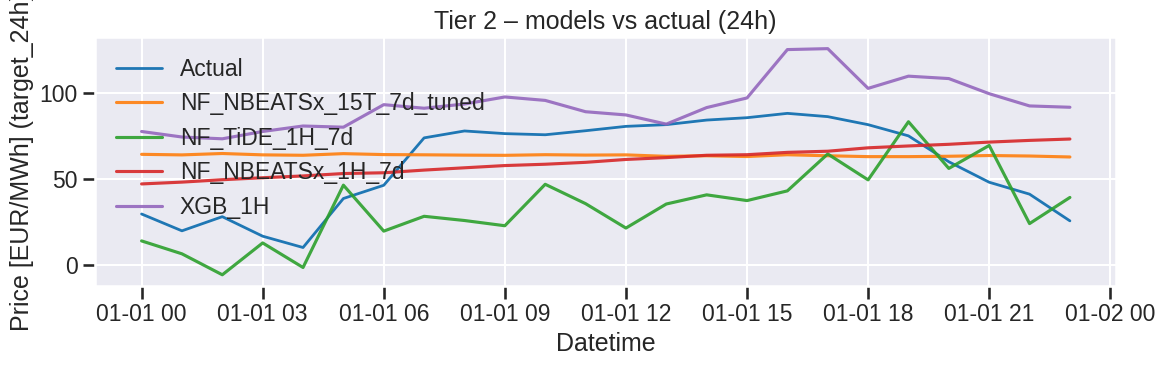

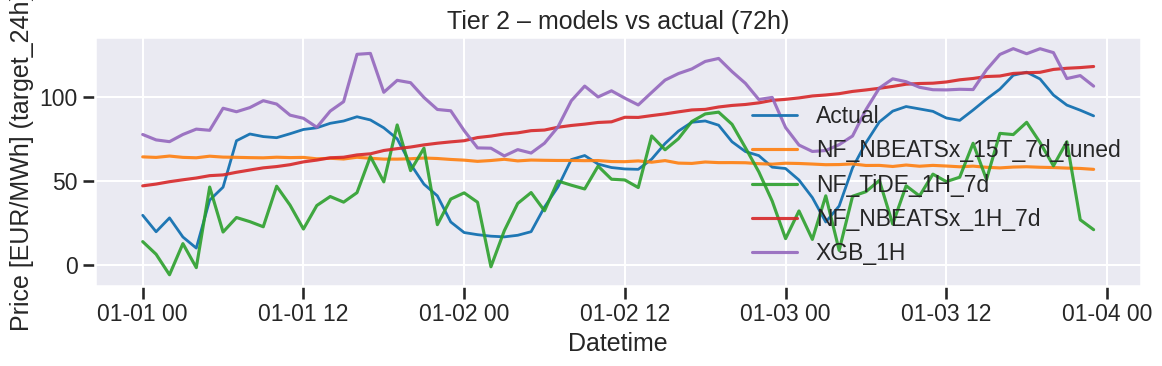

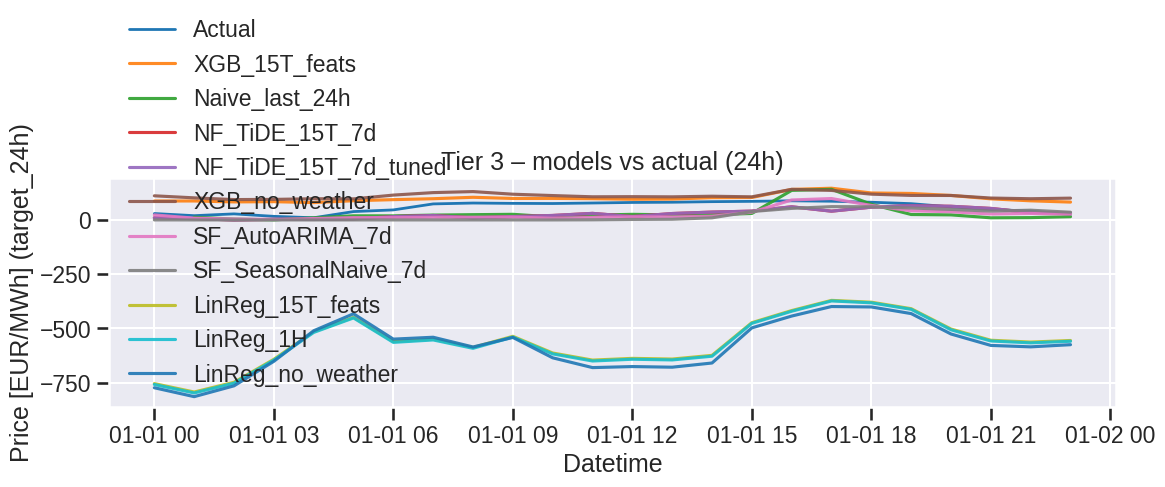

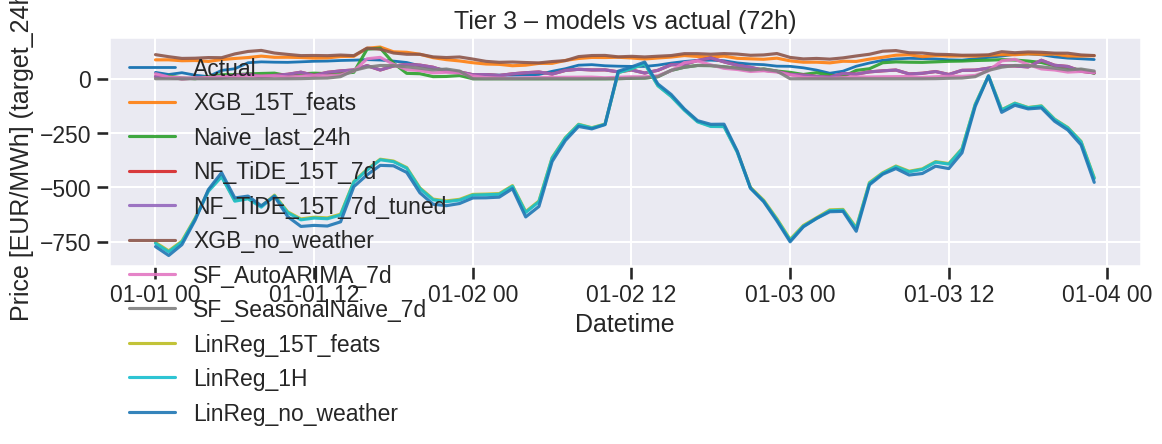

In [ ]:
#9.6 Tier-based evaluation

# 1) Collect model prediction series in a unified dictionary
#    Only models that actually exist in the current session will be added.

model_series = {}

# Naive baseline
if "naive_pred_test" in globals() and isinstance(naive_pred_test, pd.Series):
    model_series["Naive_last_24h"] = naive_pred_test.astype(float)

# Linear regression models
if "y_pred_lin_no_test" in globals():
    model_series["LinReg_no_weather"] = pd.Series(y_pred_lin_no_test, index=y_test_no.index)
if "y_pred_lin_1H_test" in globals():
    model_series["LinReg_1H"] = pd.Series(y_pred_lin_1H_test, index=y_test_1H.index)
if "y_pred_lin_15T_test" in globals():
    model_series["LinReg_15T_feats"] = pd.Series(y_pred_lin_15T_test, index=y_test_15T.index)

# XGBoost baselines
if "y_pred_no_wx_test" in globals():
    model_series["XGB_no_weather"] = pd.Series(y_pred_no_wx_test, index=y_test_no.index)
if "y_pred_xgb_1H_test" in globals():
    model_series["XGB_1H"] = pd.Series(y_pred_xgb_1H_test, index=y_test_1H.index)
if "y_pred_xgb_15T_test" in globals():
    model_series["XGB_15T_feats"] = pd.Series(y_pred_xgb_15T_test, index=y_test_15T.index)

# Tuned XGBoost models (if present)
if "y_pred_xgb_1H_test_tuned" in globals():
    model_series["XGB_1H_tuned"] = pd.Series(y_pred_xgb_1H_test_tuned, index=y_test_1H.index)
if "y_pred_xgb_15T_test_tuned" in globals():
    model_series["XGB_15T_feats_tuned"] = pd.Series(y_pred_xgb_15T_test_tuned, index=y_test_15T.index)

# StatsForecast models (7-day horizon; already Series with datetime index)
if "y_pred_autoarima_7d" in globals():
    model_series["SF_AutoARIMA_7d"] = y_pred_autoarima_7d.astype(float)
if "y_pred_snaive_7d" in globals():
    model_series["SF_SeasonalNaive_7d"] = y_pred_snaive_7d.astype(float)

# NeuralForecast – 1H
if "y_pred_nbeatsx_1H_7d" in globals():
    model_series["NF_NBEATSx_1H_7d"] = y_pred_nbeatsx_1H_7d.astype(float)
if "y_pred_tide_1H_7d" in globals():
    model_series["NF_TiDE_1H_7d"] = y_pred_tide_1H_7d.astype(float)

# NeuralForecast – 15T (base)
if "y_pred_nbeatsx_15T_7d" in globals():
    model_series["NF_NBEATSx_15T_7d"] = y_pred_nbeatsx_15T_7d.astype(float)
if "y_pred_tide_15T_7d" in globals():
    model_series["NF_TiDE_15T_7d"] = y_pred_tide_15T_7d.astype(float)

# NeuralForecast – 15T (tuned)
if "y_pred_nbeatsx_15T_7d_tuned" in globals():
    model_series["NF_NBEATSx_15T_7d_tuned"] = y_pred_nbeatsx_15T_7d_tuned.astype(float)
if "y_pred_tide_15T_7d_tuned" in globals():
    model_series["NF_TiDE_15T_7d_tuned"] = y_pred_tide_15T_7d_tuned.astype(float)

print(f"Collected {len(model_series)} models for tier evaluation:")
for name in model_series.keys():
    print(" -", name)

# 2) Define common evaluation windows: 24h and 72h from a chosen anchor date

EVAL_ANCHOR_DATE = "2024-01-01 00:00:00"  # new evaluation start date
eval_start = pd.to_datetime(EVAL_ANCHOR_DATE)

eval_24_end = eval_start + pd.Timedelta(hours=24 - 1)
eval_72_end = eval_start + pd.Timedelta(hours=72 - 1)

# Ground truth – we use y_test_1H as reference target (24h-ahead series)
y_test_full = y_test_1H.sort_index()

y_true_24 = y_test_full.loc[eval_start:eval_24_end]
y_true_72 = y_test_full.loc[eval_start:eval_72_end]

print("\nEvaluation windows:")
print("24h:", y_true_24.index.min(), "→", y_true_24.index.max(), "n =", len(y_true_24))
print("72h:", y_true_72.index.min(), "→", y_true_72.index.max(), "n =", len(y_true_72))


# 3) Build final evaluation table based on the 72h window (common horizon)

rows = []
for model_name, series in model_series.items():
    # Align model predictions with the 72h evaluation window
    # We intersect indexes in case some models only have 7-day horizon starting at TEST_START_DATE
    common_index = y_true_72.index.intersection(series.index)
    if len(common_index) < 12:  # too few points, skip
        print(f"Skipping {model_name}: only {len(common_index)} overlapping points in 72h window.")
        continue

    # Build a small evaluation DataFrame and drop any NaNs on either side
    df_eval = pd.DataFrame({
        "y_true": y_true_72.loc[common_index],
        "y_pred": series.loc[common_index].astype(float),
    }).dropna()

    if len(df_eval) < 12:
        print(f"Skipping {model_name}: only {len(df_eval)} valid (non-NaN) points after dropna().")
        continue

    metrics = evaluate_forecast(df_eval["y_true"], df_eval["y_pred"])
    rows.append({
        "model": model_name,
        "n_points": metrics["n"],
        "rmse": metrics["rmse"],
        "mae": metrics["mae"],
        "smape": metrics["smape"],
    })

eval_df = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
eval_df["rank"] = np.arange(1, len(eval_df) + 1)

# 4) Assign tiers by rank: Tier 1 = best 3, Tier 2 = next 4, Tier 3 = rest
def assign_tier(rank, n_models):
    if rank <= 3:
        return "Tier 1"
    elif rank <= 7 or n_models <= 7:
        return "Tier 2"
    else:
        return "Tier 3"

n_models = len(eval_df)
eval_df["tier"] = eval_df["rank"].apply(lambda r: assign_tier(r, n_models))

print("\nFinal evaluation table on 72h window (sorted by RMSE):")
display(eval_df)

# 5) Extract model lists per tier

tier1_models = eval_df[eval_df["tier"] == "Tier 1"]["model"].tolist()
tier2_models = eval_df[eval_df["tier"] == "Tier 2"]["model"].tolist()
tier3_models = eval_df[eval_df["tier"] == "Tier 3"]["model"].tolist()

print("\nTier 1 models:", tier1_models)
print("Tier 2 models:", tier2_models)
print("Tier 3 models:", tier3_models)

# 6) Helper function to plot models vs actual over a given window

def plot_models_over_window(
    tier_name,
    model_names,
    y_true_window,
    window_hours_label="24h",
    figsize=(12, 4)
):
    plt.figure(figsize=figsize)
    plt.plot(y_true_window.index, y_true_window.values, label="Actual", linewidth=2)

    for model_name in model_names:
        if model_name not in model_series:
            continue
        s = model_series[model_name]
        common_index = y_true_window.index.intersection(s.index)
        if len(common_index) == 0:
            continue
        s_aligned = s.loc[common_index].astype(float)
        plt.plot(s_aligned.index, s_aligned.values, label=model_name, alpha=0.9)

    plt.title(f"{tier_name} – models vs actual ({window_hours_label})")
    plt.xlabel("Datetime")
    plt.ylabel("Price [EUR/MWh] (target_24h)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 7) Create the 6 requested plots

# Tier 1 – 24h and 72h
if tier1_models:
    plot_models_over_window("Tier 1", tier1_models, y_true_24, window_hours_label="24h")
    plot_models_over_window("Tier 1", tier1_models, y_true_72, window_hours_label="72h")
else:
    print("No Tier 1 models available for plotting.")

# Tier 2 – 24h and 72h
if tier2_models:
    plot_models_over_window("Tier 2", tier2_models, y_true_24, window_hours_label="24h")
    plot_models_over_window("Tier 2", tier2_models, y_true_72, window_hours_label="72h")
else:
    print("No Tier 2 models available for plotting.")

# Tier 3 – 24h and 72h
if tier3_models:
    plot_models_over_window("Tier 3", tier3_models, y_true_24, window_hours_label="24h")
    plot_models_over_window("Tier 3", tier3_models, y_true_72, window_hours_label="72h")
else:
    print("No Tier 3 models available for plotting.")

### 10. Reproducibility and environment snapshot

 We:
 - Print versions of the main Python libraries.
 - Export the consolidated `results_df` as `model_metrics_summary.csv`
   for use in the thesis and appendix.


In [ ]:


# Environment info & optional metrics export (reproducibility)

def get_version(pkg_name):
    try:
        return importlib.import_module(pkg_name).__version__
    except Exception:
        return "N/A"

env_info = {
    "python": sys.version,
    "platform": platform.platform(),
    "numpy": get_version("numpy"),
    "pandas": get_version("pandas"),
    "matplotlib": get_version("matplotlib"),
    "seaborn": get_version("seaborn"),
    "xgboost": get_version("xgboost"),
    "lightgbm": get_version("lightgbm"),
    "tensorflow": get_version("tensorflow"),
    "statsforecast": get_version("statsforecast"),
    "neuralforecast": get_version("neuralforecast"),
}

env_df = pd.DataFrame.from_dict(env_info, orient="index", columns=["version"])
print("Environment versions:")
print(env_df)

# Export consolidated metrics if available
try:
    metrics_path = DATA_DIR / "model_metrics_summary.csv"
    results_df.to_csv(metrics_path, index=False)
    print(f"Saved model metrics to: {metrics_path}")
except NameError:
    print("results_df not found – run the model comparison cell first if you want to export metrics.")


Environment versions:
                                                          version
python          3.12.11 | packaged by Anaconda, Inc. | (main, ...
platform           Linux-5.15.0-161-generic-x86_64-with-glibc2.39
numpy                                                      1.26.4
pandas                                                      2.2.2
matplotlib                                                  3.8.2
seaborn                                                    0.13.2
xgboost                                                     3.1.2
lightgbm                                                    4.6.0
tensorflow                                                 2.20.0
statsforecast                                               2.0.3
neuralforecast                                              3.1.2
Saved model metrics to: /teamspace/studios/this_studio/Notebook_v2/data/model_metrics_summary.csv


## **References**

OpenAI. (2025). ChatGPT was used throughout the project guide the structure this notebook.